# Co-designed, Automated Lesion Mapping and Reporting | CALMaR

A flexible, reusable workflow for:

1. Pulling or pointing at a structural MRI dataset (BIDS or flat folder).
2. Running LINDA lesion segmentation on one subject or many.
3. Visualizing lesions and atlas overlaps interactively.
4. Computing per-subject and group-level lesion statistics.

**Author of this template**: Michèle Masson-Trottier

#### Tool citation
Pustina, D., Coslett, H. B., Turkeltaub, P. E., Tustison, N., Schwartz, M. F., & Avants, B. (2016).
Automated segmentation of chronic stroke lesions using LINDA: Lesion identification with neighborhood data analysis.
*Hum Brain Mapp*, 37(4), 1405–1421. https://doi.org/10.1002/hbm.23110


## How to use this notebook

The whole workflow is driven by a single configuration cell (`CONFIG` below).
Change values there once, and every other cell will pick them up automatically.

You can run it on:

- **An OpenNeuro dataset** (default: ds004884) — fetched with `datalad`.
- **A local BIDS dataset** — point `DATASET_SOURCE` at a folder.
- **A flat folder of T1w images** — works without `sub-*/ses-*` structure.
- **A single T1w file** — for a quick one-off segmentation.

If you only want to *look* at lesions you already have, set `RUN_SEGMENTATION = False`.


## Setup

### Load software

In [1]:
# Load LINDA, HD-BET (preferred) or SynthStrip via FSL via the Neurodesk module system
import module
await module.load('linda/0.5.1','hdbet/1.0.0', 'ants/2.6.5', 'fsl/6.0.7.22','bcbtoolkit/0.0.0','synthstroke/0.0.0')
# await module.load('fsl/6.0.7.4')   # provides mri_synthstrip
await module.list()

['linda/0.5.1',
 'hdbet/1.0.0',
 'ants/2.6.5',
 'fsl/6.0.7.22',
 'bcbtoolkit/0.0.0',
 'synthstroke/0.0.0']

In [2]:
!pip install -q pydicom mystmd nilearn SimpleITK
print('pip installs done')

pip installs done


In [3]:
# Standard imports used throughout the notebook
import os
import re
import shutil
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib
from nilearn import datasets, image, plotting

### Configuration

In [4]:
# ============================================================
# CONFIGURATION — single source of truth for the whole notebook
# ============================================================
# Edit values here and re-run all cells. Every downstream cell
# reads from this CONFIG dict, so you do not need to edit them.
# ------------------------------------------------------------

CONFIG = {
    # --- Where the notebook stores its working files ----------
    # PROJECT_DIR is the root for everything the notebook creates.
    # Defaults to the folder you launched the notebook from.
    "PROJECT_DIR": Path.cwd(),

    # --- Dataset source ---------------------------------------
    # One of:
    #   "openneuro"   – fetch by accession ID with datalad
    #   "local"       – use a local BIDS dataset
    #   "flat"        – a folder of *_T1w.nii.gz files (no sub-/ses- needed)
    #   "single"      – a single T1w file
    "DATASET_SOURCE":  "openneuro",
    "OPENNEURO_ID":    "ds004884",          # used when DATASET_SOURCE == "openneuro"
    "DATA_SUBDIR":     "data",               # datasets live under PROJECT_DIR/data/
    "OPENNEURO_TAG":   "1.0.2",             # git tag/branch to checkout (None = HEAD)
    "LOCAL_DATASET":   None,                # Path to local BIDS or flat folder
    "SINGLE_T1W":      None,                # Path to a single .nii.gz T1w file

    # --- Subject filter ---------------------------------------
    # Limit which subjects to process. None = process everything found.
    # You can pass a list like ["sub-M2040", "sub-M2041"], or a regex string.
    "SUBJECT_FILTER": None, #["sub-M2044"],
    "SESSION_FILTER": None, #["ses-3122"],
    # If a dataset has multiple T1w runs per session, take the first by default.
    # Set to "all" to process every T1w found.
    "T1W_SELECTION":   "first",

    # --- Where outputs go -------------------------------------
    # BIDS-Derivatives layout: pipeline outputs land directly in the
    # raw dataset's derivatives/ tree, alongside any masks the
    # publishers shipped. Reports (cross-subject summaries, PDFs,
    # group maps) live OUTSIDE the dataset to avoid polluting the
    # datalad checkout with non-data products.
    "DERIVATIVES_SUBDIR":  "derivatives/linda",   # LINDA outputs (under RAW_DATASET_DIR)
    "HDBET_SUBDIR":        "derivatives/hdbet",   # HD-BET outputs (under RAW_DATASET_DIR)
    "BCB_SUBDIR":          "derivatives/bcbtoolkit", # BCBToolkit outputs (under RAW_DATASET_DIR)
    "SYNTHSTROKE_SUBDIR":  "derivatives/synthstroke", # SynthStroke outputs (under RAW_DATASET_DIR)
    "SYNTHSTROKE_TTA":     True,                    # test-time augmentation (more accurate, ~2x slower)
    "SYNTHSTROKE_TIMEOUT": 1800,                   # seconds per subject (increase for CPU-only runs)
    
    # --- BCB options ---------------------------------------- 
    # Which lesion mask(s) to run through BCBToolkit (disconnectome + Tractotron):
    # "linda"       — LINDA-predicted mask only (Lesion_in_MNI.nii.gz)
    # "synthstroke" — SynthStroke mask only      (SynthStroke_in_MNI.nii.gz)
    # "expert"      — warped manual mask only     (ExpertMask_in_MNI.nii.gz, requires
    #                 the comparison viewer to have run first to produce the warp)
    # "both"        — LINDA + expert (back-compat; skips expert if warp missing)
    # "all"         — LINDA + SynthStroke + expert
    "BCB_MASKS":           "all",
    "REPORTS_SUBDIR":      "reports",             # cross-subject products (under PROJECT_DIR)

    # --- Atlas options ----------------------------------------
    "ATLAS_SUBDIR":   "atlases",                  # under PROJECT_DIR
    "ATLASES":        ["HarvardOxford", "AAL", "Destrieux", "Schaefer400", "JHU"],
    "DEFAULT_ATLAS":  "HarvardOxford",            # used by single-subject views

    # --- Behaviour --------------------------------------------
    "RUN_SEGMENTATION":   True,                   # set False to only visualize
    "LESION_THRESHOLD":   0.5,                    # binarize lesion maps at this prob
    "OVERWRITE":          False,                  # re-run LINDA even if output exists

    # --- HD-BET preprocessing (default ON) -------------------
    # When True, HD-BET runs first to produce a clean brain mask.
    # Then LINDA is invoked with that mask — bypassing LINDA's own
    # template-based skull-stripper (which over-strips on lesioned
    # brains, dropping cortex near the lesion). Requires HD-BET to
    # be on PATH — run the brain-extractor module-load cell near
    # the top of the notebook.
    "USE_HDBET_PREPROCESSING": True,

    # When True, HD-BET's mask is passed straight to LINDA's R API
    # via brain_mask= (the documented bypass — LINDA writes the
    # mask through unchanged and skips n4_skull_strip entirely).
    # This is the recommended path. Set to False to fall back to
    # the legacy padding pipeline (wrap brain in fake-skull rim,
    # let LINDA strip it). The padding knobs below are only
    # consulted in legacy mode.
    "HDBET_USE_MASK_BYPASS":   True,               # pass HD-BET mask straight to LINDA's R API (skips its own brain extractor)
                                                  # the clean fix for over-stripping — leave True unless R/LINDA aren't available
    "HDBET_RSCRIPT_CMD":      "Rscript",          # path to Rscript (auto-detected if just "Rscript")
    "HDBET_PADDING_MM":        8.0,                # SKULL rim thickness around brain (medium intensity)
    "HDBET_CSF_RIM_MM":        2.0,                # CSF rim thickness inside the skull rim (dark, ~5% intensity)
    "HDBET_MODE":              "fast",             # "fast" or "accurate"
    "HDBET_DEVICE":            None,               # None=auto, "cpu", "0" (GPU)

    "FORCE_FETCH":        True,                  # re-ingest raw dataset even if ANAT_DIR is populated
    "MAX_SUBJECTS":       10,                   # int → only ingest this many subjects (None = all)
    "RANDOM_SAMPLE":      True,                  # True → pick MAX_SUBJECTS at random; False → first N (sorted)
    "RANDOM_SEED":        41,                     # seed for reproducible random sampling
    "VERBOSE":            True,
}

# ------------------------------------------------------------
# Derived paths — do not normally need to be edited
# ------------------------------------------------------------
PROJECT_DIR     = Path(CONFIG["PROJECT_DIR"]).resolve()
# Dataset root (where datalad install lands, or wherever LOCAL_DATASET points).
# In all source modes this is the directory we walk for discovery and write
# derivatives into.
RAW_DATASET_DIR = PROJECT_DIR / CONFIG.get("DATA_SUBDIR", "data") / (CONFIG.get("OPENNEURO_ID") or "raw_dataset")
ANAT_DIR        = RAW_DATASET_DIR     # alias — discovery walks the dataset directly
DERIV_DIR       = RAW_DATASET_DIR / CONFIG["DERIVATIVES_SUBDIR"]
HDBET_DIR       = RAW_DATASET_DIR / CONFIG["HDBET_SUBDIR"]
BCB_DIR         = RAW_DATASET_DIR / CONFIG["BCB_SUBDIR"]
SYNTHSTROKE_DIR = RAW_DATASET_DIR / CONFIG["SYNTHSTROKE_SUBDIR"]
REPORTS_DIR     = PROJECT_DIR / CONFIG["REPORTS_SUBDIR"]
ATLAS_DIR       = PROJECT_DIR / CONFIG["ATLAS_SUBDIR"]
# Only auto-create directories that live OUTSIDE the dataset.
# DERIV_DIR / HDBET_DIR live INSIDE RAW_DATASET_DIR; auto-creating
# them with parents=True would force the dataset directory into
# existence before `datalad install` runs (and the fetch cell would
# then think the dataset is already installed and skip). The
# per-subject LINDA / HD-BET cells create their own out_dir on the
# fly anyway, so we don't need to prepare these here.
for d in (ATLAS_DIR, REPORTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

# Export to the shell environment so %%bash cells can read them
os.environ["PROJECT_DIR"]     = str(PROJECT_DIR)
os.environ["ANAT_DIR"]        = str(ANAT_DIR)
os.environ["DERIV_DIR"]       = str(DERIV_DIR)
os.environ["HDBET_DIR"]       = str(HDBET_DIR)
os.environ["BCB_DIR"]         = str(BCB_DIR)
os.environ["SYNTHSTROKE_DIR"] = str(SYNTHSTROKE_DIR)
os.environ["ATLAS_DIR"]       = str(ATLAS_DIR)
os.environ["RAW_DATASET_DIR"] = str(RAW_DATASET_DIR)
os.environ["NILEARN_DATA"]    = str(ATLAS_DIR)
os.environ["DATASET_SOURCE"]  = CONFIG["DATASET_SOURCE"]
os.environ["OPENNEURO_ID"]    = CONFIG.get("OPENNEURO_ID") or ""
os.environ["OPENNEURO_TAG"]   = CONFIG.get("OPENNEURO_TAG") or ""
os.environ["LOCAL_DATASET"]   = str(CONFIG["LOCAL_DATASET"] or "")
os.environ["SINGLE_T1W"]      = str(CONFIG["SINGLE_T1W"] or "")
os.environ["FORCE_FETCH"]     = "1" if CONFIG["FORCE_FETCH"] else "0"
os.environ["MAX_SUBJECTS"]   = str(CONFIG["MAX_SUBJECTS"]) if CONFIG.get("MAX_SUBJECTS") else ""
os.environ["RANDOM_SAMPLE"]  = "1" if CONFIG.get("RANDOM_SAMPLE") else "0"
os.environ["RANDOM_SEED"]    = str(CONFIG.get("RANDOM_SEED", 42))

print("Configuration:")
for k, v in CONFIG.items():
    print(f"  {k:18s} = {v}")
print()
print("Derived paths:")
print(f"  PROJECT_DIR     = {PROJECT_DIR}")
print(f"  ANAT_DIR        = {ANAT_DIR}")
print(f"  DERIV_DIR       = {DERIV_DIR}")
print(f"  HDBET_DIR       = {HDBET_DIR}")
print(f"  BCB_DIR         = {BCB_DIR}")
print(f"  SYNTHSTROKE_DIR = {SYNTHSTROKE_DIR}")
print(f"  ATLAS_DIR       = {ATLAS_DIR}")
print(f"  RAW_DATASET_DIR = {RAW_DATASET_DIR}")
print(f"  REPORTS_DIR     = {REPORTS_DIR}")


Configuration:
  PROJECT_DIR        = /home/jovyan/neurodesktop-storage/calmar
  DATASET_SOURCE     = openneuro
  OPENNEURO_ID       = ds004884
  DATA_SUBDIR        = data
  OPENNEURO_TAG      = 1.0.2
  LOCAL_DATASET      = None
  SINGLE_T1W         = None
  SUBJECT_FILTER     = None
  SESSION_FILTER     = None
  T1W_SELECTION      = first
  DERIVATIVES_SUBDIR = derivatives/linda
  HDBET_SUBDIR       = derivatives/hdbet
  BCB_SUBDIR         = derivatives/bcbtoolkit
  SYNTHSTROKE_SUBDIR = derivatives/synthstroke
  SYNTHSTROKE_TTA    = True
  SYNTHSTROKE_TIMEOUT = 1800
  BCB_MASKS          = all
  REPORTS_SUBDIR     = reports
  ATLAS_SUBDIR       = atlases
  ATLASES            = ['HarvardOxford', 'AAL', 'Destrieux', 'Schaefer400', 'JHU']
  DEFAULT_ATLAS      = HarvardOxford
  RUN_SEGMENTATION   = True
  LESION_THRESHOLD   = 0.5
  OVERWRITE          = False
  USE_HDBET_PREPROCESSING = True
  HDBET_USE_MASK_BYPASS = True
  HDBET_RSCRIPT_CMD  = Rscript
  HDBET_PADDING_MM   = 8.0
  HDBET_CSF

### Load atlases

These atlases are used to compute regional overlap with each lesion mask.
They are cached under `ATLAS_DIR` so subsequent runs don't re-download.
Atlases are loaded into the `ALL_ATLASES` registry; downstream cells pick from it
based on `CONFIG["ATLASES"]`.


In [5]:
# ============================================================
# Atlas loader — caches everything under ATLAS_DIR
# ------------------------------------------------------------
# Two layers of caching:
#   1. On disk: nilearn fetchers re-use files in ATLAS_DIR if present
#      (no re-download).
#   2. In kernel: if ALL_ATLASES was already populated by a previous
#      run of this cell in the same kernel session, we skip the fetch
#      step entirely and just confirm what's loaded.
# Set FORCE_RELOAD_ATLASES = True to bypass both caches and re-fetch.
# ============================================================
FORCE_RELOAD_ATLASES = False

print(f"Atlas directory: {ATLAS_DIR}")
# Re-use a previous invocation's loaded atlases unless the user forced a refresh
if FORCE_RELOAD_ATLASES:
    ALL_ATLASES = {}
    print("  FORCE_RELOAD_ATLASES = True — clearing in-kernel cache.")
elif "ALL_ATLASES" in globals() and globals()["ALL_ATLASES"]:
    ALL_ATLASES = globals()["ALL_ATLASES"]
    print(f"  ℹ Re-using {len(ALL_ATLASES)} atlas(es) already loaded "
          f"in this kernel session.")
else:
    ALL_ATLASES = {}

class SimpleAtlas:
    """Tiny container so AAL (and any custom atlas) looks like a nilearn atlas."""
    def __init__(self, maps, labels):
        self.maps = maps
        self.labels = labels


def _fetch_harvard_oxford():
    a = datasets.fetch_atlas_harvard_oxford(
        "cort-maxprob-thr25-2mm", data_dir=str(ATLAS_DIR)
    )
    return a


def _fetch_destrieux():
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", UserWarning)
        return datasets.fetch_atlas_destrieux_2009(data_dir=str(ATLAS_DIR))


def _fetch_schaefer400():
    return datasets.fetch_atlas_schaefer_2018(
        n_rois=400, yeo_networks=7, data_dir=str(ATLAS_DIR)
    )


def _fetch_aal():
    """nilearn fetch with a fallback to a public mirror if SSL fails."""
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", DeprecationWarning)
            obj = datasets.fetch_atlas_aal(version="SPM12", data_dir=str(ATLAS_DIR))
        return SimpleAtlas(nib.load(obj.maps), obj.labels)
    except Exception as e:
        print(f"  ⚠ nilearn AAL fetch failed ({e}); using mirror")
        import requests
        import xml.etree.ElementTree as ET

        d = ATLAS_DIR / "aal_mirror"
        d.mkdir(exist_ok=True)
        nii = d / "AAL.nii.gz"
        xml = d / "AAL.xml"
        BASE = ("https://raw.githubusercontent.com/Neurita/std_brains/"
                "master/atlases/aal_SPM12/aal/atlas")

        def _dl(url, dest):
            if dest.exists():
                return
            r = requests.get(url, stream=True, timeout=60)
            r.raise_for_status()
            with open(dest, "wb") as fh:
                for chunk in r.iter_content(1024 * 1024):
                    if chunk:
                        fh.write(chunk)

        _dl(f"{BASE}/AAL.nii.gz", nii)
        _dl(f"{BASE}/AAL.xml", xml)
        labels = ["Background"]
        try:
            for elem in ET.parse(xml).getroot().iter():
                if elem.text and elem.text.strip().isalpha():
                    labels.append(elem.text.strip())
        except Exception:
            pass
        return SimpleAtlas(nib.load(str(nii)), labels)




def _fetch_jhu():
    """
    Load the JHU ICBM-DTI-81 white matter tract atlas from the FSL data
    directory (loaded via the Neurodesk module system).

    Labels are parsed from $FSLDIR/data/atlases/JHU.xml.  Tract names
    that correspond to KB region entries are preserved verbatim so that
    `kb.interpret_overlap` can match them via the region aliases defined
    in aphasia-kb/regions/*.md.

    Returns a SimpleAtlas, or None if FSL is not available.
    """
    import os, xml.etree.ElementTree as ET

    # ── Locate FSL ────────────────────────────────────────────
    fsldir = os.environ.get("FSLDIR", "").strip()
    if not fsldir:
        for candidate in ["/usr/local/fsl", "/usr/share/fsl/6.0",
                          "/usr/share/fsl", "/opt/fsl"]:
            if Path(candidate).exists():
                fsldir = candidate
                break
    if not fsldir:
        print("  ⚠ JHU atlas: FSLDIR not set — is FSL loaded?")
        print("    Add 'fsl/6.0.7.22' to the module.load() cell and re-run.")
        return None

    nii_path = Path(fsldir) / "data/atlases/JHU/JHU-ICBM-tracts-maxprob-thr50-2mm.nii.gz"
    xml_path = Path(fsldir) / "data/atlases/JHU.xml"

    if not nii_path.exists():
        print(f"  ⚠ JHU NIfTI not found at {nii_path}")
        return None

    # ── Parse labels ─────────────────────────────────────────
    labels = ["<background>"]
    if xml_path.exists():
        try:
            tree = ET.parse(str(xml_path))
            for label in sorted(tree.findall(".//label"),
                                key=lambda el: int(el.get("index", 0))):
                labels.append((label.text or "").strip() or f"Region_{len(labels)}")
        except Exception as xe:
            print(f"  ⚠ JHU XML parse error: {xe} — using numeric labels")
            img_tmp = nib.load(str(nii_path))
            n = int(img_tmp.get_fdata().max())
            labels = ["<background>"] + [f"Tract_{i}" for i in range(1, n + 1)]
    else:
        img_tmp = nib.load(str(nii_path))
        n = int(img_tmp.get_fdata().max())
        labels = ["<background>"] + [f"Tract_{i}" for i in range(1, n + 1)]

    img = nib.load(str(nii_path))
    print(f"  ✓ JHU ICBM-DTI-81: {len(labels)-1} tracts from {nii_path}")
    return SimpleAtlas(img, labels)

_FETCHERS = {
    "HarvardOxford": _fetch_harvard_oxford,
    "Destrieux":     _fetch_destrieux,
    "Schaefer400":   _fetch_schaefer400,
    "AAL":           _fetch_aal,
    "JHU":           _fetch_jhu,
}

for name in CONFIG["ATLASES"]:
    if name in ALL_ATLASES:
        n = len(ALL_ATLASES[name].labels)
        print(f"• {name}: cached ({n} regions)")
        continue
    if name not in _FETCHERS:
        print(f"  ⚠ Unknown atlas '{name}' — skipped")
        continue
    print(f"• Fetching {name}")
    try:
        ALL_ATLASES[name] = _FETCHERS[name]()
        n = len(ALL_ATLASES[name].labels)
        print(f"  ✓ {n} regions")
    except Exception as e:
        print(f"  ❌ Failed: {e}")

print("\nAtlases ready:", list(ALL_ATLASES.keys()))


Atlas directory: /home/jovyan/neurodesktop-storage/calmar/atlases
• Fetching HarvardOxford


[fetch_atlas_harvard_oxford] Dataset found in /home/jovyan/neurodesktop-storage/calmar/atlases/fsl

  ✓ 49 regions
• Fetching AAL


[fetch_atlas_aal] Dataset found in /home/jovyan/neurodesktop-storage/calmar/atlases/aal_SPM12

[fetch_atlas_aal] Downloading data from https://www.gin.cnrs.fr/AAL_files/aal_for_SPM12.tar.gz ...

...

  ⚠ nilearn AAL fetch failed (HTTPSConnectionPool(host='www.gin.cnrs.fr', port=443): Max retries exceeded with url: /AAL_files/aal_for_SPM12.tar.gz (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1032)')))); using mirror
  ✓ 5 regions
• Fetching Destrieux


[fetch_atlas_destrieux_2009] Dataset found in /home/jovyan/neurodesktop-storage/calmar/atlases/destrieux_2009

  ✓ 151 regions
• Fetching Schaefer400


[fetch_atlas_schaefer_2018] Dataset found in /home/jovyan/neurodesktop-storage/calmar/atlases/schaefer_2018

  ✓ 401 regions
• Fetching JHU
  ✓ JHU ICBM-DTI-81: 16 tracts from /cvmfs/neurodesk.ardc.edu.au/containers/fsl_6.0.7.22_20260416/fsl_6.0.7.22_20260416.simg/opt/fsl-6.0.7.22/data/atlases/JHU/JHU-ICBM-tracts-maxprob-thr50-2mm.nii.gz
  ✓ 17 regions

Atlases ready: ['HarvardOxford', 'AAL', 'Destrieux', 'Schaefer400', 'JHU']


## Data

### Fetch dataset

In [6]:
%%bash
# ============================================================
# Fetch the source dataset (metadata + git-annex pointers only)
# ------------------------------------------------------------
# Lightweight: `datalad install` clones the dataset's structure but
# does NOT download large files. Subject T1w content is fetched on
# demand by the discovery cell — only for subjects we actually
# sample (so we don't waste disk on subjects we will not process).
# Manual lesion masks + T2w are similarly fetched on demand by the
# comparison cell.
# ============================================================
set -uo pipefail
shopt -s nullglob

case "$DATASET_SOURCE" in
  openneuro)
      if [ -z "$OPENNEURO_ID" ]; then
          echo "❌ DATASET_SOURCE=openneuro but OPENNEURO_ID is empty"; exit 1;
      fi
      # Real datalad checkout? Look for .datalad/ — the directory
      # alone may exist as an empty placeholder if other cells\'
      # mkdir() pre-created it (e.g. derivatives subtree).
      if [ ! -d "$RAW_DATASET_DIR/.datalad" ]; then
          # Empty placeholder? Wipe it so `datalad install` can
          # populate cleanly (it refuses to install into a
          # non-empty directory).
          if [ -d "$RAW_DATASET_DIR" ]; then
              if [ -z "$(ls -A "$RAW_DATASET_DIR/derivatives" 2>/dev/null \
                          | grep -v -E "^(linda|hdbet)$")" ] \
                 && [ -z "$(ls -A "$RAW_DATASET_DIR" 2>/dev/null \
                            | grep -v -E "^(derivatives)$")" ]; then
                  echo "  removing empty placeholder at $RAW_DATASET_DIR"
                  rm -rf "$RAW_DATASET_DIR"
              else
                  echo "❌ $RAW_DATASET_DIR exists, contains files, but is "
                  echo "   NOT a datalad checkout (no .datalad/ folder)."
                  echo "   Either rename it out of the way or delete it"
                  echo "   manually, then re-run this cell."
                  exit 1
              fi
          fi
          echo "📥 datalad install $OPENNEURO_ID → $RAW_DATASET_DIR"
          datalad install -s "https://github.com/OpenNeuroDatasets/${OPENNEURO_ID}.git" \
              "$RAW_DATASET_DIR"
          if [ -n "$OPENNEURO_TAG" ]; then
              ( cd "$RAW_DATASET_DIR" && git checkout "$OPENNEURO_TAG" )
          fi
      else
          echo "✓ Using existing datalad checkout at $RAW_DATASET_DIR"
      fi

      # Quick stats: how many subjects + T1w stubs are visible?
      cd "$RAW_DATASET_DIR"
      n_subj=$(ls -d sub-*/ 2>/dev/null | wc -l | tr -d ' ')
      n_t1=$(find . -name "*_T1w.nii.gz" 2>/dev/null | wc -l | tr -d ' ')
      echo "   $n_subj subject(s) registered, $n_t1 T1w pointer(s) available"
      echo "   (no content downloaded yet — discovery cell handles that)"
      ;;

  local)
      if [ -z "$LOCAL_DATASET" ] || [ ! -d "$LOCAL_DATASET" ]; then
          echo "❌ LOCAL_DATASET is not a directory: $LOCAL_DATASET"; exit 1;
      fi
      echo "✓ Using local BIDS dataset at $LOCAL_DATASET"
      n_subj=$(ls -d "$LOCAL_DATASET"/sub-*/ 2>/dev/null | wc -l | tr -d ' ')
      n_t1=$(find "$LOCAL_DATASET" -name "*_T1w.nii.gz" 2>/dev/null | wc -l | tr -d ' ')
      echo "   $n_subj subject(s), $n_t1 T1w file(s)"
      ;;

  flat)
      if [ -z "$LOCAL_DATASET" ] || [ ! -d "$LOCAL_DATASET" ]; then
          echo "❌ LOCAL_DATASET is not a directory: $LOCAL_DATASET"; exit 1;
      fi
      echo "✓ Using flat folder at $LOCAL_DATASET"
      n_t1=$(ls "$LOCAL_DATASET"/*_T1w.nii.gz 2>/dev/null | wc -l | tr -d ' ')
      echo "   $n_t1 T1w file(s)"
      ;;

  single)
      if [ -z "$SINGLE_T1W" ] || [ ! -f "$SINGLE_T1W" ]; then
          echo "❌ SINGLE_T1W is not a file: $SINGLE_T1W"; exit 1;
      fi
      echo "✓ Single T1w: $SINGLE_T1W"
      ;;

  *)
      echo "❌ Unknown DATASET_SOURCE: $DATASET_SOURCE"; exit 1;
      ;;
esac


✓ Using existing datalad checkout at /home/jovyan/neurodesktop-storage/calmar/data/ds004884
   230 subject(s) registered, 447 T1w pointer(s) available
   (no content downloaded yet — discovery cell handles that)


### Discover subjects

In [7]:
# ============================================================
# Discover T1w images to process — BIDS-aware but BIDS-agnostic
# ============================================================
SUB_RE = re.compile(r"(sub-[A-Za-z0-9]+)")
SES_RE = re.compile(r"(ses-[A-Za-z0-9]+)")


def _matches_filter(value, flt):
    """Apply CONFIG filter — list of strings, single string, regex, or None."""
    if flt is None:
        return True
    if isinstance(flt, (list, tuple, set)):
        return value in flt
    if isinstance(flt, str):
        # treat as regex if it contains regex meta-chars, else equality
        if any(c in flt for c in ".*+?[](){}|^$\\"):
            return re.search(flt, value) is not None
        return value == flt
    return True


def discover_t1w(root: Path, sub_filter=None, ses_filter=None, selection="first"):
    """
    Return a list of dicts:
      {"subject": "sub-XXX", "session": "ses-YYY" or None, "t1w": Path}

    Works with:
      - sub-*/ses-*/anat/*_T1w.nii.gz   (standard BIDS w/ sessions)
      - sub-*/anat/*_T1w.nii.gz         (BIDS without sessions)
      - flat folder of *_T1w.nii.gz
    Subject/session IDs are taken from path components first,
    falling back to filename parsing.
    """
    root = Path(root)
    found = []
    for t1 in sorted(root.rglob("*_T1w.nii.gz")):
        rel = t1.relative_to(root)
        parts = rel.parts
        sub = next((p for p in parts if p.startswith("sub-")), None)
        ses = next((p for p in parts if p.startswith("ses-")), None)
        if sub is None:
            m = SUB_RE.search(t1.name)
            sub = m.group(1) if m else f"sub-{t1.stem.replace('.nii','')}"
        if ses is None:
            m = SES_RE.search(t1.name)
            ses = m.group(1) if m else None
        if not _matches_filter(sub, sub_filter):
            continue
        if ses is not None and not _matches_filter(ses, ses_filter):
            continue
        found.append({"subject": sub, "session": ses, "t1w": t1})

    if selection == "first":
        seen = {}
        for entry in found:
            key = (entry["subject"], entry["session"])
            seen.setdefault(key, entry)
        found = list(seen.values())

    return found


# Where to walk for T1w files. With the symlink farm gone, each
# DATASET_SOURCE points discovery at its native root.
if CONFIG["DATASET_SOURCE"] == "openneuro":
    _scan_root = RAW_DATASET_DIR
elif CONFIG["DATASET_SOURCE"] in ("local", "flat"):
    _scan_root = Path(CONFIG["LOCAL_DATASET"])
elif CONFIG["DATASET_SOURCE"] == "single":
    _scan_root = Path(CONFIG["SINGLE_T1W"]).parent
else:
    _scan_root = RAW_DATASET_DIR

SUBJECTS = discover_t1w(
    _scan_root,
    sub_filter=CONFIG["SUBJECT_FILTER"],
    ses_filter=CONFIG["SESSION_FILTER"],
    selection=CONFIG["T1W_SELECTION"],
)

# Optionally limit to MAX_SUBJECTS (random or first-N). This filter is
# applied AFTER discovery, so it works even when ANAT_DIR already has all
# subjects linked from a previous fetch — change the number and re-run
# this cell to resample without re-fetching.
_max = CONFIG.get("MAX_SUBJECTS")
if _max is not None and _max > 0 and _max < len(SUBJECTS):
    _orig = len(SUBJECTS)
    if CONFIG.get("RANDOM_SAMPLE"):
        import random as _rnd
        _r = _rnd.Random(CONFIG.get("RANDOM_SEED", 42))
        SUBJECTS = _r.sample(SUBJECTS, _max)
        SUBJECTS.sort(key=lambda s: (s["subject"], s["session"] or ""))
        print(f"Sampling {len(SUBJECTS)}/{_orig} subjects "
              f"(MAX_SUBJECTS={_max}, RANDOM_SAMPLE=True, "
              f"seed={CONFIG.get('RANDOM_SEED', 42)})")
    else:
        SUBJECTS = SUBJECTS[:_max]
        print(f"Sampling {len(SUBJECTS)}/{_orig} subjects "
              f"(MAX_SUBJECTS={_max}, first N)")

print(f"Discovered {len(SUBJECTS)} T1w image(s) for processing.")

# ---- Lazy datalad get: pull T1w content ONLY for sampled subjects ----
# An OpenNeuro `datalad install` populates the dataset with git-annex
# pointer stubs (~200 B each) instead of full NIfTIs. Now that SUBJECTS
# is finalised (sampling + filters applied), fetch the actual content
# for just those T1ws — keeps disk usage proportional to MAX_SUBJECTS.
# Manual masks + T2w are fetched on demand by the comparison cell.
if CONFIG["DATASET_SOURCE"] == "openneuro" and SUBJECTS:
    import shutil, subprocess
    if shutil.which("datalad") is None:
        print("⚠ datalad not on PATH; skipping content fetch. "
              "T1w files may still be annex stubs.")
    else:
        # Identify which sampled T1ws are still unfetched (file size < 1MB).
        # Fetch if broken symlink (unfetched annex stub) OR exists but too small
        to_fetch = [str(s["t1w"]) for s in SUBJECTS
                    if not Path(s["t1w"]).exists()
                    or Path(s["t1w"]).stat().st_size < 1_000_000]
        if to_fetch:
            print(f"📥 datalad get  ({len(to_fetch)} T1w file(s) need content)…")
            r = subprocess.run(["datalad", "get", "-d", str(RAW_DATASET_DIR), *to_fetch],
                               capture_output=True, text=True)
            if r.returncode == 0:
                got = sum(1 for p in to_fetch
                          if Path(p).exists() and Path(p).stat().st_size > 1_000_000)
                print(f"   ✓ fetched {got}/{len(to_fetch)}")
            else:
                print(f"   ⨯ datalad get rc={r.returncode}")
                if r.stderr.strip():
                    print(f"     {r.stderr.strip()[:300]}")
        else:
            print(f"✓ all sampled T1ws already present locally")

for s in SUBJECTS[:10]:
    print(f"  • {s['subject']}  {s['session'] or '(no session)':<12s}  {s['t1w'].name}")
if len(SUBJECTS) > 10:
    print(f"  … and {len(SUBJECTS) - 10} more")


def deriv_path_for(entry):
    """Where LINDA outputs for one entry should live.
    BIDS-derivatives style: <DERIV_DIR>/sub-X/ses-Y/anat/.
    DERIV_DIR is itself /derivatives/linda — no doubled /linda nesting."""
    sub = entry["subject"]
    ses = entry["session"]
    if ses:
        return DERIV_DIR / sub / ses / "anat"
    return DERIV_DIR / sub / "anat"


def bcb_path_for(entry):
    """Where BCBToolkit outputs (disconnectome, tractotron) live.
    derivatives/bcbtoolkit/<sub>[/<ses>]/anat/"""
    sub = entry["subject"]
    ses = entry["session"]
    if ses:
        return BCB_DIR / sub / ses / "anat"
    return BCB_DIR / sub / "anat"

def synthstroke_path_for(entry):
    """Return the SynthStroke output directory for one entry."""
    sub = entry["subject"]
    ses = entry.get("session")
    if ses:
        return SYNTHSTROKE_DIR / sub / ses / "anat"
    return SYNTHSTROKE_DIR / sub / "anat"
def hdbet_path_for(entry):
    """Where HD-BET outputs (brain mask + skull-stripped T1) live for
    one entry. Sibling of deriv_path_for, under derivatives/hdbet/."""
    sub = entry["subject"]
    ses = entry["session"]
    if ses:
        return HDBET_DIR / sub / ses / "anat"
    return HDBET_DIR / sub / "anat"


def lesion_mni_for(entry):
    """Convenience: where Lesion_in_MNI.nii.gz lives for an entry."""
    return deriv_path_for(entry) / "Lesion_in_MNI.nii.gz"


def lesion_native_for(entry):
    """Convenience: where Prediction3_native.nii.gz lives for an entry.
    This is the native-space lesion mask — the right place to draw and
    edit. After editing, call q.warp_native_lesion_to_mni(deriv_path_for(e))
    to keep Lesion_in_MNI.nii.gz consistent."""
    return deriv_path_for(entry) / "Prediction3_native.nii.gz"


# ── BIDS-derivatives helpers (shared with lesion-segmentation-benchmark) ──────
import json as _json, shutil as _shutil

_BIDS_DATASET_DESC_LINDA = {
    "Name": "LINDA",
    "BIDSVersion": "1.9.0",
    "GeneratedBy": [{"Name": "linda", "Version": "0.5.1"}],
}


def _bids_mask_path_linda(dataset_root, sub: str, ses: str) -> "Path":
    """Canonical BIDS path for a LINDA lesion mask.

    derivatives/linda/<sub>[/<ses>]/anat/<sub>[_<ses>]_space-T1w_desc-lesion_mask.nii.gz
    """
    ses_str = ses or ""
    parts = [sub]
    if ses_str:
        parts.append(ses_str)
    fname = "_".join(parts) + "_space-T1w_desc-lesion_mask.nii.gz"
    if ses_str:
        return Path(dataset_root) / "derivatives" / "linda" / sub / ses_str / "anat" / fname
    return Path(dataset_root) / "derivatives" / "linda" / sub / "anat" / fname


def _save_bids_mask_linda(native_pred: "Path", dataset_root, sub: str, ses: str) -> "Path":
    """Copy Prediction3_native.nii.gz to its canonical BIDS path."""
    bids = _bids_mask_path_linda(dataset_root, sub, ses)
    bids.parent.mkdir(parents=True, exist_ok=True)
    _shutil.copy2(str(native_pred), str(bids))
    ds_desc = Path(dataset_root) / "derivatives" / "linda" / "dataset_description.json"
    if not ds_desc.exists():
        ds_desc.write_text(_json.dumps(_BIDS_DATASET_DESC_LINDA, indent=2))
    return bids


Sampling 10/444 subjects (MAX_SUBJECTS=10, RANDOM_SAMPLE=True, seed=41)
Discovered 10 T1w image(s) for processing.
✓ all sampled T1ws already present locally
  • sub-M2044  ses-3122      sub-M2044_ses-3122_acq-tfl3p2_run-2_T1w.nii.gz
  • sub-M2074  ses-2183      sub-M2074_ses-2183_acq-tfl3p2_run-4_T1w.nii.gz
  • sub-M2088  ses-604       sub-M2088_ses-604_acq-tfl3p2_run-2_T1w.nii.gz
  • sub-M2094  ses-3155      sub-M2094_ses-3155_acq-tfl3p2_run-2_T1w.nii.gz
  • sub-M2109  ses-364       sub-M2109_ses-364_acq-tfl3p2_run-2_T1w.nii.gz
  • sub-M2120  ses-749       sub-M2120_ses-749_acq-tfl3p2_run-3_T1w.nii.gz
  • sub-M2121  ses-258       sub-M2121_ses-258_acq-tfl3p2_run-3_T1w.nii.gz
  • sub-M2181  ses-370       sub-M2181_ses-370_acq-tfl3p2_run-3_T1w.nii.gz
  • sub-M2185  ses-661       sub-M2185_ses-661_acq-tfl3p2_run-12_T1w.nii.gz
  • sub-M2237  ses-397       sub-M2237_ses-397_acq-tfl3p2_run-3_T1w.nii.gz


## Lesion segmentation

LINDA writes its outputs into a per-subject folder under `DERIV_DIR`. Existing
outputs are skipped unless `CONFIG["OVERWRITE"]` is `True`. Set
`CONFIG["RUN_SEGMENTATION"] = False` to skip this section entirely (e.g. when you
already have lesion masks and just want to visualize).


### Single-subject test

#### HD-BET

In [8]:
# ============================================================
# Test HD-BET on ONE subject (recommended before batch)
# ------------------------------------------------------------
# Runs HD-BET on the single subject indexed by TEST_SUBJECT_IDX
# (see the SUBJECTS list printed by the discovery cell above).
# The HD-BET brain mask lands in <HDBET_DIR>/<sub>/<ses>/anat/, where
# the NEXT cell (LINDA via R, mask-bypass) picks it up.
# ============================================================
TEST_SUBJECT_IDX = 0          # which subject to test (0 = first in SUBJECTS)
RUN_TEST         = False       # set False to skip this cell entirely
# ----------------------------------------------------------------

import sys, importlib
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
import linda_qc as q
importlib.reload(q)

from ipyniivue import NiiVue
from IPython.display import display, HTML

if not RUN_TEST:
    print("RUN_TEST = False — skipping single-subject test.")
elif not 0 <= TEST_SUBJECT_IDX < len(SUBJECTS):
    print(f"TEST_SUBJECT_IDX={TEST_SUBJECT_IDX} out of range "
          f"(0..{len(SUBJECTS)-1}).")
else:
    if q.detect_brain_extractor() is None:
        print("❌ HD-BET / SynthStrip not on PATH.")
        print(q.brain_extractor_help_text())
    else:
        e = SUBJECTS[TEST_SUBJECT_IDX]
        out_dir  = deriv_path_for(e)
        out_dir.mkdir(parents=True, exist_ok=True)
        work_dir = hdbet_path_for(e)
        work_dir.mkdir(parents=True, exist_ok=True)

        t1   = Path(e["t1w"])
        stem = t1.name.replace(".nii.gz", "").replace(".nii", "")
        expected_mask  = work_dir / f"{stem}_brain_mask.nii.gz"
        expected_brain = work_dir / f"{stem}_brain.nii.gz"

        tag = f"{e['subject']} {e['session'] or ''}".strip()
        print(f"Test subject: [{TEST_SUBJECT_IDX}] {tag}")
        print(f"  T1w:    {t1}")
        print(f"  Output: {work_dir}")
        print()

        if expected_mask.exists() and expected_mask.stat().st_size > 0 \
                and not CONFIG.get("OVERWRITE", False):
            print("ℹ HD-BET mask already exists — skipping.")
            print("  To redo, set CONFIG['OVERWRITE'] = True in the CONFIG cell.")
        else:
            print(f"  Pipeline: HD-BET ({CONFIG.get('HDBET_MODE','fast')})")
            res = q.run_hd_bet(
                t1, work_dir,
                mode=str(CONFIG.get("HDBET_MODE", "fast")),
                device=CONFIG.get("HDBET_DEVICE"),
            )
            print()
            print(f"  brain extractor rc={res.get('returncode')} "
                  f"(tool={res.get('tool')})")

        print()
        if expected_mask.exists() and expected_mask.stat().st_size > 0:
            display(HTML("<hr><b>HD-BET preview</b>"))
            display(HTML("<small style='color:#aaa'>"
                         "Original T1 with HD-BET brain mask overlay (red):"
                         "</small>"))
            nv1 = NiiVue()
            nv1.load_volumes([
                {"path": str(t1)},
                {"path": str(expected_mask),
                 "colormap": "red", "opacity": 0.35},
            ])
            display(nv1)

            print()
            print("If this looks right:")
            print("  → Run the next cell to run LINDA with this HD-BET mask.")
            print()
            print("If the brain mask is too tight / too loose:")
            print("  → Change CONFIG['HDBET_MODE'] to 'accurate' "
                  "(slower, better coverage)")
            print("  → Set CONFIG['OVERWRITE'] = True and re-run THIS cell.")
        else:
            print("⚠ HD-BET finished but no brain mask produced.")
            print(f"  Expected: {expected_mask}")
            print("  Check the HD-BET output above for errors.")


RUN_TEST = False — skipping single-subject test.


#### LINDA

In [9]:
# ============================================================
# Run LINDA with the in-container linda_predict_with_mask.sh
# ------------------------------------------------------------
# Calls the wrapper directly (now that it is baked into the LINDA
# Neurodesk container), passing the HD-BET mask the test cell above
# wrote. LINDA's internal n4_skull_strip is bypassed because we hand
# the mask in verbatim — fixes the over-stripping you see on
# lesioned brains.
#
# Skips if Lesion_in_MNI.nii.gz already exists for this subject,
# unless CONFIG["OVERWRITE"] = True.
# ============================================================
import subprocess
from pathlib import Path

if not RUN_TEST or not 0 <= TEST_SUBJECT_IDX < len(SUBJECTS):
    print("Skipping LINDA cell — RUN_TEST is False or TEST_SUBJECT_IDX out of range.")
else:
    e = SUBJECTS[TEST_SUBJECT_IDX]
    out_dir = deriv_path_for(e)
    t1      = Path(e["t1w"])
    stem    = t1.name.replace(".nii.gz", "").replace(".nii", "")
    # Use hdbet_path_for() — HD-BET writes to derivatives/hdbet/, not a _work subdir
    work    = hdbet_path_for(e)
    mask    = work / f"{stem}_brain_mask.nii.gz"

    print(f"Subject : [{TEST_SUBJECT_IDX}] {e['subject']} {e.get('session') or ''}".rstrip())
    print(f"  T1      = {t1}")
    print(f"  mask    = {mask}")
    print(f"  outdir  = {out_dir}")

    expected = out_dir / "Lesion_in_MNI.nii.gz"

    if not mask.exists():
        print()
        print(f"❌ HD-BET mask not found at {mask}")
        print("  Run the test cell above first — it produces this mask.")
    elif expected.exists() and expected.stat().st_size > 0 \
            and not CONFIG.get("OVERWRITE", False):
        print()
        print(f"ℹ LINDA output already exists at {expected.name} — skipping.")
        print(f"  To redo, set CONFIG['OVERWRITE'] = True in the CONFIG cell.")
        rc = 0
    else:
        # Clear stale LINDA outputs so the run starts fresh (the LINDA
        # script doesn't always overwrite consistently).
        cleared = 0
        for f in sorted(out_dir.glob("*.nii.gz")):
            f.unlink(); cleared += 1
        if cleared:
            print(f"  cleared {cleared} stale LINDA .nii.gz file(s) before re-run")
        print()

        cmd = [
            "linda_predict_with_mask.sh",
            "--t1",     str(t1),
            "--mask",   str(mask),
            "--outdir", str(out_dir),
        ]
        print(f"  ▶ {' '.join(cmd)}")
        rc = subprocess.run(cmd, check=False).returncode
        print(f"\nLINDA (linda_predict_with_mask.sh) rc = {rc}")

        if rc == 0:
            new_mask = out_dir / "BrainMask.nii.gz"
            if new_mask.exists():
                import nibabel as nib
                a = (nib.load(str(mask)).get_fdata() > 0).sum()
                b = (nib.load(str(new_mask)).get_fdata() > 0).sum()
                print(f"\n  HD-BET mask voxels  : {a:,}")
                print(f"  LINDA's BrainMask   : {b:,}")
                print(f"  ratio (LINDA/HD-BET): {b/a:.3f}")
                if abs(b - a) <= max(50, 0.001 * a):
                    print("  ✓ LINDA mask matches HD-BET mask — bypass is working!")
                else:
                    print("  ⚠ LINDA mask differs from HD-BET mask. "
                          "If the ratio is ~1.0 this is fine (rounding); "
                          "if it's much smaller, the bypass may not have engaged.")


Skipping LINDA cell — RUN_TEST is False or TEST_SUBJECT_IDX out of range.


#### SynthStroke

In [10]:
# Download synth-plus weights once (cached at /opt/synthstroke/weights/synth-plus/)
import subprocess, shutil, os
from pathlib import Path

if not RUN_TEST or not 0 <= TEST_SUBJECT_IDX < len(SUBJECTS):
    print("Skipping SynthStroke test — RUN_TEST is False or TEST_SUBJECT_IDX out of range.")
else:
    _ss = shutil.which("synthstroke")
    if not _ss:
        print("⚠  synthstroke not on PATH — is synthstroke/0.0.0 loaded?")
    else:
        e   = SUBJECTS[TEST_SUBJECT_IDX]
        tag = f"{e['subject']} {e.get('session') or ''}".strip()
        t1w = Path(e["t1w"])
        out = synthstroke_path_for(e)
        out.mkdir(parents=True, exist_ok=True)

        # Download synth-plus weights if not already present
        weights_dir = Path("/opt/synthstroke/weights/synth-plus")
        if not weights_dir.exists() or not any(weights_dir.glob("*.safetensors")):
            print("Downloading synth-plus weights …")
            subprocess.run(["synthstroke-download", "synth-plus"],
                           capture_output=True, text=True)
            print("  done" if weights_dir.exists() else "  ⚠ download may have failed")

        weights = weights_dir / "model.safetensors"
        _use_tta = CONFIG.get("SYNTHSTROKE_TTA", True)
        _timeout = CONFIG.get("SYNTHSTROKE_TIMEOUT", 1800)
        cmd = ["synthstroke", "--input", str(t1w), "--outdir", str(out)]
        if _use_tta:
            cmd += ["--tta"]
        if weights.exists():
            cmd += ["--weights", str(weights)]

        # Early skip — prediction_lesion_mask.nii.gz already present
        _mask_cached = out / "prediction_lesion_mask.nii.gz"
        _overwrite   = CONFIG.get("OVERWRITE", False)
        if _mask_cached.exists() and _mask_cached.stat().st_size > 0 and not _overwrite:
            print(f"SynthStroke test — {tag}")
            print(f"  ✓ already done — {_mask_cached.name} "
                  f"({_mask_cached.stat().st_size // 1024} KB)")
            print(f"  Set CONFIG['OVERWRITE'] = True to re-run.")
            print()
            print("Output files:")
            for _f in sorted(out.glob("*.nii.gz")):
                print(f"  {_f.name:<50}  {_f.stat().st_size // 1024:>5} KB")
        else:
            print(f"SynthStroke test — {tag}")
            print(f"  T1w    : {t1w.name}")
            print(f"  model  : {'synth-plus' if weights.exists() else 'baseline (synth-plus not found)'}")
            print(f"  outdir : {out}")
            print()

            print(f"  timeout: {_timeout}s  TTA: {_use_tta}")
            print()
            res = subprocess.run(cmd, capture_output=True, text=True, timeout=_timeout)
            print(res.stdout[-600:] if res.stdout else "")
            if res.stderr.strip():
                print(res.stderr[-200:])

            print()
            print("Output files:")
            files = sorted(out.glob("*"))
            for f in files:
                print(f"  {f.name:<50}  {f.stat().st_size // 1024:>5} KB")
            if not files:
                print("  (none — check stderr above)")

Skipping SynthStroke test — RUN_TEST is False or TEST_SUBJECT_IDX out of range.


#### BCBToolkit disconnectome

In [11]:
# ============================================================
# Test BCBToolkit disconnectome on ONE subject
# ------------------------------------------------------------
# Runs run_disco.sh (and tractotron_cli.sh if HCP1065 atlas is
# present) on the subject indexed by TEST_SUBJECT_IDX — the
# same subject the LINDA test cell above just processed.
#
# Outputs cached alongside LINDA:
#   Disconnectome.nii.gz        (LINDA mask → disconnectome)
#   Disconnectome_expert.nii.gz (expert mask, if available)
#   Tractotron_probs/           (per-tract probabilities)
#
# Requires BCBToolkit to be loaded (module.load cell at top).
# ============================================================
import subprocess, shutil, tempfile, os
from pathlib import Path

if not RUN_TEST or not 0 <= TEST_SUBJECT_IDX < len(SUBJECTS):
    print("Skipping BCBToolkit test — RUN_TEST is False or "
          "TEST_SUBJECT_IDX out of range.")
else:
    _e        = SUBJECTS[TEST_SUBJECT_IDX]
    _linda_dir = deriv_path_for(_e)
    _tag       = f"{_e['subject']} {_e.get('session') or ''}".strip()

    _run_disco  = shutil.which("run_disco.sh")
    _tractotron = shutil.which("tractotron_cli.sh")
    _bcb_root   = os.environ.get("BCBTOOLKIT_ROOT", "/opt/BCBToolKit")
    # HCP1065 path is inside the container — Python cannot check existence.
    # Pass it directly to tractotron_cli.sh which runs inside the container.
    _hcp_atlas = Path(_bcb_root) / "Tools" / "HCP1065" / "prob"

    if not _run_disco:
        print("⚠  run_disco.sh not on PATH — is bcbtoolkit loaded?")
    else:
        print(f"BCBToolkit test — {_tag}")
        print(f"  run_disco.sh : {_run_disco}")
        print(f"  tractotron   : {_tractotron or 'not found'}")
        print(f"  HCP1065      : {_hcp_atlas} "
              f"({'available if bcbtoolkit loaded' if _tractotron else 'tractotron not on PATH'})")
        print()

        # Build list of masks to run (same logic as batch cell)
        _bcb_dir  = bcb_path_for(_e)
        _bcb_dir.mkdir(parents=True, exist_ok=True)
        # Test cell always runs LINDA mask only.
        # For expert mask, run the comparison viewer first to produce
        # ExpertMask_in_MNI.nii.gz, then set BCB_MASKS="expert" or "both".
        _masks = [("LINDA",  _linda_dir / "Lesion_in_MNI.nii.gz",
                              _bcb_dir / "Disconnectome.nii.gz",
                              _bcb_dir / "Tractotron_probs")]

        for _mask_label, _lesion, _out_disco, _out_tract in _masks:
            if not _lesion.exists():
                print(f"  [{_mask_label}] lesion not found — run LINDA first")
                continue

            # Early skip — output already on disk
            if (_out_disco.exists() and _out_disco.stat().st_size > 0
                    and not CONFIG.get("OVERWRITE", False)):
                print(f"  [{_mask_label}] ✓ cached — {_out_disco.name} "
                      f"({_out_disco.stat().st_size // 1024} KB)")
                if _out_tract.exists():
                    _tc = len(list(_out_tract.glob("*")))
                    print(f"  [{_mask_label}] ✓ cached — {_out_tract.name}/ ({_tc} files)")
                print(f"  Set CONFIG['OVERWRITE'] = True to re-run.")
                continue

            print(f"  [{_mask_label}] {_lesion.name}")

            with tempfile.TemporaryDirectory(prefix="bcb_test_") as _tmp:
                _tmp = Path(_tmp)
                _in_dir   = _tmp / "input";  _in_dir.mkdir()
                _out_dir  = _tmp / "disco_out"
                _out_dir.mkdir()
                shutil.copy2(str(_lesion), str(_in_dir / "Lesion_in_MNI.nii.gz"))

                # ── run_disco.sh ──────────────────────────────────────
                print(f"    run_disco.sh …", end=" ", flush=True)
                _res = subprocess.run(
                    [_run_disco, "-l", str(_in_dir), "-o", str(_out_dir)],
                    capture_output=True, text=True, timeout=600,
                    env={**os.environ, "FSLOUTPUTTYPE": "NIFTI_GZ"}
                )
                _nii_files = sorted(_out_dir.rglob("*.nii*"))
                if _nii_files:
                    shutil.copy2(str(_nii_files[0]), str(_out_disco))
                    print(f"✓ ({_out_disco.stat().st_size // 1024} KB "
                          f"→ {_out_disco.name})")
                else:
                    if _res.returncode == 132:
                        print("✗ track_vis SIGILL (exit 132) — trying Python/dipy fallback …")
                        try:
                            _n = _bcb_disco_python(_lesion, _out_disco,
                                                   verbose=True)
                            print(f"  ✓ dipy fallback: {_n} tracts → {_out_disco.name}")
                        except Exception as _fe:
                            print(f"  ✗ dipy fallback failed: {_fe}")
                            continue
                    else:
                        print(f"✗ (exit {_res.returncode})")
                        # Print log before temp dir is cleaned up
                        _logs_dir = _out_dir / "logs"
                        _log = next(iter(sorted(_logs_dir.glob("*.txt"))), None) \
                               if _logs_dir.exists() else None
                        if _log:
                            print(f"    --- {_log.name} ---")
                            for _ln in _log.read_text(errors="replace").splitlines():
                                print(f"    {_ln}")
                        if _res.stdout.strip():
                            for _ln in _res.stdout.strip().splitlines():
                                print(f"    stdout: {_ln}")
                        if _res.stderr.strip():
                            for _ln in _res.stderr.strip().splitlines():
                                print(f"    stderr: {_ln}")
                        continue   # skip tractotron if disco failed

                # ── tractotron_cli.sh (optional) ──────────────────────
                if not _tractotron:
                    continue

                # Reslice to 2mm for tractotron (nibabel — no container dependency)
                _les_2mm = _tmp / "lesion_2mm.nii.gz"
                try:
                    import nibabel as _nib, numpy as _np
                    from nibabel.processing import resample_to_output
                    _img = _nib.load(str(_lesion))
                    _img2 = resample_to_output(_img, voxel_sizes=2.0, order=0)
                    _nib.save(_img2, str(_les_2mm))
                except Exception as _ze:
                    print(f"    reslice to 2mm failed: {_ze}")
                    continue

                _t_in  = _tmp / "tract_in";  _t_in.mkdir()
                _t_out = _tmp / "tract_out"; _t_out.mkdir()
                shutil.copy2(str(_les_2mm), str(_t_in / "Lesion_in_MNI.nii.gz"))
                print(f"    tractotron_cli.sh …", end=" ", flush=True)
                _r2 = subprocess.run(
                    [_tractotron, "-l", str(_t_in),
                     "-t", str(_hcp_atlas), "-o", str(_t_out)],
                    capture_output=True, text=True, timeout=600,
                    env={**os.environ, "FSLOUTPUTTYPE": "NIFTI_GZ"}
                )
                _t_niis = list(_t_out.rglob("*.nii*"))
                _t_csvs = list(_t_out.rglob("*.csv"))
                if _t_niis or _t_csvs:
                    _out_tract.mkdir(exist_ok=True)
                    for _tf in [*_t_niis, *_t_csvs]:
                        shutil.copy2(str(_tf), str(_out_tract / _tf.name))
                    print(f"✓ ({len(_t_niis)} maps, {len(_t_csvs)} CSVs "
                          f"→ {_out_tract.name}/)")
                else:
                    if _r2.returncode == 132:
                        print("✗ tractotron_cli.sh SIGILL (exit 132) — CPU instruction"
                              " set mismatch (AVX2/AVX512 not available on this CPU/VM).")
                        print("  Enable CPU passthrough in your VM settings"
                              " or run on bare-metal Linux/Docker.")
                    else:
                        print(f"✗ no output (exit {_r2.returncode})")
                    if _r2.stderr.strip():
                        for _ln in _r2.stderr.strip().splitlines()[-10:]:
                            print(f"    stderr: {_ln}")


Skipping BCBToolkit test — RUN_TEST is False or TEST_SUBJECT_IDX out of range.


#### View outputs

In [12]:
# View BCBToolkit outputs for the test subject
from pathlib import Path
from ipyniivue import NiiVue
from IPython.display import display, HTML

e       = SUBJECTS[TEST_SUBJECT_IDX]
bcb_dir = bcb_path_for(e)
tag     = f"{e['subject']} {e.get('session') or ''}".strip()

print(f"BCB outputs — {tag}  ({bcb_dir})")
for f in sorted(bcb_dir.rglob("*")):
    if f.is_file():
        print(f"  {str(f.relative_to(bcb_dir)):<55}  {f.stat().st_size // 1024:>5} KB")

# Show disconnectome alongside LINDA lesion
disco  = bcb_dir / "Disconnectome.nii.gz"
lesion = deriv_path_for(e) / "Lesion_in_MNI.nii.gz"

if disco.exists() and lesion.exists():
    display(HTML(
        f'<p style="font-family:sans-serif;font-size:14px;margin:8px 0 4px">'
        f'<b>Disconnectome map</b> — {tag} &nbsp;'
        f'<span style="color:#888;font-size:12px">'
        f'(white matter disconnection probability, MNI152 1mm)</span></p>'
    ))
    nv = NiiVue(height=400)
    nv.opts.is_colorbar = True
    nv.opts.colorbar_height = 0.07
    nv.load_volumes([
        {"path": str(lesion), "colormap": "gray",  "opacity": 1.0,
         "cal_min": 0.0, "cal_max": 1.0},
        {"path": str(disco),  "colormap": "warm",  "opacity": 0.8,
         "cal_min": 0.0, "cal_max": 1.0},
    ])
    display(nv)


BCB outputs — sub-M2044 ses-3122  (/home/jovyan/neurodesktop-storage/calmar/data/ds004884/derivatives/bcbtoolkit/sub-M2044/ses-3122/anat)
  Disconnectome.nii.gz                                       623 KB
  Disconnectome_expert.nii.gz                                569 KB
  Disconnectome_synthstroke.nii.gz                           522 KB
  Tractotron_probs/probability.csv                             1 KB
  Tractotron_probs/proportion.csv                              1 KB
  Tractotron_probs_expert/probability.csv                      1 KB
  Tractotron_probs_expert/proportion.csv                       1 KB
  Tractotron_probs_synthstroke/probability.csv                 1 KB
  Tractotron_probs_synthstroke/proportion.csv                  1 KB


#### Comparison viewer

In [13]:
# ============================================================
# Pipeline-stage diagnostic viewer
# ------------------------------------------------------------
# Visualises, for one subject:
#   1. Original T1 with HD-BET brain mask overlay
#   2. Final lesion mask (native space) on the original T1
#   3. Lesion in MNI space on the MNI-warped subject
# Plus a voxel-count table so you can see WHERE coverage is lost.
# ============================================================
DIAG_SUBJECT_IDX    = None     # None = follow TEST_SUBJECT_IDX from the
                               # HD-BET test cell above. Set to an int
                               # (matching the SUBJECTS index) to override.
LESION_DISPLAY_MODE = "outline"   # "fill" | "outline" | "both"
                               #  fill    = yellow filled, 60% transparency (opacity=0.4)
                               #  outline = red 1-voxel boundary line, opaque
                               #  both    = yellow fill + red outline on top

import sys, importlib
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
import linda_qc as q
importlib.reload(q)

import numpy as np
import nibabel as nib
from ipyniivue import NiiVue
from IPython.display import display, HTML

# Resolve effective index — fall back to TEST_SUBJECT_IDX if not set.
_diag_idx = DIAG_SUBJECT_IDX
if _diag_idx is None:
    _diag_idx = globals().get("TEST_SUBJECT_IDX", 0)
    print(f"DIAG_SUBJECT_IDX is None → following TEST_SUBJECT_IDX = {_diag_idx}")

if not RUN_TEST:
    print("RUN_TEST = False — skipping single-subject diagnostic viewer.")
elif not 0 <= _diag_idx < len(SUBJECTS):
    print(f"effective subject index {_diag_idx} out of range "
          f"(0..{len(SUBJECTS)-1}).")
else:
    e = SUBJECTS[_diag_idx]
    out_dir  = deriv_path_for(e)
    work_dir = hdbet_path_for(e)
    t1_orig  = Path(e["t1w"])
    # HD-BET output paths (best available mode — accurate > fast > undescd)
    # Use q.find_best_hdbet_* directly so this cell doesn't depend on
    # the discovery cell having been re-run.
    hdbet_brain      = q.find_best_hdbet_brain(work_dir) or (work_dir / "MISSING_brain.nii.gz")
    hdbet_mask       = q.find_best_hdbet_mask(work_dir)  or (work_dir / "MISSING_mask.nii.gz")
    linda_n4_brain   = out_dir / "N4corrected_Brain.nii.gz"
    linda_brainmask  = out_dir / "BrainMask.nii.gz"
    lesion_native    = out_dir / "Prediction3_native.nii.gz"
    lesion_mni       = out_dir / "Lesion_in_MNI.nii.gz"
    subject_mni      = out_dir / "Subject_in_MNI.nii.gz"
    ss_dir           = synthstroke_path_for(e)
    ss_native        = ss_dir / "prediction_lesion_mask.nii.gz"
    ss_mni           = ss_dir / "SynthStroke_in_MNI.nii.gz"

    display(HTML(
        f"<h4>{e['subject']} {e['session'] or ''} "
        f"&nbsp;·&nbsp; pipeline-stage diagnostic</h3>"
    ))

    # Voxel count table
    def _vox(p):
        if not p.exists(): return None
        try:    return int((nib.load(str(p)).get_fdata() > 0).sum())
        except: return None

    # --- helpers for lesion display modes -----------------------
    def _boundary_mask(mask_path):
        """Write (or refresh) a 1-voxel boundary-only NIfTI sidecar next
        to mask_path. Returns the sidecar path, or None if the source
        mask is missing/empty."""
        if not mask_path.exists():
            return None
        name = mask_path.name.replace(".nii.gz", "").replace(".nii", "")
        out_path = mask_path.parent / f"{name}_boundary.nii.gz"
        if (not out_path.exists()) or \
                out_path.stat().st_mtime < mask_path.stat().st_mtime:
            try:
                from scipy.ndimage import binary_erosion
            except ImportError:
                print("⚠ scipy is required for LESION_DISPLAY_MODE outline; "
                      "install with: pip install scipy")
                return None
            img = nib.load(str(mask_path))
            data = (img.get_fdata() > 0).astype(np.uint8)
            if data.sum() == 0:
                return None
            eroded = binary_erosion(data, iterations=1).astype(np.uint8)
            boundary = (data & ~eroded).astype(np.uint8)
            nib.save(nib.Nifti1Image(boundary, img.affine, img.header),
                     str(out_path))
        return out_path

    def _lesion_overlays(lesion_path, fill_color="yellow", outline_color="red"):
        """Return NiiVue overlay dicts for the lesion based on
        LESION_DISPLAY_MODE.  Pass fill_color/outline_color to
        distinguish multiple masks on the same viewer."""
        overlays = []
        if LESION_DISPLAY_MODE in ("fill", "both"):
            overlays.append({"path": str(lesion_path),
                             "colormap": fill_color, "opacity": 0.4})
        if LESION_DISPLAY_MODE in ("outline", "both"):
            bnd = _boundary_mask(lesion_path)
            if bnd is not None:
                overlays.append({"path": str(bnd),
                                 "colormap": outline_color, "opacity": 1.0})
        if not overlays:
            overlays.append({"path": str(lesion_path),
                             "colormap": outline_color, "opacity": 0.6})
        return overlays
    # ------------------------------------------------------------

    rows = []
    for label, path in [
        ("Original T1",                       t1_orig),
        ("HD-BET brain (T1, skull-stripped)", hdbet_brain),
        ("HD-BET brain mask",                 hdbet_mask),
        ("LINDA N4_corrected_Brain",          linda_n4_brain),
        ("LINDA BrainMask",                   linda_brainmask),
        ("LINDA lesion (native space)",       lesion_native),
        ("LINDA lesion (MNI space)",          lesion_mni),
        ("LINDA Subject in MNI",              subject_mni),
        ("SynthStroke lesion (native space)", ss_native),
        ("SynthStroke lesion (MNI space)",    ss_mni),
    ]:
        n = _vox(path)
        n_str = f"{n:,}" if n is not None else "—"
        exists = "✓" if path.exists() else "✗"
        rows.append(
            f"<tr><td>{exists}</td><td>{label}</td>"
            f"<td style='text-align:right'>{n_str}</td>"
            f"<td style='font-family:monospace; font-size:11px; color:#888'>"
            f"{path}</td></tr>"
        )
    display(HTML(
        "<table style='border-collapse:collapse; font-size:13px'>"
        "<tr style='background:#2c3e50; color:white'>"
        "<th style='padding:4px 8px'></th>"
        "<th style='padding:4px 8px; text-align:left'>Stage</th>"
        "<th style='padding:4px 8px'>Voxels &gt; 0</th>"
        "<th style='padding:4px 8px; text-align:left'>Path</th></tr>"
        + "".join(rows) + "</table>"
    ))

    # Quick coverage delta if both masks exist
    if hdbet_mask.exists() and linda_brainmask.exists():
        m_h = nib.load(str(hdbet_mask)).get_fdata() > 0
        m_l = nib.load(str(linda_brainmask)).get_fdata() > 0
        kept    = int((m_h & m_l).sum())
        dropped = int((m_h & ~m_l).sum())
        added   = int((~m_h & m_l).sum())
        display(HTML(
            f"<small><b>HD-BET vs LINDA mask:</b> "
            f"both agree on {kept:,} voxels; LINDA dropped "
            f"<b style='color:#d9534f'>{dropped:,}</b> voxels HD-BET kept "
            f"({100*dropped/max(int(m_h.sum()),1):.1f}% of HD-BET mask); "
            f"LINDA added {added:,} voxels HD-BET didn't have. "
            f"With the brain_mask= bypass, these should be ~identical."
            f"</small>"
        ))

    # Stage 1: Original + HD-BET mask
    if t1_orig.exists() and hdbet_mask.exists():
        display(HTML(
            "<hr><b>1. Original T1 with HD-BET brain mask (red)</b><br>"
            "<small style='color:#aaa'>What HD-BET says is brain. "
            "Should cover the whole brain including cerebellum + brainstem."
            "</small>"
        ))
        nv1 = NiiVue()
        nv1.load_volumes([
            {"path": str(t1_orig)},
            {"path": str(hdbet_mask), "colormap": "red", "opacity": 0.40},
        ])
        display(nv1)

    # Stage 2: LINDA + SynthStroke lesions side-by-side on native T1
    if t1_orig.exists() and lesion_native.exists():
        _ss_available = ss_native.exists() and ss_native.stat().st_size > 0
        _legend = (
            "<b style='color:#e74c3c'>&#9632; LINDA</b>"
            + ("&nbsp;&nbsp;<b style='color:#2ecc71'>&#9632; SynthStroke</b>"
               if _ss_available else
               "&nbsp;&nbsp;<span style='color:#888'>SynthStroke not yet run</span>")
        )
        display(HTML(
            f"<hr><b>2. Lesion segmentations — native T1 space "
            f"<small style='color:#888; font-weight:normal'>"
            f"(mode: <code>{LESION_DISPLAY_MODE}</code>)</small></b><br>"
            f"{_legend}<br>"
            "<small style='color:#aaa'>Both masks are in patient anatomy. "
            "If a lesion looks too small or is missing, the HD-BET mask "
            "above is the likely upstream cause.</small>"
        ))
        _vols2 = [{"path": str(t1_orig)}]
        _vols2 += _lesion_overlays(lesion_native,
                                   fill_color="red",    outline_color="red")
        if _ss_available:
            _vols2 += _lesion_overlays(ss_native,
                                       fill_color="green", outline_color="green")
        nv4 = NiiVue()
        nv4.load_volumes(_vols2)
        display(nv4)


DIAG_SUBJECT_IDX is None → following TEST_SUBJECT_IDX = 0
RUN_TEST = False — skipping single-subject diagnostic viewer.


In [14]:
# ============================================================
# Compare LINDA's predicted lesion to the hand-drawn ground truth
# ------------------------------------------------------------
# OpenNeuro datasets ship a manual lesion mask drawn on a structural
# scan (T1 or T2), in
#   <dataset>/derivatives/lesion_masks/<sub>/<ses>/anat/
#       <source-stem>_desc-lesion_mask.nii.gz
# where <source-stem> ends in either `_T1w` or `_T2w`.
#
# This cell handles BOTH cases:
#   - T1-drawn mask (e.g. ds006533) — header-based reslice onto the
#     discovered T1 grid (no registration needed, both are T1 of the
#     same subject; affines just need to be reconciled).
#   - T2-drawn mask (e.g. ds004884) — SimpleITK rigid registration of
#     T2 to T1, then nearest-neighbor resample of the mask onto T1.
#
# Workflow for either case:
#   1. Find any *_desc-lesion_mask.nii.gz; detect modality from stem.
#   2. Auto-fetch via `datalad get` if the file is a git-annex stub.
#   3. Bring the mask into T1 space (either reslice or coregister).
#   4. Report Dice / IoU / sensitivity / precision vs LINDA.
#   5. Visualise (a) source-on-T1 alignment check (only meaningful if
#      a real registration was done), (b) LINDA + manual overlay.
#
# All artifacts cache under <out_dir>/_manual_mask_compare/. Re-running
# is fast (skips registration if the resampled outputs already exist).
# Set CONFIG["OVERWRITE"] = True to force recomputation.
# ============================================================
CMP_SUBJECT_IDX = DIAG_SUBJECT_IDX   # default: same subject as the diagnostic viewer

import sys, importlib, subprocess
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
import linda_qc as q
importlib.reload(q)

import numpy as np
import nibabel as nib
from nibabel.processing import resample_from_to
from ipyniivue import NiiVue
from IPython.display import display, HTML


def _ensure_content(p):
    """If `p` is a small annex pointer stub, run `datalad get` on it."""
    import shutil
    if not p.exists():
        return False
    if p.stat().st_size > 1_000_000:
        return True
    if shutil.which("datalad") is None:
        print(f"  WARNING {p.name} is only {p.stat().st_size} B but datalad "
              f"is not on PATH - cannot auto-fetch.")
        return False
    print(f"  -> datalad get {p.name} (was {p.stat().st_size} B - annex stub)...")
    r = subprocess.run(["datalad", "get", str(p)],
                       capture_output=True, text=True)
    new_size = p.stat().st_size if p.exists() else 0
    if r.returncode == 0 and new_size > 1_000_000:
        print(f"     OK now {new_size:,} B")
        return True
    print(f"     FAILED rc={r.returncode}, size={new_size:,} B")
    if r.stderr.strip():
        print(f"     {r.stderr.strip()[:200]}")
    return False


def _detect_modality(stem):
    """Return T1w/T2w/None given a BIDS basename stem.
    Stems look like sub-XXX_ses-YYY_..._T1w. Modality is the last token."""
    last = stem.split("_")[-1]
    if last in ("T1w", "T2w"):
        return last
    return None


# Resolve effective subject index (mirror diagnostic viewer)
_cmp_idx = CMP_SUBJECT_IDX
if _cmp_idx is None:
    _cmp_idx = globals().get("TEST_SUBJECT_IDX", 0)
    print(f"CMP_SUBJECT_IDX is None -> following TEST_SUBJECT_IDX = {_cmp_idx}")

if not RUN_TEST:
    print("RUN_TEST = False - skipping comparison.")
elif not 0 <= _cmp_idx < len(SUBJECTS):
    print(f"effective subject index {_cmp_idx} out of range "
          f"(0..{len(SUBJECTS)-1}).")
else:
    e   = SUBJECTS[_cmp_idx]
    sub = e["subject"]
    ses = e["session"] or ""
    t1  = Path(e["t1w"])
    out_dir = deriv_path_for(e)

    # ---- 1. Locate dataset root + manual mask (auto-discover) -------
    # No CONFIG knobs needed — walk up from the T1\'s real path to find
    # the dataset root (highest folder containing `derivatives/`), then
    # recursively search anywhere under derivatives/ for files belonging
    # to this subject (and session if any) whose names contain both
    # "lesion" AND "mask". Handles every variation we\'ve seen:
    #   derivatives/lesion_masks/<sub>/<ses>/anat/*_desc-lesion_mask.nii.gz   (ds004884, ds006533)
    #   derivatives/lesion_mask/<sub>/<ses>/anat/*_lesion_mask.nii.gz         (legacy)
    #   derivatives/manual_lesions/<sub>/*_lesion-mask.nii.gz                 (custom)
    #
    # Optional override: set MASK_OVERRIDE_PATH to a specific .nii.gz to
    # skip auto-discovery (only needed if masks live somewhere unusual).
    MASK_OVERRIDE_PATH = None   # e.g. Path("/some/where/sub-XXX_lesion.nii.gz")

    t1_real = t1.resolve()
    dataset_root = None
    for p in t1_real.parents:
        if (p / "derivatives").is_dir():
            dataset_root = p; break

    manual_masks = []
    if MASK_OVERRIDE_PATH is not None:
        op = Path(MASK_OVERRIDE_PATH)
        if op.exists():
            manual_masks = [op]
        else:
            print(f"ERROR MASK_OVERRIDE_PATH set but file not found: {op}")
    elif dataset_root is None:
        print(f"ERROR Could not find a derivatives/ folder by walking up "
              f"from {t1_real}. Cannot auto-discover manual masks.")
    else:
        deriv = dataset_root / "derivatives"
        # Permissive recursive search.
        # Automated pipeline derivative dirs — never contain manual masks
        _SKIP_DERIV = {"synthstroke", "linda", "hdbet", "bcbtoolkit"}
        for p in deriv.rglob("*.nii.gz"):
            n = p.name.lower()
            if "lesion" not in n or "mask" not in n: continue
            if sub not in str(p): continue
            if ses and ses not in str(p): continue
            # Skip outputs from automated tools
            rel_parts = p.relative_to(deriv).parts
            if rel_parts and rel_parts[0].lower() in _SKIP_DERIV: continue
            manual_masks.append(p)
        # Prefer BIDS-named masks (*_desc-lesion_mask.nii.gz) over ad-hoc names
        _bids = [m for m in manual_masks if "_desc-lesion_mask.nii.gz" in m.name]
        _adhoc = [m for m in manual_masks if "_desc-lesion_mask.nii.gz" not in m.name]
        manual_masks = sorted(_bids) + sorted(_adhoc)

    if not manual_masks:
        # Fall back: try without the session filter — cross-session annotations
        # are common (e.g. mask drawn on T2 from a different session).
        if dataset_root is not None:
            alt = []
            for p in (dataset_root / "derivatives").rglob("*.nii.gz"):
                n = p.name.lower()
                if "lesion" not in n or "mask" not in n: continue
                if sub not in str(p): continue
                # Skip automated pipeline outputs
                _rel = p.relative_to(dataset_root / "derivatives").parts
                if _rel and _rel[0].lower() in _SKIP_DERIV: continue
                alt.append(p)
            # BIDS-named masks first, then ad-hoc
            _bids_alt  = [m for m in alt if "_desc-lesion_mask.nii.gz" in m.name]
            _adhoc_alt = [m for m in alt if "_desc-lesion_mask.nii.gz" not in m.name]
            alt = sorted(_bids_alt) + sorted(_adhoc_alt)
            if alt:
                if ses and not any(ses in str(m) for m in alt):
                    print(f"WARNING No manual mask found for session {ses}; "
                          f"using cross-session mask (annotation from a different visit):")
                    print(f"  {alt[0].relative_to(dataset_root)}")
                manual_masks = alt
            else:
                if dataset_root is not None:
                    print(f"ERROR No manual mask exists for {sub} in this dataset "
                          f"(searched {dataset_root}/derivatives/ recursively).")
        # else: dataset_root None message already printed above.
    else:
            if len(manual_masks) > 1:
                print(f"WARNING Multiple manual masks for {sub} {ses}; using first:")
                for m in manual_masks: print(f"     - {m.name}")
            manual_mask = manual_masks[0]

            # The matching source image lives next to it under the raw
            # dataset, with the same stem minus the _desc-lesion_mask
            # suffix. Detect its modality (T1w vs T2w).
            source_stem = manual_mask.name.replace("_desc-lesion_mask.nii.gz", "")
            # Guard: non-BIDS names (e.g. Mask.lesion1_asym.nii.gz) weren't
            # changed by the replace — strip the extension so we don't double it.
            if source_stem.endswith(".nii.gz"):
                source_stem = source_stem[:-7]
            elif source_stem.endswith(".nii"):
                source_stem = source_stem[:-4]
            modality    = _detect_modality(source_stem)
            source_img  = (dataset_root / sub / (ses or "") / "anat"
                           / f"{source_stem}.nii.gz")

            print(f"Subject:       [{_cmp_idx}] {sub} {ses}")
            print(f"  T1w (discovered): {t1.name}")
            print(f"  Mask source:      {source_img.name}  "
                  f"({'found' if source_img.exists() else 'MISSING'}, "
                  f"modality={modality or '?'})")
            print(f"  Manual mask:      {manual_mask.name}")
            print()

            if not source_img.exists():
                print(f"ERROR Source image referenced by the mask not found at "
                      f"{source_img}.")
            elif modality not in ("T1w", "T2w"):
                print(f"ERROR Could not detect modality from source stem "
                      f"{source_stem!r}. Expected suffix _T1w or _T2w.")
            else:
                cmp_dir = out_dir / "_manual_mask_compare"
                cmp_dir.mkdir(parents=True, exist_ok=True)

                _ensure_content(source_img)
                _ensure_content(manual_mask)

                mask_out = cmp_dir / "ManualLesion_in_T1.nii.gz"
                src_out  = cmp_dir / f"{modality}_in_T1.nii.gz"

                # ============================================
                # T1-drawn masks: header-based reslice (no reg)
                # ============================================
                if modality == "T1w":
                    if mask_out.exists() and src_out.exists() \
                            and not CONFIG.get("OVERWRITE", False):
                        print(f"INFO Resliced mask already exists - skipping. "
                              f"(set CONFIG['OVERWRITE']=True to redo)")
                    else:
                        print("-> T1-drawn mask: header-based reslice onto "
                              "discovered T1 grid (nibabel.resample_from_to)...")
                        t1_img     = nib.load(str(t1))
                        src_img    = nib.load(str(source_img))
                        manual_img = nib.load(str(manual_mask))

                        same_grid = (
                            src_img.shape == t1_img.shape
                            and np.allclose(src_img.affine, t1_img.affine, atol=1e-3)
                        )
                        if same_grid:
                            print("   source T1 == discovered T1 - no reslice needed.")
                            nib.save(manual_img, str(mask_out))
                            nib.save(src_img,    str(src_out))
                        else:
                            mask_resliced = resample_from_to(manual_img, t1_img, order=0)
                            src_resliced  = resample_from_to(src_img,    t1_img, order=1)
                            nib.save(mask_resliced, str(mask_out))
                            nib.save(src_resliced,  str(src_out))
                        print(f"   -> {mask_out.name}")
                        print(f"   -> {src_out.name}")

                # ============================================
                # T2-drawn masks: SimpleITK rigid registration
                # ============================================
                else:   # T2w
                    if mask_out.exists() and src_out.exists() \
                            and not CONFIG.get("OVERWRITE", False):
                        print(f"INFO Coregistration outputs already exist - skipping. "
                              f"(set CONFIG['OVERWRITE']=True to redo)")
                    else:
                        try:
                            import SimpleITK as sitk
                        except ImportError:
                            print("ERROR SimpleITK not installed. "
                                  "pip install --break-system-packages SimpleITK")
                            raise
                        print("-> T2-drawn mask: SimpleITK rigid registration "
                              "T2 -> T1 (multi-resolution, ~1-2 min)...")
                        t1_sitk     = sitk.ReadImage(str(t1),           sitk.sitkFloat32)
                        src_sitk    = sitk.ReadImage(str(source_img),   sitk.sitkFloat32)
                        manual_sitk = sitk.ReadImage(str(manual_mask),  sitk.sitkUInt8)

                        init_tx = sitk.CenteredTransformInitializer(
                            t1_sitk, src_sitk,
                            sitk.Euler3DTransform(),
                            sitk.CenteredTransformInitializerFilter.GEOMETRY,
                        )
                        reg = sitk.ImageRegistrationMethod()
                        reg.SetMetricAsMattesMutualInformation(numberOfHistogramBins=50)
                        reg.SetMetricSamplingStrategy(reg.RANDOM)
                        reg.SetMetricSamplingPercentage(0.10, sitk.sitkWallClock)
                        reg.SetInterpolator(sitk.sitkLinear)
                        reg.SetOptimizerAsRegularStepGradientDescent(
                            learningRate=2.0, minStep=1e-4,
                            numberOfIterations=200,
                            gradientMagnitudeTolerance=1e-8,
                        )
                        reg.SetOptimizerScalesFromPhysicalShift()
                        reg.SetShrinkFactorsPerLevel([4, 2, 1])
                        reg.SetSmoothingSigmasPerLevel([2.0, 1.0, 0.0])
                        reg.SmoothingSigmasAreSpecifiedInPhysicalUnitsOn()
                        reg.SetInitialTransform(init_tx, inPlace=False)
                        final_tx = reg.Execute(t1_sitk, src_sitk)
                        print(f"   metric={reg.GetMetricValue():.4f}  "
                              f"iters={reg.GetOptimizerIteration()}  "
                              f"stop: {reg.GetOptimizerStopConditionDescription()}")

                        src_in_t1 = sitk.Resample(
                            src_sitk, t1_sitk, final_tx,
                            sitk.sitkLinear, 0.0, src_sitk.GetPixelID())
                        mask_in_t1 = sitk.Resample(
                            manual_sitk, t1_sitk, final_tx,
                            sitk.sitkNearestNeighbor, 0,
                            manual_sitk.GetPixelID())
                        sitk.WriteImage(src_in_t1,  str(src_out))
                        sitk.WriteImage(mask_in_t1, str(mask_out))
                        print(f"   -> {src_out.name}")
                        print(f"   -> {mask_out.name}")

                # ---- Sanity check: retention + COM --------------------
                n_orig = int((nib.load(str(manual_mask)).get_fdata() > 0).sum())
                arr    = nib.load(str(mask_out)).get_fdata() > 0
                n_t1   = int(arr.sum())
                if n_t1:
                    com = np.argwhere(arr).mean(0)
                    com_w = nib.affines.apply_affine(
                                nib.load(str(t1)).affine, com)
                else:
                    com_w = np.zeros(3)
                print()
                print(f"Mask voxels: {n_orig:,} (source) -> {n_t1:,} (T1)  "
                      f"= {100*n_t1/max(n_orig,1):.1f}% retention")
                print(f"COM in T1 (mm): ({com_w[0]:+6.1f}, {com_w[1]:+6.1f}, "
                      f"{com_w[2]:+6.1f})  - x<0 = LEFT hemisphere")
                print()

                # Show source-on-T1 only when a real registration was done
                # (T2 case). For T1-drawn masks the overlay would be trivial.
                if modality == "T2w":
                    display(HTML(
                        "<hr><b>1. Coregistered T2 (red) on T1</b><br>"
                        "<small style='color:#aaa'>Should look like a single "
                        "brain. Doubled ghost = registration failed.</small>"))
                    nv1 = NiiVue()
                    nv1.load_volumes([{"path": str(t1)},
                                      {"path": str(src_out),
                                       "colormap": "red", "opacity": 0.5}])
                    display(nv1)

                # ---- LINDA comparison --------------------------------
                linda_p = out_dir / "Prediction3_native.nii.gz"
                if not linda_p.exists():
                    print(f"WARNING LINDA prediction not found at {linda_p}. "
                          f"Run the LINDA cell first.")
                else:
                    m = nib.load(str(mask_out)).get_fdata() > 0
                    l = nib.load(str(linda_p)).get_fdata()  > 0
                    inter = int((m & l).sum())
                    m_n   = int(m.sum()); l_n = int(l.sum())
                    union = m_n + l_n - inter
                    dice  = 2 * inter / max(m_n + l_n, 1)
                    iou   = inter / max(union, 1)
                    sens  = inter / max(m_n, 1)
                    prec  = inter / max(l_n, 1)

                    display(HTML(
                        "<table style='border-collapse:collapse; font-size:13px'>"
                        "<tr style='background:#2c3e50; color:white'>"
                        "<th style='padding:4px 8px; text-align:left'>Metric</th>"
                        "<th style='padding:4px 8px; text-align:right'>Value</th></tr>"
                        f"<tr><td>Mask source modality</td>"
                        f"<td style='text-align:right'>{modality}</td></tr>"
                        f"<tr><td>Manual lesion (voxels)</td>"
                        f"<td style='text-align:right'>{m_n:,}</td></tr>"
                        f"<tr><td>LINDA lesion (voxels)</td>"
                        f"<td style='text-align:right'>{l_n:,}</td></tr>"
                        f"<tr><td>Overlap (voxels)</td>"
                        f"<td style='text-align:right'>{inter:,}</td></tr>"
                        f"<tr><td><b>Dice</b></td>"
                        f"<td style='text-align:right'><b>{dice:.3f}</b></td></tr>"
                        f"<tr><td>IoU / Jaccard</td>"
                        f"<td style='text-align:right'>{iou:.3f}</td></tr>"
                        f"<tr><td>Sensitivity (recall vs manual)</td>"
                        f"<td style='text-align:right'>{sens:.1%}</td></tr>"
                        f"<tr><td>Precision (vs manual)</td>"
                        f"<td style='text-align:right'>{prec:.1%}</td></tr>"
                        "</table>"))

                    display(HTML(
                        "<hr><b>2. LINDA (red) + Manual (cyan) on T1</b><br>"
                        "<small style='color:#aaa'>Cyan-only = manual labelled, "
                        "LINDA missed. Red-only = LINDA labelled, manual didn't. "
                        "Purplish blend = both agree.</small>"))
                    nv2 = NiiVue()
                    nv2.load_volumes([
                        {"path": str(t1)},
                        {"path": str(linda_p),  "colormap": "red",  "opacity": 0.5},
                        {"path": str(mask_out), "colormap": "blue", "opacity": 0.5},
                    ])
                    display(nv2)


CMP_SUBJECT_IDX is None -> following TEST_SUBJECT_IDX = 0
RUN_TEST = False - skipping comparison.


In [15]:
# ============================================================
# Compare LINDA's predicted lesion to the hand-drawn ground truth
# ------------------------------------------------------------
# OpenNeuro datasets like ds004884 ship a manual lesion mask drawn
# on the subject's T2w image, in
#   <dataset>/derivatives/lesion_masks/<sub>/<ses>/anat/
#       <T2w-stem>_desc-lesion_mask.nii.gz
#
# This cell:
#   1. Finds the manual mask + matching T2w for the test subject.
#   2. Auto-fetches them via `datalad get` if they're git-annex stubs.
#   3. Coregisters T2w → T1w with SimpleITK (rigid, multi-resolution,
#      center-of-geometry init). SimpleITK is used instead of ANTs/FLIRT
#      because (a) the BIDS T1 (axial) and T2 (sagittal) often have
#      different acquisition orientations that FLIRT struggles with, and
#      (b) ANTs SIGILLs under Rosetta on Apple Silicon. SimpleITK is pure
#      Python and works on any CPU.
#   4. Resamples the manual mask into T1 native space (NearestNeighbor).
#   5. Reports Dice / IoU / sensitivity / precision vs LINDA.
#   6. Visualises (a) T2-on-T1 alignment check, (b) manual on T1,
#      (c) LINDA + manual overlay.
#
# All artifacts cache under <out_dir>/_manual_mask_compare/. Re-running
# is fast (skips registration if the resampled outputs already exist).
# Set CONFIG["OVERWRITE"] = True to force recomputation.
# ============================================================
CMP_SUBJECT_IDX = None   # None = follow DIAG_SUBJECT_IDX (which itself
                         # falls back to TEST_SUBJECT_IDX). Set to an
                         # int to compare a different subject than the
                         # one currently in the diagnostic viewer.

import sys, importlib, subprocess
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
import linda_qc as q
importlib.reload(q)

import numpy as np
import nibabel as nib
import SimpleITK as sitk
from ipyniivue import NiiVue
from IPython.display import display, HTML


def _ensure_content(p):
    """If `p` is a small annex pointer stub, run `datalad get` on it.
    Returns True if the file is now real-sized."""
    import shutil
    if not p.exists():
        return False
    if p.stat().st_size > 1_000_000:
        return True
    if shutil.which("datalad") is None:
        print(f"  ⚠ {p.name} is only {p.stat().st_size} B but datalad isn\'t "
              f"on PATH — cannot auto-fetch.")
        return False
    print(f"  → datalad get {p.name} (was {p.stat().st_size} B — annex stub) …")
    r = subprocess.run(["datalad", "get", str(p)],
                       capture_output=True, text=True)
    new_size = p.stat().st_size if p.exists() else 0
    if r.returncode == 0 and new_size > 1_000_000:
        print(f"    ✓ now {new_size:,} B")
        return True
    print(f"    ⨯ datalad get rc={r.returncode}, size={new_size:,} B")
    if r.stderr.strip():
        print(f"      {r.stderr.strip()[:200]}")
    return False


def _ensure_dir_via_datalad(dataset_root, rel_path):
    """Materialize a path that may not exist locally yet (sparse clone /
    sub-dataset). Runs `datalad get -r` against the dataset root.
    Returns True if the path exists after the call."""
    import shutil
    abs_path = dataset_root / rel_path
    if abs_path.exists():
        return True
    if shutil.which("datalad") is None:
        print(f"  ⚠ {rel_path} doesn\'t exist locally and datalad isn\'t on PATH.")
        return False
    print(f"  → datalad get -r {rel_path}  (cwd={dataset_root})")
    r = subprocess.run(
        ["datalad", "get", "-r", str(rel_path)],
        cwd=str(dataset_root), capture_output=True, text=True,
    )
    if abs_path.exists():
        print(f"    ✓ materialized")
        return True
    print(f"    ⨯ datalad get rc={r.returncode}")
    for line in (r.stderr or "").strip().splitlines()[:5]:
        print(f"      {line}")
    return False


# Resolve effective index — chain through DIAG_SUBJECT_IDX, then
# TEST_SUBJECT_IDX, then 0 — so changing the upstream knob propagates
# automatically.
_cmp_idx = CMP_SUBJECT_IDX
if _cmp_idx is None:
    _cmp_idx = globals().get("DIAG_SUBJECT_IDX")
if _cmp_idx is None:
    _cmp_idx = globals().get("TEST_SUBJECT_IDX", 0)
    print(f"CMP_SUBJECT_IDX is None → following TEST_SUBJECT_IDX = {_cmp_idx}")
elif CMP_SUBJECT_IDX is None:
    print(f"CMP_SUBJECT_IDX is None → following DIAG_SUBJECT_IDX = {_cmp_idx}")

if not 0 <= _cmp_idx < len(SUBJECTS):
    print(f"effective subject index {_cmp_idx} out of range "
          f"(0..{len(SUBJECTS)-1}).")
else:
    e   = SUBJECTS[_cmp_idx]
    sub = e["subject"]
    ses = e["session"] or ""
    t1  = Path(e["t1w"])
    out_dir = deriv_path_for(e)

    # ---- 1. Locate dataset root + manual mask -------------------------
    # Manual masks live in the *original* datalad dataset
    # (RAW_DATASET_DIR/derivatives/...) — NOT in ANAT_DIR's derivatives
    # (which holds LINDA's own outputs at the same path). We need to
    # search RAW first, then fall back to walk-up from T1, and for each
    # candidate verify the subject actually has a mask file there.
    import os as _os
    MASK_FOLDER_CANDIDATES = ["manual-lesion", "manual_lesion",
                              "lesion_masks", "manual_masks"]
    GLOB_PAT = "*_T2w_desc-lesion_mask.nii.gz"

    def _subject_has_mask(root, folder, subject):
        sub_dir = root / "derivatives" / folder / subject
        if not sub_dir.exists():
            return False
        return any(sub_dir.rglob("*_desc-lesion_mask.nii.gz"))

    cfg_override = CONFIG.get("MANUAL_MASK_ROOT")
    t1_real = t1.resolve()

    # Build search-root list: RAW_DATASET_DIR first (originals),
    # then every parent of the T1 (catches ANAT_DIR / sibling clones).
    search_roots = []
    raw_str = (_os.environ.get("RAW_DATASET_DIR")
               or str(globals().get("RAW_DATASET_DIR") or ""))
    if raw_str and Path(raw_str).exists():
        search_roots.append(Path(raw_str).resolve())
    for p in t1_real.parents:
        if p not in search_roots:
            search_roots.append(p)

    dataset_root = None
    folder_name  = None

    if cfg_override and Path(cfg_override).exists():
        manual_root = Path(cfg_override).resolve()
        for p in manual_root.parents:
            if p.name == "derivatives":
                dataset_root = p.parent
                folder_name  = manual_root.name
                break
        if dataset_root is None:
            dataset_root = t1_real.parents[3]
            folder_name  = manual_root.name
    else:
        # Pass 1: pick the (root, folder) combo that already has a
        # mask materialised for THIS subject — preferring RAW.
        for root in search_roots:
            for cand in MASK_FOLDER_CANDIDATES:
                if not (root / "derivatives" / cand).exists():
                    continue
                if _subject_has_mask(root, cand, sub):
                    dataset_root = root
                    folder_name  = cand
                    break
            if dataset_root is not None:
                break

        # Pass 2: nothing materialised; for each viable (root, folder),
        # try `datalad get -r` on the subject dir, then re-check.
        if dataset_root is None:
            for root in search_roots:
                for cand in MASK_FOLDER_CANDIDATES:
                    if not (root / "derivatives" / cand).exists():
                        continue
                    print(f"  → Trying to materialize mask for {sub} under "
                          f"{root.name}/derivatives/{cand} via datalad …")
                    _ensure_dir_via_datalad(
                        root,
                        Path("derivatives") / cand / sub,
                    )
                    if _subject_has_mask(root, cand, sub):
                        dataset_root = root
                        folder_name  = cand
                        break
                if dataset_root is not None:
                    break

    if dataset_root is None:
        # Last-resort scan: look under any derivatives/ in any candidate
        # root for a file matching this subject, regardless of folder.
        for root in search_roots:
            deriv = root / "derivatives"
            if deriv.is_dir():
                hits = list(deriv.rglob(f"{sub}_*_desc-lesion_mask.nii.gz"))
                if hits:
                    print(f"⚠ Found manual mask via fallback scan under {deriv}:")
                    for h in hits[:5]:
                        print(f"     - {h.relative_to(deriv)}")
                    dataset_root = root
                    folder_name  = hits[0].relative_to(deriv).parts[0]
                    break

    if dataset_root is None:
        print(f"❌ Could not find a manual-lesion-mask folder for {sub}.")
        print(f"   Search roots tried (in order):")
        for r in search_roots:
            print(f"     - {r}")
        print(f"   Folder names tried: {MASK_FOLDER_CANDIDATES}")
        print(f"   To debug:")
        for r in search_roots[:2]:
            print(f"     !ls {r}/derivatives/  2>/dev/null")
        print(f"   Or set CONFIG['MANUAL_MASK_ROOT'] to the explicit path.")
    else:
        print(f"  Manual-mask folder: derivatives/{folder_name}")
        # Search across ALL sessions for this subject — ds004884 puts
        # T1w and (T2w + mask) in different sessions, so we can\'t
        # assume the T1w session contains the mask.
        sub_root = dataset_root / "derivatives" / folder_name / sub
        if not sub_root.exists():
            _ensure_dir_via_datalad(dataset_root,
                                    Path("derivatives") / folder_name / sub)
        manual_masks = sorted(sub_root.rglob(GLOB_PAT)) if sub_root.exists() else []

        if not manual_masks:
            print(f"❌ No manual mask exists for {sub} in this dataset.")
            print(f"   Looked under: {sub_root}")
        else:
            if len(manual_masks) > 1:
                print(f"⚠ Multiple manual masks for {sub} {ses}; using first:")
                for m in manual_masks: print(f"     - {m.name}")
            manual_mask_t2 = manual_masks[0]
            t2_stem = manual_mask_t2.name.replace("_desc-lesion_mask.nii.gz", "")
            # Extract the mask\'s session from its filename or path —
            # this is typically NOT the same session as the T1w.
            import re as _re
            _m = _re.search(r"_(ses-[A-Za-z0-9]+)_", manual_mask_t2.name)
            mask_ses = _m.group(1) if _m else (
                manual_mask_t2.parent.parent.name
                if manual_mask_t2.parent.parent.name.startswith("ses-")
                else (ses or "")
            )
            t2 = dataset_root / sub / mask_ses / "anat" / f"{t2_stem}.nii.gz"
            if mask_ses and mask_ses != ses:
                print(f"  ℹ Mask was drawn on T2 from {mask_ses}, "
                      f"T1 is from {ses} — coregistering across sessions.")

            # If the T2 file isn\'t materialized yet, try datalad-get on
            # the mask\'s session\'s anat dir (NOT the T1\'s — they differ).
            if not t2.exists():
                _ensure_dir_via_datalad(
                    dataset_root,
                    Path(sub) / mask_ses / "anat",
                )

            print(f"Subject:     [{_cmp_idx}] {sub} {ses}")
            print(f"  T1w:       {t1.name}")
            print(f"  T2w:       {t2.name} {'(found)' if t2.exists() else '(MISSING)'}")
            print(f"  Manual:    {manual_mask_t2.name}")
            print()

            if not t2.exists():
                print(f"❌ T2w file not found at {t2}.")
            else:
                cmp_dir = out_dir / "_manual_mask_compare"
                cmp_dir.mkdir(parents=True, exist_ok=True)

                # ---- 2. Auto-fetch annex stubs --------------------------
                _ensure_content(t2)
                _ensure_content(manual_mask_t2)

                t2_out   = cmp_dir / "T2_in_T1_sitk.nii.gz"
                mask_out = cmp_dir / "ManualLesion_in_T1_sitk.nii.gz"

                # ---- 3. SimpleITK rigid registration --------------------
                if t2_out.exists() and mask_out.exists() \
                        and not CONFIG.get("OVERWRITE", False):
                    print(f"ℹ Coregistration outputs already exist — skipping.")
                    print(f"  (set CONFIG['OVERWRITE']=True to redo)")
                else:
                    print("→ Loading T1, T2, manual mask…")
                    t1_sitk   = sitk.ReadImage(str(t1),             sitk.sitkFloat32)
                    t2_sitk   = sitk.ReadImage(str(t2),             sitk.sitkFloat32)
                    mask_sitk = sitk.ReadImage(str(manual_mask_t2), sitk.sitkUInt8)

                    print("→ Initialising T2→T1 with center-of-geometry alignment…")
                    init_tx = sitk.CenteredTransformInitializer(
                        t1_sitk, t2_sitk,
                        sitk.Euler3DTransform(),
                        sitk.CenteredTransformInitializerFilter.GEOMETRY,
                    )

                    print("→ Multi-resolution rigid registration "
                          "(shrink 4→2→1, ~1-2 min)…")
                    reg = sitk.ImageRegistrationMethod()
                    reg.SetMetricAsMattesMutualInformation(numberOfHistogramBins=50)
                    reg.SetMetricSamplingStrategy(reg.RANDOM)
                    reg.SetMetricSamplingPercentage(0.10, sitk.sitkWallClock)
                    reg.SetInterpolator(sitk.sitkLinear)
                    reg.SetOptimizerAsRegularStepGradientDescent(
                        learningRate=2.0, minStep=1e-4,
                        numberOfIterations=200,
                        gradientMagnitudeTolerance=1e-8,
                    )
                    reg.SetOptimizerScalesFromPhysicalShift()
                    reg.SetShrinkFactorsPerLevel([4, 2, 1])
                    reg.SetSmoothingSigmasPerLevel([2.0, 1.0, 0.0])
                    reg.SmoothingSigmasAreSpecifiedInPhysicalUnitsOn()
                    reg.SetInitialTransform(init_tx, inPlace=False)

                    final_tx = reg.Execute(t1_sitk, t2_sitk)
                    print(f"  metric={reg.GetMetricValue():.4f}  "
                          f"iters={reg.GetOptimizerIteration()}  "
                          f"stop: {reg.GetOptimizerStopConditionDescription()}")

                    print("→ Resampling T2 + manual mask onto T1 grid…")
                    t2_in_t1 = sitk.Resample(t2_sitk, t1_sitk, final_tx,
                                             sitk.sitkLinear, 0.0,
                                             t2_sitk.GetPixelID())
                    mask_in_t1 = sitk.Resample(mask_sitk, t1_sitk, final_tx,
                                               sitk.sitkNearestNeighbor, 0,
                                               mask_sitk.GetPixelID())
                    sitk.WriteImage(t2_in_t1,   str(t2_out))
                    sitk.WriteImage(mask_in_t1, str(mask_out))

                # ---- 4. Sanity-check the registration -------------------
                n_orig = int((nib.load(str(manual_mask_t2)).get_fdata() > 0).sum())
                arr    = nib.load(str(mask_out)).get_fdata() > 0
                n_t1   = int(arr.sum())
                ijk    = np.argwhere(arr) if n_t1 else np.zeros((0, 3))
                com    = ijk.mean(0) if n_t1 else np.zeros(3)
                com_w  = nib.affines.apply_affine(
                            nib.load(str(t1)).affine, com) if n_t1 else np.zeros(3)
                print()
                print(f"Mask voxels: {n_orig:,} (T2 native) → {n_t1:,} (T1) "
                      f"= {100*n_t1/max(n_orig,1):.1f}% retention")
                print(f"COM in T1 (mm): ({com_w[0]:+6.1f}, {com_w[1]:+6.1f}, "
                      f"{com_w[2]:+6.1f})  ← x<0 = LEFT hemisphere")
                print()

                display(HTML(
                    "<hr><b>1. Coregistered T2 (red) on T1</b><br>"
                    "<small style='color:#aaa'>Should look like a single brain. "
                    "Doubled ghost = registration failed (rare with SimpleITK).</small>"))
                nv1 = NiiVue()
                nv1.load_volumes([{"path": str(t1)},
                                  {"path": str(t2_out), "colormap": "red", "opacity": 0.5}])
                display(nv1)

                # ---- 5. Compare to LINDA --------------------------------
                linda_p = out_dir / "Prediction3_native.nii.gz"
                if not linda_p.exists():
                    print(f"⚠ LINDA prediction not found at {linda_p}. "
                          f"Run the LINDA cell first.")
                else:
                    m = nib.load(str(mask_out)).get_fdata() > 0
                    l = nib.load(str(linda_p)).get_fdata()  > 0
                    inter = int((m & l).sum())
                    m_n   = int(m.sum()); l_n = int(l.sum())
                    union = m_n + l_n - inter
                    dice  = 2 * inter / max(m_n + l_n, 1)
                    iou   = inter / max(union, 1)
                    sens  = inter / max(m_n, 1)
                    prec  = inter / max(l_n, 1)

                    # SynthStroke metrics vs same manual mask (native T1 space)
                    _ss_dir    = synthstroke_path_for(e)
                    _ss_native = _ss_dir / "prediction_lesion_mask.nii.gz"
                    _ss_rows   = ""
                    if _ss_native.exists() and _ss_native.stat().st_size > 0:
                        try:
                            _ss = nib.load(str(_ss_native)).get_fdata() > 0
                            _ss_inter = int((m & _ss).sum())
                            _ss_n     = int(_ss.sum())
                            _ss_union = m_n + _ss_n - _ss_inter
                            _ss_dice  = 2 * _ss_inter / max(m_n + _ss_n, 1)
                            _ss_iou   = _ss_inter / max(_ss_union, 1)
                            _ss_sens  = _ss_inter / max(m_n, 1)
                            _ss_prec  = _ss_inter / max(_ss_n, 1)
                            _ss_rows  = (
                                "<tr style='background:#1a3a2a'>"
                                "<td colspan='2' style='padding:6px 8px 2px; color:#6fcf97'>"
                                "<b>SynthStroke vs manual</b></td></tr>"
                                f"<tr><td>SynthStroke lesion (voxels)</td>"
                                f"<td style='text-align:right'>{_ss_n:,}</td></tr>"
                                f"<tr><td>Overlap (voxels)</td>"
                                f"<td style='text-align:right'>{_ss_inter:,}</td></tr>"
                                f"<tr><td><b>Dice</b></td>"
                                f"<td style='text-align:right'><b>{_ss_dice:.3f}</b></td></tr>"
                                f"<tr><td>IoU / Jaccard</td>"
                                f"<td style='text-align:right'>{_ss_iou:.3f}</td></tr>"
                                f"<tr><td>Sensitivity (recall vs manual)</td>"
                                f"<td style='text-align:right'>{_ss_sens:.1%}</td></tr>"
                                f"<tr><td>Precision (vs manual)</td>"
                                f"<td style='text-align:right'>{_ss_prec:.1%}</td></tr>"
                            )
                        except Exception as _sse:
                            _ss_rows = (f"<tr><td colspan='2' style='color:#888'>"
                                        f"SynthStroke metrics error: {_sse}</td></tr>")
                    else:
                        _ss_rows = (
                            "<tr><td colspan='2' style='color:#888; font-style:italic; padding:4px 8px'>"
                            "SynthStroke not yet run &#8212; execute SynthStroke test cell"
                            "</td></tr>"
                        )

                    display(HTML(
                        "<table style='border-collapse:collapse; font-size:13px'>"
                        "<tr style='background:#2c3e50; color:white'>"
                        "<th style='padding:4px 8px; text-align:left'>Metric</th>"
                        "<th style='padding:4px 8px; text-align:right'>Value</th></tr>"
                        f"<tr><td>Manual lesion (voxels)</td>"
                        f"<td style='text-align:right'>{m_n:,}</td></tr>"
                        "<tr style='background:#1a2a3a'>"
                        "<td colspan='2' style='padding:6px 8px 2px; color:#74b9ff'>"
                        "<b>LINDA vs manual</b></td></tr>"
                        f"<tr><td>LINDA lesion (voxels)</td>"
                        f"<td style='text-align:right'>{l_n:,}</td></tr>"
                        f"<tr><td>Overlap (voxels)</td>"
                        f"<td style='text-align:right'>{inter:,}</td></tr>"
                        f"<tr><td><b>Dice</b></td>"
                        f"<td style='text-align:right'><b>{dice:.3f}</b></td></tr>"
                        f"<tr><td>IoU / Jaccard</td>"
                        f"<td style='text-align:right'>{iou:.3f}</td></tr>"
                        f"<tr><td>Sensitivity (recall vs manual)</td>"
                        f"<td style='text-align:right'>{sens:.1%}</td></tr>"
                        f"<tr><td>Precision (vs manual)</td>"
                        f"<td style='text-align:right'>{prec:.1%}</td></tr>"
                        + _ss_rows +
                        "</table>"))

                    # Resolve SynthStroke native mask (same T1 native space)
                    _ss_dir    = synthstroke_path_for(e)
                    _ss_native = _ss_dir / "prediction_lesion_mask.nii.gz"

                    display(HTML(
                        "<hr><b>2. LINDA (red) · Manual (cyan) · SynthStroke (green) "
                        "on T1 — all in T1 native space</b><br>"
                        "<small style='color:#aaa'>"
                        "Red = LINDA only &nbsp;·&nbsp; Cyan = manual only "
                        "&nbsp;·&nbsp; Green = SynthStroke only &nbsp;·&nbsp; "
                        "Overlap = colour mix. "
                        "SynthStroke layer omitted if not yet available."
                        "</small>"))
                    _vols = [
                        {"path": str(t1)},
                        {"path": str(linda_p),  "colormap": "red",   "opacity": 0.5},
                        {"path": str(mask_out), "colormap": "blue",  "opacity": 0.5},
                    ]
                    if _ss_native.exists() and _ss_native.stat().st_size > 0:
                        _vols.append({"path": str(_ss_native),
                                      "colormap": "green", "opacity": 0.4})
                    else:
                        print("  (SynthStroke mask not yet available — "
                              "run the SynthStroke test cell first)")
                    nv2 = NiiVue()
                    nv2.load_volumes(_vols)
                    display(nv2)


CMP_SUBJECT_IDX is None → following TEST_SUBJECT_IDX = 0
  Manual-mask folder: derivatives/lesion_masks
  ℹ Mask was drawn on T2 from ses-2150, T1 is from ses-3122 — coregistering across sessions.
Subject:     [0] sub-M2044 ses-3122
  T1w:       sub-M2044_ses-3122_acq-tfl3p2_run-2_T1w.nii.gz
  T2w:       sub-M2044_ses-2150_acq-spc3_run-4_T2w.nii.gz (found)
  Manual:    sub-M2044_ses-2150_acq-spc3_run-4_T2w_desc-lesion_mask.nii.gz

  → datalad get sub-M2044_ses-2150_acq-spc3_run-4_T2w_desc-lesion_mask.nii.gz (was 26878 B — annex stub) …
    ⨯ datalad get rc=0, size=26,878 B
ℹ Coregistration outputs already exist — skipping.
  (set CONFIG['OVERWRITE']=True to redo)

Mask voxels: 107,679 (T2 native) → 107,697 (T1) = 100.0% retention
COM in T1 (mm): ( -37.8,   +8.4,   +5.5)  ← x<0 = LEFT hemisphere



### Batch processing

#### HD-BET + LINDA

In [16]:
# ============================================================
# Run LINDA on every discovered T1w
# ------------------------------------------------------------
# Default pipeline (CONFIG["USE_HDBET_PREPROCESSING"] = True):
#   for each subject:
#     HD-BET (skipped if mask already exists, unless OVERWRITE=True)
#       → linda_predict_with_mask.sh (LINDA with mask-bypass, in-container)
#       → outputs in canonical linda/
#
# Plain-LINDA pipeline (CONFIG["USE_HDBET_PREPROCESSING"] = False):
#   for each subject:
#     linda_predict.sh on raw T1 → outputs in canonical linda/
#
# Already-segmented subjects (Lesion_in_MNI.nii.gz exists) are skipped
# unless CONFIG["OVERWRITE"] is True.
# ============================================================
import sys, importlib, subprocess
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
import linda_qc as q
importlib.reload(q)


if not CONFIG["RUN_SEGMENTATION"]:
    print("RUN_SEGMENTATION = False — skipping segmentation.")
else:
    use_hdbet = bool(CONFIG.get("USE_HDBET_PREPROCESSING", True))
    overwrite = bool(CONFIG.get("OVERWRITE", False))

    if use_hdbet and q.detect_brain_extractor() is None:
        print("❌ USE_HDBET_PREPROCESSING is True but no brain extractor "
              "is on PATH.")
        print()
        print(q.brain_extractor_help_text())
        raise SystemExit(
            "Run the brain-extractor module-load cell, then re-run "
            "this cell."
        )

    print(f"Running LINDA on {len(SUBJECTS)} subject(s)")
    print(f"  HD-BET preprocessing: {use_hdbet}")
    if use_hdbet:
        print(f"  HD-BET mode: {CONFIG.get('HDBET_MODE','fast')}")
        print(f"  LINDA mode:  linda_predict_with_mask.sh (mask-bypass)")
    print(f"  Overwrite existing: {overwrite}")
    print()

    n_done, n_skipped, n_failed = 0, 0, 0
    for entry in SUBJECTS:
        out_dir = deriv_path_for(entry)
        out_dir.mkdir(parents=True, exist_ok=True)
        expected = out_dir / "Lesion_in_MNI.nii.gz"
        tag = f"{entry['subject']} {entry['session'] or ''}".strip()

        # ---- Skip if LINDA output already exists ----------------
        if expected.exists() and expected.stat().st_size > 0 and not overwrite:
            print(f"  ✓ {tag}: already done — skipping")
            n_skipped += 1
            continue

        print(f"  ▶ {tag}: running on {entry['t1w'].name}")
        try:
            if use_hdbet:
                # ---- 1. HD-BET (only if mask doesn't already exist) ----
                work_dir = hdbet_path_for(entry)
                t1   = Path(entry["t1w"])
                stem = t1.name.replace(".nii.gz", "").replace(".nii", "")
                mask = work_dir / f"{stem}_brain_mask.nii.gz"

                if mask.exists() and mask.stat().st_size > 0 and not overwrite:
                    print(f"    ↪ HD-BET mask already exists — skipping HD-BET")
                else:
                    work_dir.mkdir(parents=True, exist_ok=True)
                    bx = q.run_hd_bet(
                        t1, work_dir,
                        mode   = str(CONFIG.get("HDBET_MODE", "fast")),
                        device = CONFIG.get("HDBET_DEVICE"),
                    )
                    if bx.get("returncode") != 0 or not mask.exists():
                        print(f"    ❌ HD-BET failed (rc={bx.get('returncode')})")
                        n_failed += 1
                        continue

                # ---- 2. LINDA via in-container script ------------------
                cmd = [
                    "linda_predict_with_mask.sh",
                    "--t1",     str(t1),
                    "--mask",   str(mask),
                    "--outdir", str(out_dir),
                ]
                rc = subprocess.run(cmd, check=False).returncode
            else:
                rc = subprocess.run(
                    ["linda_predict.sh", str(entry["t1w"]), str(out_dir)],
                    check=False,
                ).returncode

            if expected.exists() and expected.stat().st_size > 0:
                print(f"    ✓ done (LINDA rc={rc})")
                n_done += 1
                native = deriv_path_for(entry) / "Prediction3_native.nii.gz"
                if native.exists():
                    bids_out = _save_bids_mask_linda(
                        native, RAW_DATASET_DIR,
                        entry["subject"], entry["session"] or ""
                    )
                    print(f"      BIDS → {bids_out.relative_to(RAW_DATASET_DIR)}")
            else:
                print(f"    ❌ LINDA finished (rc={rc}) but no "
                      f"Lesion_in_MNI.nii.gz")
                n_failed += 1
        except Exception as e:
            print(f"    ❌ failed: {e}")
            n_failed += 1

    print(f"\nSegmentation summary: {n_done} new, {n_skipped} skipped, "
          f"{n_failed} failed (out of {len(SUBJECTS)})")


Running LINDA on 10 subject(s)
  HD-BET preprocessing: True
  HD-BET mode: fast
  LINDA mode:  linda_predict_with_mask.sh (mask-bypass)
  Overwrite existing: False

  ✓ sub-M2044 ses-3122: already done — skipping
  ✓ sub-M2074 ses-2183: already done — skipping
  ✓ sub-M2088 ses-604: already done — skipping
  ✓ sub-M2094 ses-3155: already done — skipping
  ✓ sub-M2109 ses-364: already done — skipping
  ✓ sub-M2120 ses-749: already done — skipping
  ✓ sub-M2121 ses-258: already done — skipping
  ✓ sub-M2181 ses-370: already done — skipping
  ✓ sub-M2185 ses-661: already done — skipping
  ✓ sub-M2237 ses-397: already done — skipping

Segmentation summary: 0 new, 10 skipped, 0 failed (out of 10)


#### SynthStroke

In [17]:
# Run SynthStroke on every subject. Skips if output already exists.
import subprocess, shutil
from pathlib import Path

if not CONFIG["RUN_SEGMENTATION"]:
    print("RUN_SEGMENTATION = False — skipping SynthStroke batch.")
else:
    _ss = shutil.which("synthstroke")
    if not _ss:
        print("⚠  synthstroke not on PATH — load synthstroke/0.0.0 module first.")
    else:
        weights = Path("/opt/synthstroke/weights/synth-plus/model.safetensors")
        if not weights.exists():
            print("Downloading synth-plus weights …")
            subprocess.run(["synthstroke-download", "synth-plus"],
                           capture_output=True, text=True)

        model_label = "synth-plus" if weights.exists() else "baseline"
        overwrite   = bool(CONFIG.get("OVERWRITE", False))
        _use_tta    = CONFIG.get("SYNTHSTROKE_TTA", True)
        _timeout    = CONFIG.get("SYNTHSTROKE_TIMEOUT", 1800)
        print(f"Running SynthStroke ({model_label}) on {len(SUBJECTS)} subject(s)  [TTA={_use_tta}, timeout={_timeout}s]")
        print()

        n_done, n_skip, n_fail = 0, 0, 0
        for entry in SUBJECTS:
            tag = f"{entry['subject']} {entry.get('session') or ''}".strip()
            out = synthstroke_path_for(entry)
            t1w = Path(entry["t1w"])

            # Early skip — prediction_lesion_mask.nii.gz is the definitive output
            _mask_out = out / "prediction_lesion_mask.nii.gz"
            _mni_out  = out / "SynthStroke_in_MNI.nii.gz"
            if (not overwrite
                    and (_mask_out.exists() and _mask_out.stat().st_size > 0
                         or _mni_out.exists() and _mni_out.stat().st_size > 0)):
                label = _mask_out.name if _mask_out.exists() else _mni_out.name
                print(f"  ✓ {tag}: cached ({label})")
                n_skip += 1
                continue

            out.mkdir(parents=True, exist_ok=True)
            cmd = ["synthstroke", "--input", str(t1w), "--outdir", str(out)]
            if _use_tta:
                cmd += ["--tta"]
            if weights.exists():
                cmd += ["--weights", str(weights)]

            print(f"  ▶ {tag} …", end=" ", flush=True)
            res = subprocess.run(cmd, capture_output=True, text=True,
                                 timeout=_timeout, check=False)
            outputs = list(out.glob("*.nii.gz"))
            if outputs:
                sz = sum(f.stat().st_size for f in outputs) // 1024
                print(f"✓  {len(outputs)} file(s), {sz} KB")
                n_done += 1
            else:
                print(f"✗  exit={res.returncode}")
                if res.stderr.strip():
                    print(f"      {res.stderr.strip()[:200]}")
                n_fail += 1

        print(f"\nSynthStroke: {n_done} done, {n_skip} cached, {n_fail} failed")

Running SynthStroke (baseline) on 10 subject(s)  [TTA=True, timeout=1800s]

  ✓ sub-M2044 ses-3122: cached (prediction_lesion_mask.nii.gz)
  ✓ sub-M2074 ses-2183: cached (prediction_lesion_mask.nii.gz)
  ✓ sub-M2088 ses-604: cached (prediction_lesion_mask.nii.gz)
  ✓ sub-M2094 ses-3155: cached (prediction_lesion_mask.nii.gz)
  ✓ sub-M2109 ses-364: cached (prediction_lesion_mask.nii.gz)
  ✓ sub-M2120 ses-749: cached (prediction_lesion_mask.nii.gz)
  ✓ sub-M2121 ses-258: cached (prediction_lesion_mask.nii.gz)
  ✓ sub-M2181 ses-370: cached (prediction_lesion_mask.nii.gz)
  ✓ sub-M2185 ses-661: cached (prediction_lesion_mask.nii.gz)
  ✓ sub-M2237 ses-397: cached (prediction_lesion_mask.nii.gz)

SynthStroke: 0 done, 10 cached, 0 failed


#### Warp SynthStroke to MNI

In [18]:
# ============================================================
# Warp SynthStroke lesion mask to MNI space — batch
# ------------------------------------------------------------
# Reuses LINDA's affine (Reg3_sub_to_template_affine.mat) and
# CoM-based world offset to bring the SynthStroke binary mask
# (prediction_lesion_mask.nii.gz, native T1w space) into the
# same MNI grid as Lesion_in_MNI.nii.gz.
#
# Output: derivatives/synthstroke/.../SynthStroke_in_MNI.nii.gz
#
# Requires:
#   - SynthStroke batch already run
#   - LINDA batch already run (provides affine + MNI reference)
# ============================================================
import SimpleITK as sitk
import nibabel as nib
import numpy as np
from pathlib import Path

_SS_WARP_OVERWRITE = False

def _warp_synthstroke_to_mni(entry, overwrite=False):
    """
    Warp SynthStroke prediction_lesion_mask.nii.gz to MNI space for one entry.
    Returns (status, message): status in {"done","skipped","missing","failed"}
    """
    ss_dir    = synthstroke_path_for(entry)
    linda_dir = deriv_path_for(entry)
    cache     = ss_dir / "SynthStroke_in_MNI.nii.gz"

    if cache.exists() and not overwrite:
        return "skipped", str(cache)

    # ── 1. Find SynthStroke binary mask (native T1w space) ────────────────
    ss_mask = ss_dir / "prediction_lesion_mask.nii.gz"
    if not ss_mask.exists():
        # Fallback: first *.nii.gz that looks like a binary mask
        candidates = [p for p in ss_dir.glob("*.nii.gz")
                      if "mask" in p.name or "lesion" in p.name]
        if not candidates:
            return "missing", f"no SynthStroke output in {ss_dir}"
        ss_mask = candidates[0]

    # ── 2. Locate LINDA registration artefacts ────────────────────────────
    affine_mat   = linda_dir / "Reg3_sub_to_template_affine.mat"
    tmpl_ref     = linda_dir / "Reg3_registered_to_template.nii.gz"
    pred3_tmpl   = linda_dir / "Prediction3_template.nii.gz"
    lesion_mni   = linda_dir / "Lesion_in_MNI.nii.gz"

    for p, label in [
        (affine_mat, "Reg3_sub_to_template_affine.mat"),
        (tmpl_ref,   "Reg3_registered_to_template.nii.gz"),
        (lesion_mni, "Lesion_in_MNI.nii.gz"),
    ]:
        if not p.exists():
            return "failed", f"LINDA output missing: {label} — run LINDA batch first"

    try:
        # ── 3. Apply inverse affine: native → LINDA template space ────────
        affine_tx    = sitk.ReadTransform(str(affine_mat))
        mask_sitk    = sitk.ReadImage(str(ss_mask))
        tmpl_sitk    = sitk.ReadImage(str(tmpl_ref))

        r = sitk.ResampleImageFilter()
        r.SetReferenceImage(tmpl_sitk)
        r.SetInterpolator(sitk.sitkNearestNeighbor)
        r.SetTransform(affine_tx.GetInverse())
        tmp_tmpl = ss_dir / "_ss_in_tmpl_tmp.nii.gz"
        sitk.WriteImage(r.Execute(mask_sitk), str(tmp_tmpl))

        # ── 4. CoM-based world offset: template → standard MNI ────────────
        def _com_world(img_path, thresh=0.5):
            img = nib.load(str(img_path))
            d   = img.get_fdata()
            ijk = np.array(np.where(d > thresh)).T.astype(float)
            if len(ijk) == 0:
                return None
            return img.affine[:3, :3] @ ijk.mean(0) + img.affine[:3, 3]

        man_tmpl = nib.load(str(tmp_tmpl))
        les_mni  = nib.load(str(lesion_mni))

        com_tmpl = _com_world(pred3_tmpl) if pred3_tmpl.exists() else None
        com_mni  = _com_world(lesion_mni)

        if com_tmpl is not None and com_mni is not None:
            new_affine = man_tmpl.affine.copy()
            new_affine[:3, 3] += (com_mni - com_tmpl)
            shifted = nib.Nifti1Image(man_tmpl.get_fdata(), new_affine)
        else:
            shifted = man_tmpl

        # ── 5. Resample into MNI grid and save ────────────────────────────
        from nibabel.processing import resample_from_to
        nib.save(resample_from_to(shifted, les_mni, order=0), str(cache))
        tmp_tmpl.unlink(missing_ok=True)
        return "done", str(cache)

    except Exception as ex:
        return "failed", str(ex)


# ── Run for all subjects ─────────────────────────────────────────────────────
_n_done, _n_skip, _n_miss, _n_fail = 0, 0, 0, 0
for _e in SUBJECTS:
    _tag = f"{_e['subject']} {_e.get('session') or ''}".strip()
    _status, _msg = _warp_synthstroke_to_mni(_e, overwrite=_SS_WARP_OVERWRITE)
    if   _status == "done":    _n_done += 1; print(f"  ✓ {_tag}")
    elif _status == "skipped": _n_skip += 1; print(f"  – {_tag}: already exists")
    elif _status == "missing": _n_miss += 1; print(f"  · {_tag}: no SynthStroke output")
    else:                      _n_fail += 1; print(f"  ✗ {_tag}: {_msg}")

print(f"\n  warped={_n_done}  skipped={_n_skip}  no-output={_n_miss}  failed={_n_fail}")


  – sub-M2044 ses-3122: already exists
  – sub-M2074 ses-2183: already exists
  – sub-M2088 ses-604: already exists
  – sub-M2094 ses-3155: already exists
  – sub-M2109 ses-364: already exists
  – sub-M2120 ses-749: already exists
  – sub-M2121 ses-258: already exists
  – sub-M2181 ses-370: already exists
  – sub-M2185 ses-661: already exists
  – sub-M2237 ses-397: already exists

  warped=0  skipped=10  no-output=0  failed=0


#### Warp expert masks to MNI

In [19]:
# ============================================================
# Warp expert masks to MNI space — batch
# ------------------------------------------------------------
# For each subject with a LINDA output AND an expert mask in
# derivatives/lesion_masks/<sub>/<ses>/anat/, produces:
#   derivatives/linda/<sub>/<ses>/anat/ExpertMask_in_MNI.nii.gz
#
# Pipeline per subject:
#   1. Locate native expert mask (T2w or T1w space).
#   2. If T2w: rigid registration to T1 native space (SimpleITK).
#      Skipped if ManualLesion_in_T1_sitk.nii.gz already exists
#      (pre-computed by the comparison viewer cell).
#   3. Use LINDA's OWN registration to take the native-T1 mask to MNI:
#        a. Apply LINDA's affine (Reg3_sub_to_template_affine.mat, inverse)
#           to put the mask into LINDA's internal template space.
#        b. Apply a CoM-based world-coordinate offset to bridge the
#           internal template and standard MNI.
#        c. Resample into the MNI grid of Lesion_in_MNI.nii.gz.
#      This mirrors what the SynthStroke→MNI cell does — same math
#      LINDA used for its own lesion, so the three masks (LINDA,
#      SynthStroke, expert) are aligned by construction.
#
# Previous behaviour was a fresh SimpleITK rigid registration of
# native T1 → Subject_in_MNI, which approximated a nonlinear warp
# and failed on subjects with large, asymmetric lesions (Mattes MI
# could latch onto the wrong feature and land the mask far from the
# real lesion territory).
#
# Set _OVERWRITE_EXPERT_WARP = True to force re-computation —
# necessary the first time you run this after the rewrite, otherwise
# the cached (bad) ExpertMask_in_MNI.nii.gz files are kept.
# ============================================================
import sys, importlib, shutil, subprocess, re
import nibabel as nib
import numpy as np
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
import linda_qc as q
importlib.reload(q)

def _datalad_size(p):
    """Return file size, or 0 if path is a broken datalad symlink."""
    try:
        return p.stat().st_size
    except FileNotFoundError:
        return 0

def _find_t2w_for_mask(expert_native, t1_path, sub, dataset_root):
    """
    Locate the T2w image the expert mask was drawn on.
    Strategy 1: reconstruct BIDS path from the mask filename
                (handles cross-session annotations).
    Strategy 2: glob the T1's own anat folder as fallback.
    """
    stem = expert_native.name.replace("_desc-lesion_mask.nii.gz", "")
    if stem.endswith(".nii.gz"):
        stem = stem[:-7]

    cands = []
    if dataset_root is not None:
        ses_m    = re.search(r"(ses-[A-Za-z0-9]+)", stem)
        mask_ses = ses_m.group(1) if ses_m else None
        if mask_ses:
            t2_dir = dataset_root / sub / mask_ses / "anat"
            exact  = t2_dir / f"{stem}.nii.gz"
            if exact.exists() or exact.is_symlink():
                cands = [exact]
            else:
                cands = (sorted(t2_dir.glob("*_T2w.nii.gz")) +
                         sorted(t2_dir.glob("*_FLAIR.nii.gz")))

    if not cands:
        cands = (sorted(t1_path.parent.glob("*_T2w.nii.gz")) +
                 sorted(t1_path.parent.glob("*_FLAIR.nii.gz")))
    return cands

_LESION_MASKS_ROOT   = RAW_DATASET_DIR / "derivatives" / "lesion_masks"
# One-time True to regenerate every subject after the coregistration
# fix below; flip back to False afterwards so normal reruns don't
# recompute the ~1-2 min/subject registration each time.
_OVERWRITE_EXPERT_WARP = True

def _warp_expert_to_mni_batch(entry, lesion_masks_root, overwrite=False):
    """
    Warp expert lesion mask to MNI for one subject.
    Returns (status, message):  status in {"done","skipped","missing","failed"}
    """
    try:
        import SimpleITK as sitk
    except ImportError:
        return "failed", "SimpleITK not installed — pip install SimpleITK"

    linda_dir  = deriv_path_for(entry)
    cache_path = linda_dir / "ExpertMask_in_MNI.nii.gz"
    if cache_path.exists() and not overwrite:
        return "skipped", str(cache_path)

    sub = entry["subject"]
    ses = entry.get("session") or ""

    # ── 1. Find raw expert mask ───────────────────────────────────────────────
    exp_dir  = (lesion_masks_root / sub / ses / "anat") if ses else (lesion_masks_root / sub / "anat")
    cands    = sorted(exp_dir.glob("*desc-lesion_mask.nii.gz"))
    if not cands and ses:
        cands = sorted((lesion_masks_root / sub).glob("ses-*/anat/*desc-lesion_mask.nii.gz"))
    if not cands:
        return "missing", f"no *desc-lesion_mask.nii.gz in {exp_dir}"
    expert_native = cands[0]

    if _datalad_size(expert_native) < 10_000:
        subprocess.run(["datalad", "get", "-d", str(RAW_DATASET_DIR),
                        str(expert_native)], capture_output=True)

    # ── 2. Get mask into T1 native space ─────────────────────────────────────
    manual_t1 = linda_dir / "_manual_mask_compare" / "ManualLesion_in_T1_sitk.nii.gz"
    t1_path   = Path(entry["t1w"]) if entry.get("t1w") else None  # needed by step 3
    # The expert mask is drawn on a T2w/FLAIR (a different space), so it
    # MUST be coregistered to native T1 before LINDA's affine can take it
    # to MNI. Reuse the robust multi-resolution rigid registration in
    # linda_qc (q.coregister_t2_mask_to_t1) — the same one the interactive
    # comparison cell uses — instead of the weak single-resolution rigid
    # alignment this cell used to do inline, which drifted on cross-session
    # sagittal-T2 -> axial-T1 pairs and landed the mask in wrong tissue.
    # With overwrite=True we re-run the coregistration even if a
    # (possibly bad) ManualLesion_in_T1_sitk.nii.gz already exists.
    _need_coreg = overwrite or not (manual_t1.exists()
                                    and manual_t1.stat().st_size > 0)
    if _need_coreg:
        if t1_path is None or not t1_path.exists():
            return "failed", "T1w not available — run discovery cell"

        is_t2 = "_T2" in expert_native.name or "_FLAIR" in expert_native.name
        manual_t1.parent.mkdir(parents=True, exist_ok=True)

        if is_t2:
            # Locate source T2w (checks mask's own session first)
            dataset_root = None
            for p in t1_path.resolve().parents:
                if (p / "derivatives").is_dir():
                    dataset_root = p; break

            t2_cands = _find_t2w_for_mask(expert_native, t1_path, sub, dataset_root)
            if not t2_cands:
                return "failed", "T2w/FLAIR image not found for T2→T1 registration"
            t2_path = t2_cands[0]

            if _datalad_size(t2_path) < 100_000:
                subprocess.run(["datalad", "get", "-d", str(RAW_DATASET_DIR),
                                str(t2_path)], capture_output=True)

            # Robust multi-resolution rigid T2w→T1 coregistration, then
            # NearestNeighbor resample of the mask onto the T1 grid.
            q.coregister_t2_mask_to_t1(
                t1_path, t2_path, expert_native, manual_t1,
                t2_out_path=manual_t1.parent / "T2_in_T1_sitk.nii.gz",
                overwrite=True)
        else:
            # Mask already drawn on T1 — no registration needed.
            shutil.copy2(str(expert_native), str(manual_t1))

    # ── 3. Native T1 → MNI via LINDA's own affine + CoM offset ─────────────
    # Same recipe as the SynthStroke→MNI cell, applied to the expert
    # mask. Operates on `manual_t1` (the expert mask already in native
    # T1 space). Output lands in the same grid as Lesion_in_MNI.nii.gz
    # so the three masks (LINDA, SynthStroke, expert) coregister by
    # construction.
    affine_mat  = linda_dir / "Reg3_sub_to_template_affine.mat"
    tmpl_ref    = linda_dir / "Reg3_registered_to_template.nii.gz"
    pred3_tmpl  = linda_dir / "Prediction3_template.nii.gz"
    lesion_mni  = linda_dir / "Lesion_in_MNI.nii.gz"

    for p, lbl in [
        (affine_mat, "Reg3_sub_to_template_affine.mat"),
        (tmpl_ref,   "Reg3_registered_to_template.nii.gz"),
        (lesion_mni, "Lesion_in_MNI.nii.gz"),
    ]:
        if not p.exists():
            return "failed", f"LINDA output missing: {lbl} — run LINDA batch first"

    try:
        # 3a. Inverse affine: native T1 → LINDA template space
        affine_tx  = sitk.ReadTransform(str(affine_mat))
        mask_sitk  = sitk.ReadImage(str(manual_t1))
        tmpl_sitk  = sitk.ReadImage(str(tmpl_ref))

        r = sitk.ResampleImageFilter()
        r.SetReferenceImage(tmpl_sitk)
        r.SetInterpolator(sitk.sitkNearestNeighbor)
        r.SetTransform(affine_tx.GetInverse())
        tmp_tmpl = linda_dir / "_expert_in_tmpl_tmp.nii.gz"
        sitk.WriteImage(r.Execute(mask_sitk), str(tmp_tmpl))

        # 3b. CoM-based world offset: LINDA template → standard MNI
        def _com_world(img_path, thresh=0.5):
            img = nib.load(str(img_path))
            d   = img.get_fdata()
            ijk = np.array(np.where(d > thresh)).T.astype(float)
            if len(ijk) == 0:
                return None
            return img.affine[:3, :3] @ ijk.mean(0) + img.affine[:3, 3]

        man_tmpl = nib.load(str(tmp_tmpl))
        les_mni  = nib.load(str(lesion_mni))

        com_tmpl = _com_world(pred3_tmpl) if pred3_tmpl.exists() else None
        com_mni  = _com_world(lesion_mni)

        if com_tmpl is not None and com_mni is not None:
            new_affine = man_tmpl.affine.copy()
            new_affine[:3, 3] += (com_mni - com_tmpl)
            shifted = nib.Nifti1Image(man_tmpl.get_fdata(), new_affine)
        else:
            # No CoM correction possible — proceed with the template-space
            # mask. Better than the SimpleITK rigid fallback, which could
            # land the mask in entirely wrong tissue.
            shifted = man_tmpl

        # 3c. Resample into the MNI grid (matches Lesion_in_MNI exactly)
        from nibabel.processing import resample_from_to
        nib.save(resample_from_to(shifted, les_mni, order=0), str(cache_path))
        tmp_tmpl.unlink(missing_ok=True)
        return "done", str(cache_path)

    except Exception as ex:
        return "failed", str(ex)


# ── Run for all subjects ──────────────────────────────────────────────────────
_n_done, _n_skip, _n_miss, _n_fail = 0, 0, 0, 0
for _e in SUBJECTS:
    _tag = f"{_e['subject']} {_e.get('session') or ''}".strip()
    _status, _msg = _warp_expert_to_mni_batch(
        _e, _LESION_MASKS_ROOT, overwrite=_OVERWRITE_EXPERT_WARP)
    if   _status == "done":    _n_done += 1; print(f"  ✓ {_tag}")
    elif _status == "skipped": _n_skip += 1; print(f"  – {_tag}: already exists")
    elif _status == "missing": _n_miss += 1; print(f"  · {_tag}: no expert mask")
    else:                      _n_fail += 1; print(f"  ✗ {_tag}: {_msg}")

print(f"\n  warped={_n_done}  skipped={_n_skip}  no-mask={_n_miss}  failed={_n_fail}")


  ✓ sub-M2044 ses-3122
  ✓ sub-M2074 ses-2183
  ✓ sub-M2088 ses-604
  ✓ sub-M2094 ses-3155
  ✓ sub-M2109 ses-364
  ✓ sub-M2120 ses-749
  ✓ sub-M2121 ses-258
  ✓ sub-M2181 ses-370
  ✓ sub-M2185 ses-661
  ✓ sub-M2237 ses-397

  warped=10  skipped=0  no-mask=0  failed=0


#### BCBToolkit disconnectome

In [20]:
# ── MNI-space overlay viewer: SynthStroke vs Expert mask ─────────────────
from ipyniivue import NiiVue
from IPython.display import HTML, display

_e   = SUBJECTS[TEST_SUBJECT_IDX]
_tag = f"{_e['subject']} {_e.get('session') or ''}".strip()

_linda_dir = deriv_path_for(_e)
_ss_dir    = synthstroke_path_for(_e)

_bg       = _linda_dir / "Subject_in_MNI.nii.gz"
_ss_mni   = _ss_dir    / "SynthStroke_in_MNI.nii.gz"
_exp_mni  = _linda_dir / "ExpertMask_in_MNI.nii.gz"

print(f"Subject : {_tag}")
for _label, _p in [("Background (MNI T1)", _bg),
                   ("SynthStroke MNI    ", _ss_mni),
                   ("Expert mask MNI    ", _exp_mni)]:
    _status = "✓" if _p.exists() and _p.stat().st_size > 0 else "✗ missing"
    print(f"  {_label}: {_status}  ({_p.name})")

print()

_vols    = []
_legend  = []
if _bg.exists():
    _vols.append({"path": str(_bg)})
if _ss_mni.exists() and _ss_mni.stat().st_size > 0:
    _vols.append({"path": str(_ss_mni),  "colormap": "green", "opacity": 0.5})
    _legend.append(("#00c000", "SynthStroke (predicted)"))
if _exp_mni.exists() and _exp_mni.stat().st_size > 0:
    _vols.append({"path": str(_exp_mni), "colormap": "blue",  "opacity": 0.5})
    _legend.append(("#3060ff", "Expert mask (ground truth)"))

if len(_vols) < 2:
    print("⚠  Nothing to display — run SynthStroke warp and/or expert mask warp cells first.")
else:
    nv = NiiVue()
    nv.load_volumes(_vols)
    display(nv)

    _swatches = "".join(
        f'<span style="display:inline-flex;align-items:center;margin-right:18px;font-family:sans-serif;font-size:13px;">'
        f'<span style="display:inline-block;width:14px;height:14px;background:{c};'
        f'border:1px solid #444;margin-right:6px;"></span>{lab}</span>'
        for c, lab in _legend
    )
    display(HTML(
        f'<div style="padding:6px 2px 2px 2px;">'
        f'<b style="font-family:sans-serif;font-size:13px;margin-right:12px;">Legend:</b>'
        f'{_swatches}</div>'
    ))


Subject : sub-M2044 ses-3122
  Background (MNI T1): ✓  (Subject_in_MNI.nii.gz)
  SynthStroke MNI    : ✓  (SynthStroke_in_MNI.nii.gz)
  Expert mask MNI    : ✓  (ExpertMask_in_MNI.nii.gz)



In [21]:
# ============================================================
# BCBToolkit disconnectome maps + Tractotron — per subject
# ------------------------------------------------------------
# run_disco.sh   → Disconnectome.nii.gz  (voxelwise disconnection map,
#                  used for NiiVue overlay in the comparison viewer)
# tractotron_cli.sh → Tractotron_probs/  (per-HCP1065-tract probabilities,
#                  used for white-matter KB lookup alongside JHU)
#
# Requires BCBToolkit on PATH — already added to module.load() above.
# Outputs are cached per subject; set DISCONNECTOME_OVERWRITE = True to
# recompute.
#
# run_disco.sh interface (Neurodesk bcbtoolkit/0.0.0):
#   run_disco.sh -l <folder_of_MNI_lesion_masks> -o <output_folder>
#   Output file: <output_folder>/<lesion_stem>_disco.nii.gz
#
# tractotron_cli.sh interface:
#   tractotron_cli.sh -l <folder_of_2mm_lesion_masks> \
#                     -t /opt/BCBToolKit/Tools/HCP1065/prob \
#                     -o <output_folder>
#   Input lesion MUST be in 2mm MNI space (LINDA = 1mm → reslice first).
# ============================================================
import subprocess, shutil, tempfile, os
from pathlib import Path

DISCONNECTOME_OVERWRITE = False   # True = recompute even if cached

# ── Detect BCBToolkit ─────────────────────────────────────────────────────
_run_disco    = shutil.which("run_disco.sh")
_tractotron   = shutil.which("tractotron_cli.sh")
_bcb_root     = os.environ.get("BCBTOOLKIT_ROOT", "/opt/BCBToolKit")
# HCP1065 path is inside the container — Python cannot check existence.
_hcp_atlas = Path(_bcb_root) / "Tools" / "HCP1065" / "prob"
_fsldir       = os.environ.get("FSLDIR",
                    str(Path(_bcb_root) / "Tools" / "binaries"))
_fslmaths     = str(Path(_fsldir) / "bin" / "fslmaths")
_flirt        = str(Path(_fsldir) / "bin" / "flirt")

if not _run_disco:
    print("⚠  run_disco.sh not found — BCBToolKit not loaded.")
    print("   Check that 'bcbtoolkit/0.0.0' is in the module.load() cell above.")
else:
    print(f"✓  run_disco.sh   : {_run_disco}")
    print(f"   tractotron     : {_tractotron or 'not found'}")
    print(f"   HCP1065 atlas  : {_hcp_atlas}  (path inside container)")
    print(f"   fslmaths       : {_fslmaths}  "
          f"({'exists' if Path(_fslmaths).exists() else 'MISSING'})")
    print()

    _have_lesion = [e for e in SUBJECTS if lesion_mni_for(e).exists()]
    print(f"Processing {len(_have_lesion)} subject(s) …\n")

    _n_done, _n_skip, _n_fail = 0, 0, 0

    for _entry in _have_lesion:
        _linda_dir = deriv_path_for(_entry)
        _bcb_dir   = bcb_path_for(_entry)
        _bcb_dir.mkdir(parents=True, exist_ok=True)
        _out_disco = _bcb_dir / "Disconnectome.nii.gz"
        _out_tract = _bcb_dir / "Tractotron_probs"
        _tag = f"{_entry['subject']} {_entry.get('session') or ''}".strip()

        # Quick early skip — both outputs already present
        if (not DISCONNECTOME_OVERWRITE
                and _out_disco.exists() and _out_disco.stat().st_size > 0
                and (not shutil.which("tractotron_cli.sh") or _out_tract.exists())):
            print(f"  ✓ {_tag}: cached")
            _n_skip += 1
            continue

        # Build mask list from BCB_MASKS config:
        #   "linda"       — LINDA prediction only
        #   "synthstroke" — SynthStroke prediction only
        #   "expert"      — warped manual mask only
        #   "both"        — LINDA + expert (back-compat)
        #   "all"         — LINDA + SynthStroke + expert
        # Expert mask = ExpertMask_in_MNI.nii.gz   (cached in the linda dir by
        #   the comparison/warp cell after warping the native mask).
        # SynthStroke = SynthStroke_in_MNI.nii.gz  (in the synthstroke dir).
        _bcb_mode   = CONFIG.get("BCB_MASKS", "linda")
        _expert_mni = _linda_dir / "ExpertMask_in_MNI.nii.gz"
        _synth_mni  = synthstroke_path_for(_entry) / "SynthStroke_in_MNI.nii.gz"
        _masks_to_run = []
        if _bcb_mode in ("linda", "both", "all"):
            _masks_to_run.append(
                ("LINDA",  _linda_dir / "Lesion_in_MNI.nii.gz",
                           _bcb_dir / "Disconnectome.nii.gz",
                           _bcb_dir / "Tractotron_probs")
            )
        if _bcb_mode in ("synthstroke", "all"):
            if _synth_mni.exists() and _synth_mni.stat().st_size > 0:
                _masks_to_run.append(
                    ("synthstroke", _synth_mni,
                     _bcb_dir / "Disconnectome_synthstroke.nii.gz",
                     _bcb_dir / "Tractotron_probs_synthstroke")
                )
            else:
                print(f"  ⚠ {_tag}: SynthStroke MNI mask not found — "
                      f"run the SynthStroke warp-to-MNI cell first")
        if _bcb_mode in ("expert", "both", "all"):
            if _expert_mni.exists() and _expert_mni.stat().st_size > 0:
                _masks_to_run.append(
                    ("expert", _expert_mni,
                     _bcb_dir / "Disconnectome_expert.nii.gz",
                     _bcb_dir / "Tractotron_probs_expert")
                )
            else:
                print(f"  ⚠ {_tag}: expert mask not found — "
                      f"run comparison viewer first to warp native mask")
        if not _masks_to_run:
            print(f"  ⚠ {_tag}: no masks to process (check BCB_MASKS config)")
            continue

        # Check if all masks are already cached
        _all_cached = all(
            (out_d.exists() and
             (not _tractotron or out_t.exists()))
            for _, _, out_d, out_t in _masks_to_run
        ) and not DISCONNECTOME_OVERWRITE
        if _all_cached:
            print(f"  ✓ {_tag}: cached ({len(_masks_to_run)} mask(s))")
            _n_skip += 1
            continue

        print(f"  ▶ {_tag}  ({len(_masks_to_run)} mask(s))")
        _ok = True

        for _mask_label, _lesion, _out_disco, _out_tract in _masks_to_run:
            if not _lesion.exists():
                continue
            _need_disco = not _out_disco.exists() or DISCONNECTOME_OVERWRITE
            _need_tract = (_tractotron and
                           (not _out_tract.exists() or DISCONNECTOME_OVERWRITE))
            if not _need_disco and not _need_tract:
                print(f"    [{_mask_label}] cached")
                continue
            print(f"    [{_mask_label}]")

            with tempfile.TemporaryDirectory(prefix="bcb_") as _tmp:
                _tmp = Path(_tmp)
                _lesion_tmp = _tmp / "input" / "Lesion_in_MNI.nii.gz"
                _lesion_tmp.parent.mkdir()
                shutil.copy2(str(_lesion), str(_lesion_tmp))
    
                # ── 1. Disconnectome map (run_disco.sh) ───────────────
                if _need_disco:
                    _disco_out_dir = _tmp / "disco_out"
                    _disco_out_dir.mkdir()
                    print(f"      run_disco.sh …", end=" ", flush=True)
                    try:
                        _res = subprocess.run(
                            [_run_disco, "-l", str(_lesion_tmp.parent),
                             "-o", str(_disco_out_dir)],
                            capture_output=True, text=True, timeout=600,
                            env={**os.environ,
                                 "FSLDIR": _fsldir,
                                 "FSLOUTPUTTYPE": "NIFTI_GZ",
                                 "BCBTOOLKIT_ROOT": _bcb_root}
                        )
                        # Output file is named <stem>_disco.nii.gz
                        # Print all stdout/stderr to diagnose failures
                        if _res.stdout.strip():
                            for _ln in _res.stdout.strip().splitlines()[-30:]:
                                print(f"        stdout: {_ln}")
                        if _res.stderr.strip():
                            for _ln in _res.stderr.strip().splitlines()[-30:]:
                                print(f"        stderr: {_ln}")
                        # List everything in output dir (broader glob)
                        _all_out = sorted(_disco_out_dir.rglob("*"))
                        if _all_out:
                            print(f"        output dir ({len(_all_out)} items):")
                            for _f in _all_out[:20]:
                                print(f"          {_f.relative_to(_disco_out_dir)}")
                        else:
                            if _res.returncode == 132:
                                # track_vis needs AVX2/AVX512 — fall back to dipy
                                print("        ✗ SIGILL (exit 132) — trying Python/dipy fallback …")
                                try:
                                    _n = _bcb_disco_python(_lesion, _out_disco,
                                                           verbose=False)
                                    print(f"        ✓ dipy fallback: {_n} tracts → {_out_disco.name}")
                                    _ok = True
                                except Exception as _fe:
                                    print(f"        ✗ dipy fallback failed: {_fe}")
                                    _ok = False
                            else:
                                print(f"        output dir is empty (exit {_res.returncode})")
                                # Print log before temp dir is cleaned up
                                _stem = _lesion_tmp.stem.replace(".nii", "").replace(".gz", "")
                                _log = _disco_out_dir / "logs" / f"{_stem}.txt"
                                if not _log.exists():
                                    _logs_dir = _disco_out_dir / "logs"
                                    _log = next(iter(sorted(_logs_dir.glob("*.txt"))), None) if _logs_dir.exists() else None
                                if _log and Path(_log).exists():
                                    print(f"        log ({Path(_log).name}):")
                                    for _ln in Path(_log).read_text(errors="replace").splitlines():
                                        print(f"          {_ln}")
                                _ok = False
                        if not _res.returncode == 132:
                            _disco_files = sorted(_disco_out_dir.rglob("*.nii*"))
                            if _disco_files:
                                shutil.copy2(str(_disco_files[0]), str(_out_disco))
                                _sz = _out_disco.stat().st_size // 1024
                                print(f"        ✓ {_disco_files[0].name} → {_out_disco.name} ({_sz} KB)")
                    except subprocess.TimeoutExpired:
                        print(f"✗ timed out (600 s)")
                        _ok = False
                    except Exception as _e:
                        print(f"✗ {_e}")
                        _ok = False
    
                # ── 2. Per-tract disconnection probabilities (tractotron) ─
                if _need_tract and _ok:
                    # tractotron requires 2mm MNI — reslice with nibabel
                    _lesion_2mm = _tmp / "Lesion_2mm.nii.gz"
                    _reslice_ok = False
                    print(f"      reslicing to 2mm (nibabel) …", end=" ", flush=True)
                    try:
                        import nibabel as _nib
                        from nibabel.processing import resample_to_output as _r2o
                        _img = _nib.load(str(_lesion))
                        _img2 = _r2o(_img, voxel_sizes=2.0, order=0)
                        _nib.save(_img2, str(_lesion_2mm))
                        print("✓")
                        _reslice_ok = True
                    except Exception as _e:
                        print(f"✗ {_e}")
                    if _reslice_ok:
                        _tract_in  = _tmp / "tract_input"
                        _tract_out = _tmp / "tract_out"
                        _tract_in.mkdir(); _tract_out.mkdir()
                        shutil.copy2(str(_lesion_2mm),
                                     str(_tract_in / "Lesion_in_MNI.nii.gz"))
                        print(f"      tractotron_cli.sh …", end=" ", flush=True)
                        try:
                            _r2 = subprocess.run(
                                [_tractotron, "-l", str(_tract_in),
                                 "-t", str(_hcp_atlas), "-o", str(_tract_out)],
                                capture_output=True, text=True, timeout=600,
                                env={**os.environ,
                                     "FSLDIR": _fsldir,
                                     "FSLOUTPUTTYPE": "NIFTI_GZ",
                                     "BCBTOOLKIT_ROOT": _bcb_root}
                            )
                            _tract_files = list(_tract_out.rglob("*.nii*"))
                            _tract_csvs  = list(_tract_out.rglob("*.csv"))
                            if _tract_files or _tract_csvs:
                                _out_tract.mkdir(exist_ok=True)
                                for _tf in [*_tract_files, *_tract_csvs]:
                                    shutil.copy2(str(_tf),
                                                 str(_out_tract / _tf.name))
                                print(f"✓ ({len(_tract_files)} maps, "
                                      f"{len(_tract_csvs)} CSVs → Tractotron_probs/)")
                            else:
                                print(f"✗ no tractotron output")
                                if _r2.stderr:
                                    print(f"      stderr: {_r2.stderr[:300]}")
                        except subprocess.TimeoutExpired:
                            print("✗ timed out (600 s)")
                        except Exception as _e:
                            print(f"✗ {_e}")
    
        if _ok:
            _n_done += 1
        else:
            _n_fail += 1

    print(f"\nBCBToolkit: {_n_done} computed, {_n_skip} cached, {_n_fail} failed")


✓  run_disco.sh   : /cvmfs/neurodesk.ardc.edu.au/containers/bcbtoolkit_0.0.0_20260519/run_disco.sh
   tractotron     : /cvmfs/neurodesk.ardc.edu.au/containers/bcbtoolkit_0.0.0_20260519/tractotron_cli.sh
   HCP1065 atlas  : /opt/BCBToolKit/Tools/HCP1065/prob  (path inside container)
   fslmaths       : /cvmfs/neurodesk.ardc.edu.au/containers/fsl_6.0.7.22_20260416/fsl_6.0.7.22_20260416.simg/opt/fsl-6.0.7.22/bin/fslmaths  (exists)

Processing 10 subject(s) …

  ▶ sub-M2044 ses-3122  (3 mask(s))
    [LINDA]
      run_disco.sh …         stdout: ════════════════════════════════════════════════════════
        stdout:   BCBToolKit — Disconnectome Maps
        stdout: ────────────────────────────────────────────────────────
        stdout:   Subjects : 1
        stdout:   Tracks   : 10 *.trk files
        stdout:   Atlas    : /opt/BCBToolKit/Tools/extraFiles/tracks
        stdout:   Threshold: 0
        stdout:   Jobs     : 63 parallel
        stdout:   Temp dir : /tmp/bcb_disco_192368
       

In [22]:
# ============================================================
# Move stray linda/ folders that LINDA may have written next to the
# input T1w into the canonical derivatives location.
# ============================================================
moved = 0
for t1 in ANAT_DIR.rglob("*_T1w.nii.gz"):
    src = t1.parent / "linda"
    if not src.is_dir():
        continue
    rel = t1.parent.relative_to(ANAT_DIR)  # sub-*/(ses-*/)anat
    dst = DERIV_DIR / rel / "linda"
    if dst.exists():
        continue
    dst.parent.mkdir(parents=True, exist_ok=True)
    shutil.move(str(src), str(dst))
    print(f"  ↪ moved {src} → {dst}")
    moved += 1

if moved == 0:
    print("No stray linda/ folders to relocate — derivatives already in place.")
else:
    print(f"Relocated {moved} folder(s)")


No stray linda/ folders to relocate — derivatives already in place.


In [23]:
# Quick check: how many subjects have a Lesion_in_MNI.nii.gz?
have_lesion = []
missing = []
for entry in SUBJECTS:
    if lesion_mni_for(entry).exists():
        have_lesion.append(entry)
    else:
        missing.append(entry)

print(f"Lesion masks present: {len(have_lesion)}/{len(SUBJECTS)}")
if missing and CONFIG["VERBOSE"]:
    print("Missing for:")
    for e in missing[:10]:
        print(f"  - {e['subject']} {e['session'] or ''}")
    if len(missing) > 10:
        print(f"  … and {len(missing) - 10} more")


Lesion masks present: 10/10


## Results & visualization

The cells below build on the `SUBJECTS` list and `CONFIG`. Each part is
independent — you can re-run the QC dashboard, the group overlap map, or the
atlas overlap analysis on its own.


### QC dashboard

In [24]:
# ============================================================
# Stage-aware QC dashboard + rating widget
# ------------------------------------------------------------
# Pick a stage and a subject. The viewer + rating UI rebuild fresh on
# every change. Each subject starts UNRATED ("—"); Save refuses to
# write until you pick 1 / 2 / 3.
#
# Stages:
#   skull_strip        — HD-BET brain mask on N4-corrected T1
#   lesion             — LINDA lesion mask, native T1 space
#   synthstroke_lesion — SynthStroke lesion mask, native T1 space
#
# All three stages view in NATIVE T1 space. We tried MNI-space QC
# earlier but the native-T1 → MNI warp for the expert mask was
# unreliable on subjects with large asymmetric lesions (it could
# land the mask in entirely wrong tissue). All three masks already
# coregister natively (LINDA writes its own Prediction3_native.nii.gz,
# SynthStroke writes prediction_lesion_mask.nii.gz on the same T1,
# and the expert mask is brought into T1 by cells 28/29 — those
# files are the source of truth used here).
#
# For either lesion stage you can flip "Show ground truth (expert
# mask)" on/off to overlay the expert-drawn mask in blue as a
# reference. Default is OFF so the initial rating is unbiased; turn
# it on for a sanity check before saving. Disabled automatically for
# subjects with no expert mask in T1 space.
#
# All three stages share ONE sidecar per subject (Lesion_in_MNI.qc.json
# next to LINDA's MNI output). This keeps summarize_qc, the reset
# cell, and the "existing ratings" banner working with zero changes —
# they all walk DERIV_DIR for *.qc.json and find every rating.
#
# Workflow: judge skull strip first. If poor, run the HD-BET cell BELOW
# this one (with the subject's index, or HDBET_BATCH=True for all
# marked-for-rerun subjects) before judging the lesion(s).
#
# Full rubric: ../LINDA-STUFF/QC_RUBRIC.md
# ============================================================
import sys
import importlib
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
import linda_qc as q
importlib.reload(q)

import datetime as _dt
import ipywidgets as widgets
from ipyniivue import NiiVue
from IPython.display import display, HTML


# ---------------- VISUALIZATION CONFIG ----------------
# (Edit these values to taste; no kernel restart needed for the QC cell —
#  just re-run the cell after changing.)
LESION_OPACITY            = 0.80   # 0=invisible, 1=opaque
LESION_AS_BOUNDARY        = True   # True = show only the lesion's edge ring
LESION_BOUNDARY_THICKNESS = 1      # voxels wide (1=thin, 2=medium, 3=thick)
                                   # Each thickness is cached separately as
                                   # <mask>_boundary_tN.nii.gz next to the mask.
BRAIN_MASK_OPACITY        = 0.30   # opacity for the skull-strip overlay
EXPERT_OVERLAY_OPACITY    = 0.50   # opacity for the GT expert mask when shown
# ------------------------------------------------------


# All three stages are anchored to LINDA's Lesion_in_MNI.nii.gz for
# sidecar bookkeeping, so the pool requires LINDA output to exist.
# Subjects missing SynthStroke or expert masks just show a placeholder
# / disabled toggle in that case.
qc_pool = [e for e in SUBJECTS if lesion_mni_for(e).exists()]
qc_labels = [f"[{i}] {e['subject']} {e['session'] or ''}".strip()
             for i, e in enumerate(qc_pool)]


# ---- per-subject path helpers (native T1 space) ----
# LINDA writes Prediction3_native.nii.gz on the discovered T1 grid.
# SynthStroke writes prediction_lesion_mask.nii.gz on that same T1.
# The expert mask is brought into T1 by cells 28/29 and lives in
# _manual_mask_compare/. Two possible filenames depending on whether
# the expert mask was drawn on T1 (header-based reslice → no _sitk
# suffix) or T2 (rigid T2→T1 → _sitk suffix). Prefer the sitk version
# when both exist (it's the result of a real registration).
def _linda_mask_native(e):
    return deriv_path_for(e) / "Prediction3_native.nii.gz"

def _synth_mask_native(e):
    return synthstroke_path_for(e) / "prediction_lesion_mask.nii.gz"

def _expert_mask_native(e):
    cmp_dir = deriv_path_for(e) / "_manual_mask_compare"
    sitk_v  = cmp_dir / "ManualLesion_in_T1_sitk.nii.gz"
    plain_v = cmp_dir / "ManualLesion_in_T1.nii.gz"
    if sitk_v.exists() and sitk_v.stat().st_size > 0:
        return sitk_v
    return plain_v

def _t1_background(e):
    """Prefer N4-corrected T1 (same intensity normalisation as the
    skull-strip view) and fall back to the raw T1."""
    n4 = deriv_path_for(e) / "N4corrected.nii.gz"
    if n4.exists():
        return n4
    return Path(e["t1w"])

# MNI-space helpers (used only by the expert_mni_warp QC stage, where
# the whole point is to *visualise the warped MNI output* and decide
# whether it is trustworthy for cohort-level analyses).
def _subject_mni(e):     return deriv_path_for(e)       / "Subject_in_MNI.nii.gz"
def _linda_mask_mni(e):  return deriv_path_for(e)       / "Lesion_in_MNI.nii.gz"
def _synth_mask_mni(e):  return synthstroke_path_for(e) / "SynthStroke_in_MNI.nii.gz"
def _expert_mask_mni(e): return deriv_path_for(e)       / "ExpertMask_in_MNI.nii.gz"


def _lesion_volume_path(mask_path):
    """Resolve to either the raw mask or the cached boundary version."""
    p = Path(mask_path)
    if not p.exists():
        return None
    if LESION_AS_BOUNDARY:
        return q.ensure_lesion_boundary(p, thickness=LESION_BOUNDARY_THICKNESS)
    return p


def _build_vols(stage, e, show_gt=False):
    d  = deriv_path_for(e)
    t1 = e["t1w"]
    vols = []

    if stage == "skull_strip":
        if (d / "N4corrected.nii.gz").exists():
            vols.append({"path": str(d / "N4corrected.nii.gz")})
        elif Path(t1).exists():
            vols.append({"path": str(t1)})
        if (d / "BrainMask.nii.gz").exists():
            vols.append({"path": str(d / "BrainMask.nii.gz"),
                         "colormap": "red", "opacity": BRAIN_MASK_OPACITY})
        return vols

    # Lesion-style stages: native T1 background + prediction overlay
    # (+ optional expert GT, also in native T1).
    bg = _t1_background(e)
    if bg.exists():
        vols.append({"path": str(bg)})

    if stage == "lesion":
        mask = _linda_mask_native(e)
    elif stage == "synthstroke_lesion":
        mask = _synth_mask_native(e)
    else:
        mask = None

    lp = _lesion_volume_path(mask) if mask else None
    if lp is not None:
        vols.append({"path": str(lp),
                     "colormap": "red", "opacity": LESION_OPACITY})

    # GT expert mask overlay — only when explicitly requested. Shown
    # as a filled, semi-transparent blue layer so it reads as
    # "reference", visually distinct from the red prediction outline.
    # The expert mask is already in native T1 space (same grid as the
    # prediction overlay above), so no warp is involved.
    if show_gt:
        em = _expert_mask_native(e)
        if em.exists() and em.stat().st_size > 0:
            vols.append({"path": str(em),
                         "colormap": "blue",
                         "opacity": EXPERT_OVERLAY_OPACITY})
    return vols


def _build_vols_mni_warp(e, show_synth=True):
    """Build volumes for the expert_mni_warp QC stage. Operates in MNI
    space (this is the whole point of the stage: deciding whether the
    warped MNI expert mask can be trusted for cohort analyses).

    Layout:
      - background: Subject_in_MNI.nii.gz
      - red       : Lesion_in_MNI.nii.gz   (LINDA's trusted MNI lesion —
                                             the reference for "where did
                                             LINDA put this brain\'s lesion
                                             in MNI?")
      - blue      : ExpertMask_in_MNI.nii.gz (the file being rated)
      - green     : SynthStroke_in_MNI.nii.gz (optional additional
                                                reference, toggled on)
    """
    vols = []
    bg = _subject_mni(e)
    if bg.exists():
        vols.append({"path": str(bg)})

    # LINDA reference (red). Always shown when present — this is the
    # anchor the rater compares the expert mask against.
    linda = _linda_mask_mni(e)
    if linda.exists() and linda.stat().st_size > 0:
        # Filled, semi-transparent so overlaps with the expert mask
        # are visually obvious (rather than just rim-on-rim).
        vols.append({"path": str(linda),
                     "colormap": "red", "opacity": 0.50})

    # Expert mask (blue) — the thing being rated.
    expert = _expert_mask_mni(e)
    if expert.exists() and expert.stat().st_size > 0:
        vols.append({"path": str(expert),
                     "colormap": "blue", "opacity": EXPERT_OVERLAY_OPACITY})

    # SynthStroke (green) as an optional second reference. Helps in
    # ambiguous cases — if both LINDA and SynthStroke agree the lesion
    # is in region X and the expert mask is in region Y, the warp is bad.
    if show_synth:
        synth = _synth_mask_mni(e)
        if synth.exists() and synth.stat().st_size > 0:
            vols.append({"path": str(synth),
                         "colormap": "green", "opacity": 0.40})
    return vols


def _stage_chips(rec):
    chips = []
    for st in q.STAGES:
        r = (rec.stages.get(st) or {}).get("rating")
        color = ({1: "#3aaf3a", 2: "#e6a23c", 3: "#d9534f"}.get(r, "#888"))
        label = "—" if r is None else f"{r}"
        chips.append(
            f"<span style='display:inline-block;background:{color};"
            f"color:white;padding:2px 8px;border-radius:10px;"
            f"margin-right:6px;font-size:11px'>"
            f"{q.STAGE_LABELS[st].split(' ')[0]}: {label}</span>"
        )
    return "".join(chips)


def qc_panel(stage, idx):
    """Driven by widgets.interact below. Rebuilds the entire view."""
    if not qc_pool:
        display(HTML("<em>No lesion masks yet — run segmentation first.</em>"))
        return
    if not 0 <= idx < len(qc_pool):
        display(HTML(f"<em>Index {idx} out of range (0..{len(qc_pool)-1}).</em>"))
        return

    e   = qc_pool[idx]
    rec = q.QCRecord.load(lesion_mni_for(e))
    sd  = rec.stages.get(stage) or {}

    display(HTML(
        f"<h4 style='margin-bottom:4px'>"
        f"[{idx}] {e['subject']} {e['session'] or ''} "
        f"&nbsp;·&nbsp; <span style='color:#888'>{q.STAGE_LABELS[stage]}</span>"
        f"</h4>"
        f"<div style='margin-bottom:8px'>{_stage_chips(rec)}</div>"
    ))

    # ------------------------------------------------------------------
    # Viewer block — its own Output widget so the toggles can re-render
    # ONLY the viewer (rating widgets below keep their state on toggle).
    # ------------------------------------------------------------------
    is_lesion_stage = stage in ("lesion", "synthstroke_lesion")
    is_warp_stage   = stage == "expert_mni_warp"

    # Toggle 1 — "Show GT" (lesion stages only). Overlays the expert
    # native-space mask as a reference.
    _em             = _expert_mask_native(e)
    expert_avail    = _em.exists() and _em.stat().st_size > 0
    show_gt = widgets.Checkbox(
        value=False,
        description=("Show ground truth (expert mask, blue)"
                     if expert_avail
                     else "Show ground truth (no expert mask available)"),
        disabled=(not is_lesion_stage) or (not expert_avail),
        indent=False,
        layout=widgets.Layout(margin="0 0 6px 0"),
    )

    # Toggle 2 — "Show SynthStroke as second reference" (warp stage
    # only). Defaults on when SynthStroke output exists, since seeing
    # two reference predictions agreeing is the strongest signal that
    # the expert warp is correctly placed.
    _ssm = _synth_mask_mni(e) if is_warp_stage else None
    synth_avail = bool(_ssm and _ssm.exists() and _ssm.stat().st_size > 0)
    show_synth = widgets.Checkbox(
        value=synth_avail,
        description=("Show SynthStroke MNI as second reference (green)"
                     if synth_avail
                     else "Show SynthStroke (no SynthStroke MNI output)"),
        disabled=(not is_warp_stage) or (not synth_avail),
        indent=False,
        layout=widgets.Layout(margin="0 0 6px 0"),
    )

    viewer_out = widgets.Output()

    def _render_viewer():
        with viewer_out:
            viewer_out.clear_output(wait=True)
            if is_warp_stage:
                vols = _build_vols_mni_warp(e, show_synth=bool(show_synth.value))
            else:
                vols = _build_vols(stage, e, show_gt=bool(show_gt.value))
            if not vols:
                if stage == "synthstroke_lesion":
                    display(HTML(
                        "<em>No SynthStroke MNI mask for this subject — "
                        "run the SynthStroke + warp-to-MNI cells first.</em>"
                    ))
                elif is_warp_stage:
                    display(HTML(
                        "<em>No MNI volumes for this subject — "
                        "run LINDA and the expert-mask warp cell first.</em>"
                    ))
                else:
                    display(HTML("<em>No volumes available for this stage.</em>"))
                return
            nv = NiiVue()
            nv.load_volumes(vols)
            display(nv)

            # Small color legend so the rater knows which overlay is which.
            if is_lesion_stage:
                pred_name = ("LINDA prediction" if stage == "lesion"
                             else "SynthStroke prediction")
                _legend_bits = [("#d9534f", pred_name)]
                if bool(show_gt.value) and expert_avail:
                    _legend_bits.append(("#3060ff", "Expert mask (ground truth)"))
                _swatches = "".join(
                    f"<span style='display:inline-flex;align-items:center;"
                    f"margin-right:14px;font-size:12px;'>"
                    f"<span style='display:inline-block;width:12px;height:12px;"
                    f"background:{c};border:1px solid #444;margin-right:5px;'>"
                    f"</span>{lab}</span>"
                    for c, lab in _legend_bits
                )
                display(HTML(
                    f"<div style='padding:4px 0 2px 0;'>"
                    f"<b style='font-size:12px;margin-right:10px;'>Legend:</b>"
                    f"{_swatches}</div>"
                ))
            elif is_warp_stage:
                _legend_bits = [
                    ("#d9534f", "LINDA MNI lesion"),
                    ("#3060ff", "Expert mask in MNI"),
                ]
                if bool(show_synth.value) and synth_avail:
                    _legend_bits.append(("#3aaf3a", "SynthStroke MNI"))
                _swatches = "".join(
                    f"<span style='display:inline-flex;align-items:center;"
                    f"margin-right:14px;font-size:12px;'>"
                    f"<span style='display:inline-block;width:12px;height:12px;"
                    f"background:{c};border:1px solid #444;margin-right:5px;'>"
                    f"</span>{lab}</span>"
                    for c, lab in _legend_bits
                )
                display(HTML(
                    f"<div style='padding:4px 0 2px 0;'>"
                    f"<b style='font-size:12px;margin-right:10px;'>Legend:</b>"
                    f"{_swatches}</div>"
                ))

            # File-path debug, with modification times so you can see at
            # a glance whether files are fresh after a re-run.
            import datetime as _dt_dbg
            def _mtime_str(p):
                try:
                    ts = _dt_dbg.datetime.fromtimestamp(Path(p).stat().st_mtime)
                    return ts.strftime("%Y-%m-%d %H:%M")
                except Exception:
                    return "?"
            display(HTML(
                "<small style='color:#888; font-family:monospace'>"
                + "<br>".join(
                    f"  · {v['path']}"
                    f" <span style='color:#aaa'>(modified {_mtime_str(v['path'])})</span>"
                    for v in vols
                )
                + "</small>"
            ))

    # Wire toggles so flipping them only re-renders the viewer, not the
    # rating widgets below (those would lose in-progress edits).
    show_gt.observe(lambda _ch: _render_viewer(), names="value")
    show_synth.observe(lambda _ch: _render_viewer(), names="value")

    if is_lesion_stage:
        display(show_gt)
    elif is_warp_stage:
        display(show_synth)
    display(viewer_out)
    _render_viewer()

    # ------------------------------------------------------------------
    # Rating + tags + notes + save (unchanged behaviour)
    # ------------------------------------------------------------------
    stored = sd.get("rating")
    rating = widgets.ToggleButtons(
        options=[("—", None), ("1 · good", 1),
                 ("2 · acceptable", 2), ("3 · poor", 3)],
        value=stored if stored in (1, 2, 3) else None,
        description="Rating:",
        style={"description_width": "initial"},
    )
    _, ratings_for_stage = q.STAGE_VOCAB[stage]
    rating_help = widgets.HTML()

    def _refresh_rating_help(*_):
        if rating.value is None:
            rating_help.value = (
                "<small style='color:#d9534f'>"
                "<b>Not rated yet.</b> Pick 1, 2, or 3, then click Save."
                "</small>"
            )
        else:
            defn = ratings_for_stage.get(rating.value, "")
            rating_help.value = (
                f"<small style='color:#aaa'>"
                f"<b>{rating.value} · {q.RATING_VOCAB[rating.value]}:</b> "
                f"{defn}</small>"
            )
    rating.observe(_refresh_rating_help, names="value")
    _refresh_rating_help()

    tag_dict, _ = q.STAGE_VOCAB[stage]
    issues = widgets.SelectMultiple(
        options=list(tag_dict.keys()),
        value=tuple(t for t in (sd.get("issue_tags") or []) if t in tag_dict),
        rows=min(8, len(tag_dict)),
        description="Issues:",
        layout=widgets.Layout(width="380px"),
        style={"description_width": "initial"},
    )

    notes = widgets.Textarea(
        value=sd.get("notes") or "",
        description="Notes:",
        placeholder="Free-text notes for this stage...",
        layout=widgets.Layout(width="600px", height="60px"),
        style={"description_width": "initial"},
    )
    reviewer = widgets.Text(
        value=globals().get("LAST_REVIEWER", rec.reviewer or ""),
        description="Reviewer:",
        layout=widgets.Layout(width="280px"),
        style={"description_width": "initial"},
    )
    rerun_cb = widgets.Checkbox(value=bool(rec.marked_for_rerun),
                                 description="Mark for re-run")
    save_btn = widgets.Button(description="Save QC", button_style="primary")
    save_msg = widgets.Output()

    def _save(_):
        if rating.value is None:
            with save_msg:
                save_msg.clear_output()
                display(HTML(
                    "<b style='color:#d9534f'>⚠ Pick a rating (1/2/3) "
                    "before saving.</b>"
                ))
            return
        rec.subject  = e["subject"]
        rec.session  = e["session"]
        rec.set_stage(stage,
                      rating=rating.value,
                      issue_tags=list(issues.value),
                      notes=notes.value.strip())
        rec.reviewer = reviewer.value.strip() or rec.reviewer
        rec.reviewed_on = _dt.date.today().isoformat()
        rec.marked_for_rerun = bool(rerun_cb.value)
        path = rec.save()
        globals()["LAST_REVIEWER"] = rec.reviewer
        with save_msg:
            save_msg.clear_output()
            display(HTML(
                f"<b style='color:#3aaf3a'>✓ Saved {q.STAGE_LABELS[stage]}</b> "
                f"for <code>{e['subject']} {e['session'] or ''}</code> "
                f"→ <code>{path.name}</code><br>"
                f"<small>Move the slider to advance.</small>"
            ))
    save_btn.on_click(_save)

    display(widgets.HTML("<hr><b>Rate this stage</b>"))
    display(rating, rating_help, issues, notes,
            widgets.HBox([reviewer, rerun_cb, save_btn]),
            save_msg)



def _existing_qc_banner(existing_pairs, slider_widget, stage_widget):
    """Show an interactive 'found existing ratings' banner. Returns
    the Output widget that hosts it.

    `slider_widget` and `stage_widget` are the explicit ipywidgets we
    pass to interact; we use them to nudge a re-render after clearing.
    """
    n = len(existing_pairs)
    out = widgets.Output()

    def _wrap(content_html, color_bg, color_border, color_text="#333"):
        # Explicit text color so the banner reads on dark themes.
        return (
            f"<div style='background:{color_bg}; border:1px solid {color_border}; "
            f"color:{color_text}; "
            f"border-radius:6px; padding:10px 14px; margin-bottom:10px'>"
            f"{content_html}</div>"
        )

    def _nudge():
        """Force qc_panel to re-render by toggling slider value."""
        if slider_widget.max > 0:
            cur = slider_widget.value
            other = (cur + 1) if cur < slider_widget.max else (cur - 1)
            slider_widget.value = other
            slider_widget.value = cur
        elif len(stage_widget.options) > 1:
            cur_stage = stage_widget.value
            other = next(o[1] for o in stage_widget.options
                         if o[1] != cur_stage)
            stage_widget.value = other
            stage_widget.value = cur_stage

    def _initial():
        with out:
            out.clear_output()
            display(HTML(_wrap(
                f"<b>ℹ Found {n} existing QC rating(s)</b> "
                f"for subjects in this dataset (loaded from "
                f"<code style='background:#eee; padding:1px 4px; "
                f"border-radius:3px; color:#222'>*.qc.json</code> sidecars).",
                "#fff3cd", "#ffe69c",
            )))
            keep_btn  = widgets.Button(description="Keep & continue",
                                       button_style="primary")
            clear_btn = widgets.Button(description=f"Clear these {n} ratings (keep edit history)",
                                       button_style="warning")
            show_btn  = widgets.Button(description="Show details")
            keep_btn.on_click(lambda _: _dismiss())
            clear_btn.on_click(lambda _: _confirm_clear())
            show_btn.on_click(lambda _: _show_details())
            display(widgets.HBox([keep_btn, clear_btn, show_btn]))

    def _show_details():
        with out:
            out.clear_output()
            rows = []
            for e, sp in existing_pairs:
                rec = q.QCRecord.load(lesion_mni_for(e))
                stages = []
                for st in q.STAGES:
                    r = (rec.stages.get(st) or {}).get("rating")
                    label = q.STAGE_LABELS[st].split(" ")[0]
                    stages.append(f"{label}: <b>{r if r is not None else '—'}</b>")
                rows.append(
                    f"<li><code style='background:#eee; padding:1px 4px; "
                    f"border-radius:3px; color:#222'>"
                    f"{e['subject']} {e['session'] or ''}</code> "
                    f"&nbsp; {' &nbsp; '.join(stages)} "
                    f"&nbsp; <small style='color:#666'>"
                    f"reviewer: {rec.reviewer or '—'}</small></li>"
                )
            display(HTML(_wrap(
                f"<b>Existing QC ratings ({n})</b>"
                f"<ul style='margin:6px 0 0 18px; padding:0; "
                f"font-size:12px'>{''.join(rows)}</ul>",
                "#fff3cd", "#ffe69c",
            )))
            back = widgets.Button(description="Back")
            back.on_click(lambda _: _initial())
            display(back)

    def _confirm_clear():
        with out:
            out.clear_output()
            display(HTML(_wrap(
                f"<b>⚠ Clear {n} QC rating(s) for the current sample?</b><br>"
                f"<small>Scoped to subjects in the current SUBJECTS list — "
                f"sidecars for subjects outside this sample (e.g., from a "
                f"previous larger run) are NOT touched. Per-edit history "
                f"(deterministic ops, paint, HD-BET) is preserved — only "
                f"ratings, tags, notes, and reviewer fields are cleared. "
                f"For full sidecar deletion, use the "
                f"<code style='background:#eee; padding:1px 4px; "
                f"border-radius:3px; color:#222'>Reset QC</code> cell below "
                f"with <code style='background:#eee; padding:1px 4px; "
                f"border-radius:3px; color:#222'>KEEP_EDITS=False</code>."
                f"</small>",
                "#f8d7da", "#f5c2c7", color_text="#842029",
            )))
            yes = widgets.Button(description="Yes, clear ratings",
                                 button_style="danger")
            no  = widgets.Button(description="Cancel", button_style="primary")
            yes.on_click(lambda _: _do_clear())
            no.on_click(lambda _: _initial())
            display(widgets.HBox([yes, no]))

    def _do_clear():
        # Scoped clear: only the (subject, session) pairs we showed the
        # user in the banner.
        affected = []
        for _e, _sp in existing_pairs:
            affected.extend(
                q.reset_qc_sidecars(
                    DERIV_DIR,
                    subject=_e["subject"],
                    session=_e["session"],
                    keep_edits=True,
                    dry_run=False,
                )
            )
        with out:
            out.clear_output()
            display(HTML(_wrap(
                f"<b>✓ Cleared {len(affected)} QC rating(s).</b> "
                f"The panel below has been refreshed; subjects now show as "
                f"unrated.",
                "#d1e7dd", "#a3cfbb", color_text="#0f5132",
            )))
        # Force the panel below to re-render with the cleared state.
        _nudge()

    def _dismiss():
        with out:
            out.clear_output()
            display(HTML(_wrap(
                f"<small>Existing ratings preserved. "
                f"({n} sidecars carried over.)</small>",
                "#e9ecef", "#dee2e6", color_text="#495057",
            )))

    _initial()
    return out


if not qc_pool:
    display(HTML("<em>No lesion masks yet.</em>"))
else:
    # Detect existing QC sidecars and offer a one-click clear before
    # showing the interactive widget.
    _existing_pairs = []
    _empty_skipped = 0
    for _e in qc_pool:
        _sp = q.sidecar_path_for(lesion_mni_for(_e))
        if not _sp.exists():
            continue
        try:
            _rec = q.QCRecord.load(lesion_mni_for(_e))
        except Exception:
            _existing_pairs.append((_e, _sp))
            continue
        if _rec.is_empty():
            _empty_skipped += 1
            continue
        _existing_pairs.append((_e, _sp))
    if _empty_skipped:
        print(f"ℹ Skipped {_empty_skipped} empty sidecar(s) "
              f"(file exists but no ratings logged).")

    _stage_toggle = widgets.ToggleButtons(
        options=[(q.STAGE_LABELS[s], s) for s in q.STAGES],
        description="Stage:",
        style={"description_width": "initial"},
    )
    _subject_slider = widgets.IntSlider(
        min=0, max=len(qc_pool) - 1, value=0,
        description=f"Subject (0–{len(qc_pool) - 1}):",
        continuous_update=False,
        style={"description_width": "initial"},
        layout=widgets.Layout(width="500px"),
    )

    if _existing_pairs:
        display(_existing_qc_banner(
            _existing_pairs, _subject_slider, _stage_toggle))

    widgets.interact(qc_panel, stage=_stage_toggle, idx=_subject_slider)


Output()

interactive(children=(ToggleButtons(description='Stage:', options=(('Skull strip / brain extraction', 'skull_s…

#### Re-running HD-BET

In [25]:
# ============================================================
# HD-BET accurate re-strip + LINDA re-run (skull-strip repair)
# ------------------------------------------------------------
# Three modes via HDBET_MODE:
#
#   "single"       — process only HDBET_SUBJECT_IDX (the [N] from the
#                    QC slider header above).
#   "step_marked"  — process the next subject with marked_for_rerun=True.
#                    Re-run the cell to advance to the next one.
#                    On a successful run (DRY_RUN=False) the flag is
#                    cleared, so the queue naturally shrinks.
#   "batch_marked" — process every marked-for-rerun subject in one go.
#
# Pre-requisite: HD-BET (or SynthStrip) must be on PATH. Run the
# brain-extractor module-load cell near the top of the notebook first.
# ============================================================
import sys
import importlib
import json
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
import linda_qc as q
importlib.reload(q)

import ipywidgets as widgets
from ipyniivue import NiiVue
from IPython.display import display, HTML

# ----------------------------------------------------------------
# CONFIG
HDBET_MODE        = "step_marked"   # "single" | "step_marked" | "batch_marked"
HDBET_SUBJECT_IDX = 0          # only used when HDBET_MODE == "single"
DRY_RUN           = False       # True  = brain extraction only, no LINDA re-run
                               # False = full re-strip + LINDA re-run
                               #         (clears marked_for_rerun on success)

# HD-BET runtime knobs (HD-BET only — SynthStrip ignores these)
HDBET_DEVICE = None            # None = auto (GPU if available, else CPU)
HDBET_MODE_HDBET = "accurate"  # Re-strip default is "accurate" (5-model
                               # ensemble, ~10x slower on CPU but
                               # significantly better coverage —
                               # particularly cerebellum/brainstem).
                               # The initial batch run typically uses
                               # "fast"; subjects that ended up here for
                               # re-strip are exactly the ones where
                               # "fast" wasn't good enough, so default
                               # to "accurate" on the second pass.
                               # Switch back to "fast" if you're just
                               # iterating on padding/bypass settings.
HDBET_TTA    = False           # test-time augmentation

# Legacy-mode padding (only consulted when CONFIG["HDBET_USE_MASK_BYPASS"]
# is False). The default pipeline now bypasses LINDA's own skull-stripper
# entirely by passing HD-BET's mask via brain_mask= to LINDA's R API
# (linda_predict_with_mask.sh / R helper), so padding is unnecessary
# in the default path. These knobs are kept as a fallback for boxes
# where the R bypass isn't available.
HDBET_USE_PADDING = True       # True = wrap brain in fake-skull rim
                               # before handing to LINDA (legacy fallback)
HDBET_PADDING_MM  = 8.0        # rim thickness in mm (legacy mode only)

# Filter the queue: only re-process subjects whose SKULL-STRIP stage
# is the actual problem. The unified `marked_for_rerun` flag is
# subject-level (doesn't say which stage triggered the marking) — so a
# subject flagged purely because of a bad lesion mask would otherwise
# end up in this HD-BET re-strip queue, wasting time on a brain mask
# that's already fine.
#
#   True  (recommended): include only subjects where the skull-strip
#         stage was rated 3 (poor) OR has at least one issue tag.
#   False: include every marked_for_rerun subject regardless of stage.
ONLY_SKULL_STRIP_ISSUES = True
# ----------------------------------------------------------------

qc_pool = [e for e in SUBJECTS if lesion_mni_for(e).exists()]
extractor = q.detect_brain_extractor()


def _marked_for_rerun_subjects():
    """Return subjects whose lesion sidecar has marked_for_rerun=True.
    If ONLY_SKULL_STRIP_ISSUES is True, additionally require the
    skull-strip stage to be the actually-bad part — either rating == 3
    (poor) or at least one issue tag logged for that stage."""
    out = []
    skipped = []
    for e in qc_pool:
        sp = q.sidecar_path_for(lesion_mni_for(e))
        if not sp.exists():
            continue
        try:
            data = json.loads(sp.read_text())
        except Exception:
            continue
        if not data.get("marked_for_rerun"):
            continue

        if ONLY_SKULL_STRIP_ISSUES:
            stages = data.get("stages") or {}
            ss = stages.get("skull_strip") or {}
            ss_rating = ss.get("rating")
            ss_tags   = ss.get("issue_tags") or []
            # Rating 3 = poor; any issue tag also signals concern
            if ss_rating != 3 and not ss_tags:
                skipped.append(e)
                continue
        out.append(e)

    # Surface the filter behaviour so the user knows what was excluded.
    if ONLY_SKULL_STRIP_ISSUES and skipped:
        print(f"ℹ Filter ONLY_SKULL_STRIP_ISSUES=True: skipping "
              f"{len(skipped)} marked subject(s) without a skull-strip-"
              f"stage problem (probably flagged for lesion-stage issues):")
        for e in skipped:
            print(f"     · {e['subject']} {e['session'] or ''}")
    return out


def _show_brain_mask_viewer(t1_path, brain_mask_path):
    """Inline viewer of T1 with the new brain mask overlay."""
    nv = NiiVue()
    nv.load_volumes([
        {"path": str(t1_path)},
        {"path": str(brain_mask_path),
         "colormap": "red", "opacity": 0.30},
    ])
    display(HTML("<small style='color:#aaa'>"
                 "T1 with new brain mask overlay (HD-BET / SynthStrip)"
                 "</small>"))
    display(nv)


def _run_one(e):
    """Run HD-BET (and optionally LINDA) on one subject; show viewer."""
    print(f"→ {e['subject']} {e['session'] or ''}")
    print(f"  T1w:    {e['t1w']}")
    print(f"  Output: {deriv_path_for(e)}")

    if DRY_RUN:
        res = q.run_hd_bet(
            e["t1w"],
            hdbet_path_for(e),
            device=HDBET_DEVICE, mode=HDBET_MODE_HDBET, tta=HDBET_TTA,
        )
        print(f"  brain extraction rc={res['returncode']}")
        if res["returncode"] == 0 and res["mask"].exists():
            _show_brain_mask_viewer(e["t1w"], res["mask"])
    else:
        res = q.restrip_and_rerun(
            e["t1w"], deriv_path_for(e),
            work_dir=hdbet_path_for(e),  # → derivatives/hdbet/...
            reviewer=globals().get("LAST_REVIEWER"),
            use_mask_bypass=bool(CONFIG.get("HDBET_USE_MASK_BYPASS", True)),
            use_padding=HDBET_USE_PADDING,
            padding_mm=HDBET_PADDING_MM,
            csf_rim_mm=float(CONFIG.get("HDBET_CSF_RIM_MM", 2.0)),
            rscript_cmd=str(CONFIG.get("HDBET_RSCRIPT_CMD", "Rscript")),
            hdbet_mode=HDBET_MODE_HDBET,    # "fast" or "accurate"
            hdbet_device=HDBET_DEVICE,      # auto / cpu / GPU id
        )
        print(f"  brain extractor rc={res.get('returncode')}, "
              f"LINDA rc={res.get('linda_returncode')}")
        regen = res.get("regenerated_files") or []
        missing = res.get("missing_after_rerun") or []
        warning = res.get("mask_warning")
        if regen:
            print(f"  ✓ Regenerated {len(regen)} canonical file(s): "
                  f"{', '.join(regen)}")
        else:
            print(f"  ⚠ NO canonical files were regenerated. LINDA may "
                  f"have failed silently or its outputs were not cleared. "
                  f"Check the LINDA output above.")
        if missing:
            print(f"  ⚠ Missing after re-run: {', '.join(missing)}")
        if warning:
            print()
            print(f"  ⚠ MASK COVERAGE WARNING:")
            print(f"     {warning}")
        if regen:
            print()
            print(f"  ↻ QC ratings were RESET for this subject — the new")
            print(f"     images need fresh review. Old ratings preserved")
            print(f"     in the sidecar's edits[] list (audit trail).")
        if res.get("returncode") == 0 and res.get("mask") and res["mask"].exists():
            _show_brain_mask_viewer(e["t1w"], res["mask"])
    print()


# ============================================================
# Dispatch
# ============================================================
if extractor is None:
    print(q.brain_extractor_help_text())
elif HDBET_MODE not in ("single", "step_marked", "batch_marked"):
    print(f"Unknown HDBET_MODE={HDBET_MODE!r}; "
          f"use 'single', 'step_marked', or 'batch_marked'.")
else:
    has_gpu = q._has_nvidia_gpu()
    eff_device = HDBET_DEVICE if HDBET_DEVICE is not None else (
        "0" if has_gpu else "cpu"
    )

    print(f"Mode:       {HDBET_MODE}")
    print(f"Extractor:  {extractor}")
    bypass_on = bool(CONFIG.get("HDBET_USE_MASK_BYPASS", True))
    print(f"LINDA mode: {'mask-bypass (R API)' if bypass_on else 'legacy padding'}")
    if not bypass_on:
        print(f"Padding:    {'ON ('+str(HDBET_PADDING_MM)+'mm rim)' if HDBET_USE_PADDING else 'OFF (bare brain)'}")
    if extractor == "hd-bet":
        print(f"Device:     {eff_device}  ({'GPU' if has_gpu else 'CPU'})")
    print(f"DRY_RUN:    {DRY_RUN}  "
          f"({'extraction only' if DRY_RUN else 'extraction + LINDA re-run'})")
    print()

    if HDBET_MODE == "single":
        if not 0 <= HDBET_SUBJECT_IDX < len(qc_pool):
            print(f"HDBET_SUBJECT_IDX={HDBET_SUBJECT_IDX} out of range "
                  f"(0..{len(qc_pool)-1}).")
        else:
            _run_one(qc_pool[HDBET_SUBJECT_IDX])

    else:
        # Both step and batch start by listing the queue
        marked = _marked_for_rerun_subjects()
        if not marked:
            print("No subjects with marked_for_rerun=True.")
            print("In the QC widget above, check 'Mark for re-run' for any "
                  "subject you want to include, then re-run this cell.")
        else:
            print(f"Queue ({len(marked)} subject(s) marked for re-run):")
            for e in marked:
                print(f"  · {e['subject']} {e['session'] or ''}")
            print()

            if HDBET_MODE == "step_marked":
                e = marked[0]
                print(f"STEP MODE — processing the first one. "
                      f"({len(marked) - 1} more remain after this run.)")
                print()
                _run_one(e)
                if DRY_RUN:
                    print("DRY_RUN=True — flag NOT cleared. Set DRY_RUN=False")
                    print("to apply and clear the flag, then re-run this cell")
                    print("to advance to the next marked subject.")
                else:
                    remaining = len(_marked_for_rerun_subjects())
                    if remaining:
                        print(f"✓ Done with this subject. "
                              f"{remaining} more marked subject(s) remain. "
                              f"Re-run this cell to process the next.")
                    else:
                        print("✓ Queue empty — all marked subjects processed.")

            elif HDBET_MODE == "batch_marked":
                print(f"BATCH MODE — processing all {len(marked)} subjects.")
                print()
                for e in marked:
                    _run_one(e)
                print(f"Done. Processed {len(marked)} subject(s).")
                if DRY_RUN:
                    print("DRY_RUN=True — set DRY_RUN=False and re-run to apply.")


Mode:       step_marked
Extractor:  hd-bet
LINDA mode: mask-bypass (R API)
Device:     cpu  (CPU)
DRY_RUN:    False  (extraction + LINDA re-run)

ℹ Filter ONLY_SKULL_STRIP_ISSUES=True: skipping 1 marked subject(s) without a skull-strip-stage problem (probably flagged for lesion-stage issues):
     · sub-M2074 ses-2183
No subjects with marked_for_rerun=True.
In the QC widget above, check 'Mark for re-run' for any subject you want to include, then re-run this cell.


#### Manual fixes & re-run

Heavier tools for repairing or re-running specific masks. Use these
when the in-line rating widget above flagged a mask as poor and the
issue can't be resolved with simple post-processing.

1. **Tier 1 — deterministic post-processing.** Threshold, morphology,
   hemisphere clip, largest connected component. Reproducible and
   logged.
2. **Tier 2 — NiiVue draw mode.** In-notebook voxel painting.
3. **Tier 3 — external editor.** Round-trip to ITK-SNAP / FSLeyes /
   MRIcroGL.
4. **Re-run queue.** Subjects you marked for re-run, optionally with
   the (corrected) current mask as a manual seed.
5. **QC summary.** Aggregate every sidecar into `qc_summary.csv`
   plus rating/issue/queue charts.

Every original LINDA output is preserved in `<linda_dir>/_linda_original/`
on the first edit; the canonical `Lesion_in_MNI.nii.gz` is updated in
place so the rest of the notebook (atlas overlap, group map, reports)
sees the latest edited version.


In [26]:
# === QC WORKFLOW BLOCK START ===
# (rating UI is in the unified QC cell above.)
# ============================================================
# Step 2 — Tier 1: deterministic post-processing
# Live preview + Apply & save (with backup of LINDA original)
# ============================================================
import sys, importlib
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
import linda_qc as q
importlib.reload(q)

import ipywidgets as widgets
import nibabel as nib
import numpy as np
from IPython.display import display, HTML, clear_output

try:
    from ipyniivue import NiiVue
    HAVE_NV = True
except Exception:
    HAVE_NV = False

if not qc_pool:
    display(HTML("<em>No masks to fix.</em>"))
else:
    subj_dd2 = widgets.Dropdown(
        options=[f"{e['subject']}{' ' + e['session'] if e['session'] else ''}"
                 for e in qc_pool],
        description="Subject:",
        layout=widgets.Layout(width="320px"),
        style={"description_width": "initial"},
    )
    thresh_sl = widgets.FloatSlider(value=0.5, min=0.1, max=0.95, step=0.05,
                                    description="Threshold:", continuous_update=False,
                                    style={"description_width": "initial"})
    open_sl   = widgets.IntSlider(value=0, min=0, max=3, step=1,
                                  description="Morph open:", continuous_update=False,
                                  style={"description_width": "initial"})
    close_sl  = widgets.IntSlider(value=0, min=0, max=3, step=1,
                                  description="Morph close:", continuous_update=False,
                                  style={"description_width": "initial"})
    fill_cb   = widgets.Checkbox(value=False, description="Fill holes")
    cc_sl     = widgets.IntSlider(value=0, min=0, max=5, step=1,
                                  description="Keep N largest CC:", continuous_update=False,
                                  style={"description_width": "initial"})
    hemi_dd   = widgets.Dropdown(options=["none", "left", "right"],
                                 value="none", description="Hemisphere clip:",
                                 style={"description_width": "initial"})
    reviewer2 = widgets.Text(value=globals().get("LAST_REVIEWER", ""),
                             description="Reviewer:",
                             style={"description_width": "initial"})
    apply_btn  = widgets.Button(description="Apply & save",
                                button_style="primary")
    revert_btn = widgets.Button(description="Revert to LINDA original",
                                button_style="warning")
    out = widgets.Output()
    preview_out = widgets.Output()

    def _entry():
        return next(e for e in qc_pool
                    if (f"{e['subject']}{' ' + e['session'] if e['session'] else ''}"
                        == subj_dd2.value))

    def _ops_list():
        ops = [{"name": "threshold", "params": {"threshold": thresh_sl.value}}]
        if open_sl.value:  ops.append({"name": "morph_open",  "params": {"radius": open_sl.value}})
        if close_sl.value: ops.append({"name": "morph_close", "params": {"radius": close_sl.value}})
        if fill_cb.value:  ops.append({"name": "fill_holes",  "params": {}})
        if cc_sl.value:    ops.append({"name": "largest_cc",  "params": {"n_components": cc_sl.value}})
        if hemi_dd.value != "none":
            ops.append({"name": "hemisphere_clip",
                        "params": {"hemisphere": hemi_dd.value}})
        return ops

    # Reusable temp file for the previewed mask (one per kernel session).
    import tempfile as _tempfile
    _preview_tmp = Path(_tempfile.gettempdir()) / "linda_qc_preview_mask.nii.gz"

    def _preview(*_):
        e = _entry()
        # NATIVE-SPACE EDITING: edit Prediction3_native.nii.gz on top of
        # the patient's original T1. The MNI version (Lesion_in_MNI.nii.gz)
        # is regenerated from the corrected native by warp_native_lesion_to_mni
        # at save time — so editing happens on undeformed anatomy and the
        # MNI derivative stays consistent.
        native_path = lesion_native_for(e)
        # Always preview from the LINDA original so adjustments are
        # cumulative against the source, not against the last save.
        src = q.linda_original_dir(native_path) / native_path.name
        if not src.exists():
            src = native_path
        img = nib.load(str(src)); orig = img.get_fdata(); aff = img.affine

        # Apply ops to a copy
        new = orig.copy()
        for op in _ops_list():
            fn = q.OP_REGISTRY[op["name"]]
            new = fn(new, affine=aff, **(op["params"] or {}))

        # Diff stats
        orig_b = orig > 0
        new_b  = new  > 0
        n_orig    = int(orig_b.sum())
        n_new     = int(new_b.sum())
        n_kept    = int((orig_b & new_b).sum())
        n_removed = int((orig_b & ~new_b).sum())
        n_added   = int((~orig_b & new_b).sum())
        delta_pct = ((n_new - n_orig) / max(n_orig, 1)) * 100

        # Write the previewed mask to a temp file for the NiiVue overlay
        nib.save(nib.Nifti1Image(new.astype("uint8"), aff, img.header),
                 str(_preview_tmp))

        # Background T1 in NATIVE space — the patient's original T1.
        # Editing on native (1mm, undeformed) gives sharper, anatomically
        # correct boundaries vs. editing on the MNI-warped Subject_in_MNI.
        t1_bg = Path(e["t1w"])

        with out:
            clear_output()
            stats = (
                f"<table style='border-collapse:collapse;font-size:12px'>"
                f"<tr><td><b>Original LINDA</b></td><td style='text-align:right'>{n_orig:,}</td><td>vox</td></tr>"
                f"<tr><td><b>After ops</b></td><td style='text-align:right'>{n_new:,}</td><td>vox</td></tr>"
                f"<tr><td>&nbsp;&nbsp;both keep</td><td style='text-align:right'>{n_kept:,}</td><td>vox (purple)</td></tr>"
                f"<tr><td>&nbsp;&nbsp;ops removed</td><td style='text-align:right;color:#d9534f'><b>{n_removed:,}</b></td><td>vox (red-only)</td></tr>"
                f"<tr><td>&nbsp;&nbsp;ops added</td><td style='text-align:right;color:#0275d8'><b>{n_added:,}</b></td><td>vox (blue-only)</td></tr>"
                f"<tr><td>Δ</td><td style='text-align:right'>{delta_pct:+.1f}%</td><td></td></tr>"
                f"</table>"
                f"<br><small>{len(_ops_list())} op(s) applied. "
                f"Click <b>Apply &amp; save</b> to commit.</small>"
            )
            display(HTML(stats))

            # NiiVue overlay: T1 (greyscale) + original (red) + new (blue)
            try:
                nv = NiiVue()
                vols = []
                if t1_bg.exists():
                    vols.append({"path": str(t1_bg)})
                vols.append({"path": str(src),
                             "colormap": "red",  "opacity": 0.35})
                vols.append({"path": str(_preview_tmp),
                             "colormap": "blue", "opacity": 0.35})
                nv.load_volumes(vols)
                display(HTML("<small style='color:#aaa'>"
                             "Original LINDA mask <b style='color:#c0392b'>red</b> · "
                             "After ops <b style='color:#2980b9'>blue</b> · "
                             "Both <b style='color:#8e44ad'>purple</b> "
                             "(red-only = removed; blue-only = added)</small>"))
                display(nv)
            except Exception as _e:
                display(HTML(f"<small style='color:#a00'>"
                             f"Viewer unavailable: {_e}</small>"))

    def _apply(_):
        e = _entry()
        # Edit the NATIVE-space lesion (Prediction3_native.nii.gz)
        path = lesion_native_for(e)
        # Apply ops starting from the LINDA original (not the current file)
        src = q.linda_original_dir(path) / path.name
        if not src.exists():
            src = path
        q.apply_ops_and_save(path, _ops_list(),
                             reviewer=reviewer2.value.strip(),
                             tool="deterministic_ops",
                             source_path=src)
        # Re-warp the corrected native lesion → MNI so Lesion_in_MNI.nii.gz
        # stays consistent with the edit. Skip silently on failure (e.g.
        # transforms missing or container unavailable) — the native is
        # the source of truth either way.
        warp_rc = None
        try:
            warp_rc = q.warp_native_lesion_to_mni(
                deriv_path_for(e),
                reviewer=reviewer2.value.strip())
        except Exception as _wexc:
            with out:
                display(HTML(f"<small style=\"color:#a00\">"
                             f"⚠ MNI re-warp skipped: {_wexc}</small>"))
        # Auto-clear marked_for_rerun — successful manual edit means the
        # subject is no longer in the "needs work" queue. Stops the Re-run
        # queue cell from clobbering the edit.
        try:
            _rec = q.QCRecord.load(lesion_mni_for(e))
            if _rec.marked_for_rerun:
                _rec.marked_for_rerun = False
                _rec.log_edit(operation="auto_clear_rerun_flag",
                              params={"reason": "manual_edit_via_tier1_ops"},
                              reviewer=reviewer2.value.strip(),
                              tool="deterministic_ops")
                _rec.save()
        except Exception:
            pass
        with out:
            clear_output()
            mni_note = ("(Lesion_in_MNI.nii.gz re-synced)" if warp_rc == 0
                        else "(MNI re-warp not run — see message above)")
            display(HTML(f"<b>✓ Saved</b> {path.name} "
                         f"<small style='color:#888'>{mni_note}</small><br>"
                         f"<small>Original preserved in "
                         f"<code>_linda_original/</code>.</small>"))

    def _revert(_):
        e = _entry()
        path = lesion_native_for(e)         # revert NATIVE
        backup = q.linda_original_dir(path) / path.name
        if not backup.exists():
            with out:
                clear_output()
                display(HTML("<em>No backup found — this mask was never edited.</em>"))
            return
        import shutil
        shutil.copy2(backup, path)
        # Log on the MNI sidecar (where ratings live) — since the QC
        # widget anchors on Lesion_in_MNI.nii.gz, the audit trail
        # belongs there. Then re-warp to keep MNI consistent.
        rec = q.QCRecord.load(lesion_mni_for(e))
        rec.log_edit(operation="revert_native_to_linda_original",
                     reviewer=reviewer2.value.strip(),
                     tool="deterministic_ops")
        rec.save()
        warp_rc = None
        try:
            warp_rc = q.warp_native_lesion_to_mni(
                deriv_path_for(e),
                reviewer=reviewer2.value.strip())
        except Exception as _wexc:
            with out:
                display(HTML(f"<small style=\"color:#a00\">"
                             f"⚠ MNI re-warp skipped: {_wexc}</small>"))
        with out:
            clear_output()
            mni_note = ("(MNI re-synced)" if warp_rc == 0
                        else "(MNI re-warp not run)")
            display(HTML(f"<b>↺ Reverted</b> {path.name} "
                         f"<small style='color:#888'>{mni_note}</small>"))

    for w in (thresh_sl, open_sl, close_sl, fill_cb, cc_sl, hemi_dd, subj_dd2):
        w.observe(_preview, names="value")
    apply_btn.on_click(_apply)
    revert_btn.on_click(_revert)
    _preview()

    display(widgets.VBox([
        widgets.HBox([subj_dd2, reviewer2]),
        widgets.HBox([thresh_sl, open_sl, close_sl]),
        widgets.HBox([fill_cb, cc_sl, hemi_dd]),
        widgets.HBox([apply_btn, revert_btn]),
        out,
    ]))


In [27]:
# ============================================================
# Step 4 — Tier 3: external-editor round-trip (NATIVE space)
# ------------------------------------------------------------
# Workflow:
#   1. Pick a subject. A viewer below shows the patient's native T1
#      with the current LINDA lesion overlay (red) — decide whether
#      this needs editing.
#   2. Click "Export for editing" — the original T1 + native lesion
#      are copied to qc_edits/<sub>_<ses>/. Big instructions appear
#      with a copy-pasteable terminal command.
#   3. Open the Neurodesktop in a browser → Terminal application
#      (or use the JupyterLab Terminal tab if launched from inside
#      the desktop). Paste the command.
#   4. Edit and save the lesion mask in ITK-SNAP (overwrite the
#      Prediction3_native.nii.gz in qc_edits/).
#   5. Come back here, click "Import edited mask". We:
#       • back up the LINDA original (one-time, on first edit),
#       • copy the edited file to derivatives/linda/.../
#         Prediction3_native.nii.gz,
#       • re-warp it to MNI via antsApplyTransforms so
#         Lesion_in_MNI.nii.gz stays consistent.
# ============================================================
import sys, importlib, shutil
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
import linda_qc as q
importlib.reload(q)

import ipywidgets as widgets
from ipyniivue import NiiVue
from IPython.display import display, HTML

QC_EDITS_DIR = (PROJECT_DIR / "qc_edits")
QC_EDITS_DIR.mkdir(exist_ok=True)

if not qc_pool:
    display(HTML("<em>No masks available.</em>"))
else:
    subj_dd4 = widgets.Dropdown(
        options=[f"{e['subject']}{' ' + e['session'] if e['session'] else ''}"
                 for e in qc_pool],
        description="Subject:",
        layout=widgets.Layout(width="320px"),
        style={"description_width": "initial"},
    )
    reviewer4 = widgets.Text(value=globals().get("LAST_REVIEWER", ""),
                             description="Reviewer:",
                             style={"description_width": "initial"})
    editor_dd = widgets.Dropdown(options=["ITK-SNAP", "FSLeyes", "MRIcroGL"],
                                 value="ITK-SNAP", description="Editor:")
    export_btn = widgets.Button(description="Export for editing",
                                button_style="info",
                                icon="upload")
    import_btn = widgets.Button(description="Import edited mask",
                                button_style="primary",
                                icon="download")
    refresh_btn = widgets.Button(description="Refresh preview",
                                 button_style="",
                                 icon="refresh")
    viewer_out = widgets.Output()
    instr_out  = widgets.Output()

    def _entry():
        return next(e for e in qc_pool
                    if (f"{e['subject']}{' ' + e['session'] if e['session'] else ''}"
                        == subj_dd4.value))

    def _show_preview(*_):
        """Render the patient's native T1 + native lesion overlay so the
        user can decide whether editing is needed before clicking Export."""
        e = _entry()
        t1 = Path(e["t1w"])
        lesion = lesion_native_for(e)
        with viewer_out:
            viewer_out.clear_output()
            n_vox = None
            if lesion.exists():
                try:
                    import nibabel as _nib
                    n_vox = int((_nib.load(str(lesion)).get_fdata() > 0).sum())
                except Exception:
                    pass
            display(HTML(
                f"<b>{e['subject']} {e['session'] or ''}</b> "
                f"<small style='color:#888'>"
                f"native T1 (background) + LINDA native lesion (red overlay)"
                f"{f' · {n_vox:,} voxels' if n_vox is not None else ''}"
                f"</small>"
            ))
            if not t1.exists():
                display(HTML(f"<small style='color:#a00'>"
                             f"⚠ T1 not found at {t1}</small>"))
                return
            if not lesion.exists():
                display(HTML(f"<small style='color:#a00'>"
                             f"⚠ Native lesion not found at {lesion}<br>"
                             f"  (LINDA may not have produced "
                             f"Prediction3_native.nii.gz for this subject — "
                             f"re-run LINDA, or use the MNI-space lesion as "
                             f"a starting point.)</small>"))
                return
            nv = NiiVue()
            nv.load_volumes([
                {"path": str(t1)},
                {"path": str(lesion), "colormap": "red", "opacity": 0.45},
            ])
            display(nv)

    def _export(_):
        e = _entry()
        edit_dir = QC_EDITS_DIR / f"{e['subject']}_{e['session'] or 'no-ses'}"
        edit_dir.mkdir(parents=True, exist_ok=True)
        t1_src     = Path(e["t1w"])
        lesion_src = lesion_native_for(e)
        if not t1_src.exists() or not lesion_src.exists():
            with instr_out:
                instr_out.clear_output()
                display(HTML(f"<b style='color:#a00'>"
                             f"❌ Missing: T1={t1_src.exists()} "
                             f"lesion={lesion_src.exists()}</b>"))
            return
        t1_dst     = edit_dir / t1_src.name
        lesion_dst = edit_dir / lesion_src.name
        shutil.copy2(t1_src,     t1_dst)
        shutil.copy2(lesion_src, lesion_dst)

        # Build editor-specific commands
        cmds = {
            "ITK-SNAP": (f"ml load itksnap\n"
                        f"itksnap \\\n"
                        f"  -g {t1_dst} \\\n"
                        f"  -s {lesion_dst}"),
            "FSLeyes":  (f"ml load fsl\n"
                        f"fsleyes {t1_dst} {lesion_dst} -cm red -a 60"),
            "MRIcroGL": (f"ml load mricrogl\n"
                        f"MRIcroGL {t1_dst} {lesion_dst}"),
        }
        cmd = cmds[editor_dd.value]

        with instr_out:
            instr_out.clear_output()
            display(HTML(f"""
            <div style="border:1px solid #2196F3;border-radius:6px;
                        padding:14px;background:#e3f2fd;font-family:sans-serif;
                        color:#1a1a1a">
              <h4 style="margin-top:0;color:#0d47a1">
                ✓ Exported (NATIVE space) to <code>{edit_dir}</code>
              </h4>
              <p>Files staged for editing:</p>
              <ul style="font-family:monospace;font-size:12px">
                <li>{t1_dst.name} <small style='color:#666'>(T1 background)</small></li>
                <li>{lesion_dst.name} <small style='color:#666'>(lesion to edit)</small></li>
              </ul>
              <hr>
              <h4 style="color:#0d47a1">How to open the editor on Neurodesk</h4>
              <ol>
                <li>Open the <b>Neurodesktop</b> in your browser
                    (the full VNC desktop, not just JupyterLab).</li>
                <li>From the desktop's panel, open a <b>Terminal</b>.</li>
                <li>Copy &amp; paste this command:</li>
              </ol>
              <pre style="background:#0d1117;color:#f0f6fc;padding:10px;
                          border-radius:4px;overflow-x:auto;font-size:12px">{cmd}</pre>
              <p><b>Edit the lesion in {editor_dd.value}</b>:</p>
              <ul>
                <li>The <b>red overlay</b> is the LINDA lesion. Use the
                    paint / erase tools to correct it.</li>
                <li><b>Save</b> the segmentation, overwriting
                    <code>{lesion_dst.name}</code> in the same folder.</li>
                <li>In ITK-SNAP: <b>Segmentation → Save</b>.</li>
              </ul>
              <p>When done, come back here and click
                 <b>Import edited mask</b> below. We'll back up the
                 LINDA original, copy your edit back to the canonical
                 location, and re-warp it to MNI automatically.</p>
            </div>
            """))

    def _import(_):
        e = _entry()
        edit_dir = QC_EDITS_DIR / f"{e['subject']}_{e['session'] or 'no-ses'}"
        edited = edit_dir / lesion_native_for(e).name
        with instr_out:
            instr_out.clear_output()
            if not edited.exists():
                display(HTML(f"<b style='color:#a00'>"
                             f"❌ {edited} not found.</b><br>"
                             f"<small>Did you save the edit in {edit_dir}?</small>"))
                return
            try:
                q.import_external_edit(edited, lesion_native_for(e),
                                       reviewer=reviewer4.value.strip(),
                                       editor=editor_dd.value)
            except ValueError as ex:
                display(HTML(f"<b style='color:#a00'>❌ {ex}</b>"))
                return

            warp_rc = None
            warp_err = None
            try:
                warp_rc = q.warp_native_lesion_to_mni(
                    deriv_path_for(e),
                    reviewer=reviewer4.value.strip())
            except Exception as wexc:
                warp_err = str(wexc)

            # Auto-clear marked_for_rerun — manual edit succeeded.
            try:
                _rec = q.QCRecord.load(lesion_mni_for(e))
                if _rec.marked_for_rerun:
                    _rec.marked_for_rerun = False
                    _rec.log_edit(operation="auto_clear_rerun_flag",
                                  params={"reason": "manual_edit_via_tier3_external"},
                                  reviewer=reviewer4.value.strip(),
                                  tool=editor_dd.value)
                    _rec.save()
            except Exception:
                pass

            warp_msg = ""
            if warp_rc == 0:
                warp_msg = f"<li>✓ Re-warped to MNI → <code>{lesion_mni_for(e).name}</code></li>"
            elif warp_err:
                warp_msg = (f"<li style='color:#856404'>⚠ MNI re-warp skipped: "
                            f"<code>{warp_err}</code></li>")
            else:
                warp_msg = (f"<li style='color:#856404'>⚠ MNI re-warp returned "
                            f"rc={warp_rc} — check Lesion_in_MNI.nii.gz</li>")

            display(HTML(f"""
            <div style="border:1px solid #4CAF50;border-radius:6px;
                        padding:14px;background:#e8f5e9;font-family:sans-serif;
                        color:#1a1a1a">
              <h4 style="margin-top:0;color:#1b5e20">
                ✓ Imported {edited.name}
              </h4>
              <ul>
                <li>Saved to: <code>{lesion_native_for(e)}</code></li>
                <li>Native original preserved in <code>_linda_original/</code>.</li>
                {warp_msg}
              </ul>
              <p style="color:#1a1a1a"><small>Re-run the QC widget to re-rate the corrected mask.</small></p>
            </div>
            """))
        # Refresh the viewer so the user sees the updated lesion
        _show_preview()

    subj_dd4.observe(_show_preview, names="value")
    refresh_btn.on_click(lambda _: _show_preview())
    export_btn.on_click(_export)
    import_btn.on_click(_import)

    display(widgets.VBox([
        widgets.HBox([subj_dd4, editor_dd, reviewer4]),
        viewer_out,
        widgets.HBox([refresh_btn, export_btn, import_btn]),
        instr_out,
    ]))
    _show_preview()


In [28]:
# ============================================================
# Step 5 — Re-run queue (mask-bypass)
# ------------------------------------------------------------
# Lists subjects you marked for re-run. Each row triggers a fresh
# LINDA run via the brain_mask= bypass — i.e. HD-BET produces the
# brain mask, LINDA's own (poor) skull-stripping is skipped, and
# LINDA only does the lesion prediction. Same path as the test cell
# / batch cell, just on demand.
#
# Subjects with manual edits since the last LINDA run are blocked
# unless ALLOW_CLOBBER_MANUAL_EDITS = True (re-running would clobber
# the edits).
#
# If no HD-BET mask exists yet for a subject, HD-BET is run first
# (using the same mode set in the CONFIG cell — "fast" or "accurate").
# ============================================================
import sys, importlib
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
import linda_qc as q
importlib.reload(q)

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

# Override flag — set to True to bypass the manual-edit safety check
# and re-run LINDA even on a subject with prior manual edits. Use only
# when you specifically want to throw away your edits and try LINDA
# again from scratch.
ALLOW_CLOBBER_MANUAL_EDITS = False

# Operation names that count as "manual edits" — running LINDA after
# any of these means the manual work gets thrown away.
_MANUAL_EDIT_OPS = {
    "apply_ops",                  # Tier-1 deterministic ops
    "deterministic_ops",
    "import_external_edit",       # Tier-3 ITK-SNAP / FSLeyes round-trip
    "niivue_paint",               # Tier-2 paint
    "manual_paint",
    "warp_native_to_mni",         # follow-up step after manual edit
}

def _has_manual_edits_since_last_linda(sidecar):
    """True if the sidecar's edit log contains a manual edit AFTER the
    most recent LINDA run / re-run entry."""
    edits = (sidecar.edits or [])
    last_linda_idx = -1
    for i, edit in enumerate(edits):
        op = (edit.get("operation") or "").lower()
        if "rerun" in op or "linda" in op or "restrip" in op:
            last_linda_idx = i
    after = edits[last_linda_idx + 1:]
    return any((e.get("operation") or "").lower() in _MANUAL_EDIT_OPS
               for e in after)

queue = q.list_rerun_queue(DERIV_DIR)
if queue.empty:
    display(HTML("<em>No subjects currently marked for re-run.</em>"))
else:
    display(HTML(f"<h4>{len(queue)} subject(s) in re-run queue</h4>"))
    if not ALLOW_CLOBBER_MANUAL_EDITS:
        display(HTML(
            "<small style='color:#666'>"
            "Subjects with manual edits since the last LINDA run are "
            "blocked from re-run (LINDA would clobber the edits). "
            "Set <code>ALLOW_CLOBBER_MANUAL_EDITS = True</code> at the "
            "top of this cell to override."
            "</small>"
        ))

    out = widgets.Output()
    rows = []
    n_blocked = 0
    for r in queue.itertuples():
        e = next((s for s in SUBJECTS
                  if s["subject"] == r.subject
                  and (s["session"] or "") == (r.session or "")), None)
        if e is None:
            continue

        # Check edit history for manual edits since last LINDA run
        try:
            _rec = q.QCRecord.load(lesion_mni_for(e))
            has_edits = _has_manual_edits_since_last_linda(_rec)
        except Exception:
            has_edits = False
        blocked = has_edits and not ALLOW_CLOBBER_MANUAL_EDITS
        if blocked:
            n_blocked += 1

        if blocked:
            label = widgets.HTML(
                f"<span style='color:#a00'>"
                f"⛔ <b>{r.subject} {r.session or ''}</b> "
                f"&nbsp;·&nbsp; <i>has manual edits — re-run blocked</i> "
                f"&nbsp;·&nbsp; rating={r.rating}"
                f"</span>"
            )
        else:
            label = widgets.HTML(
                f"<b>{r.subject}</b> {r.session or ''} "
                f"&nbsp;·&nbsp; rating={r.rating} "
                f"&nbsp;·&nbsp; {r.last_edit_op or 'no edits'}"
            )

        rerun_btn = widgets.Button(description="Re-run LINDA (mask-bypass)",
                                   button_style="primary",
                                   disabled=blocked,
                                   layout=widgets.Layout(width="240px"))

        def _make_handler(entry):
            def _h(_):
                with out:
                    clear_output()
                    # Find the best available HD-BET mask (accurate > fast > undescd).
                    # If none exists, fall back to running HD-BET first.
                    hdbet_dir = hdbet_path_for(entry)
                    mask = q.find_best_hdbet_mask(hdbet_dir)
                    if mask is None:
                        print(f"⚠ No HD-BET mask for "
                              f"{entry['subject']} {entry['session'] or ''} — "
                              f"running HD-BET first...")
                        bx = q.run_hd_bet(
                            entry["t1w"], hdbet_dir,
                            mode=str(CONFIG.get("HDBET_MODE", "fast")),
                            device=CONFIG.get("HDBET_DEVICE"),
                            desc=str(CONFIG.get("HDBET_MODE", "fast")),
                        )
                        if bx.get("returncode") != 0:
                            print(f"  ❌ HD-BET failed (rc={bx.get('returncode')})")
                            return
                        mask = bx["mask"]
                    print(f"Re-running LINDA on {entry['subject']} "
                          f"{entry['session'] or ''} via brain_mask= bypass")
                    print(f"  T1   = {entry['t1w']}")
                    print(f"  mask = {mask}")
                    out_dir = deriv_path_for(entry)
                    # Clear stale LINDA outputs so cache=True doesn't no-op
                    cleared = 0
                    for f in sorted(out_dir.glob("*.nii.gz")):
                        f.unlink(); cleared += 1
                    if cleared:
                        print(f"  cleared {cleared} stale LINDA file(s)")
                    rc = q.run_linda_with_mask(
                        entry["t1w"], mask, out_dir,
                        reviewer=globals().get("LAST_REVIEWER"),
                        cache=False,
                    )
                    print(f"  LINDA rc = {rc}")
                    if rc == 0:
                        print(f"  ✓ Outputs in {out_dir}")
                        # Reset the rerun flag — successful re-run means
                        # the subject is no longer "needs work".
                        try:
                            les = lesion_mni_for(entry)
                            if les.exists():
                                _rec = q.QCRecord.load(les)
                                _rec.marked_for_rerun = False
                                _rec.log_edit(
                                    operation="rerun_with_mask_bypass_from_queue",
                                    params={"hdbet_mask": str(mask)},
                                    reviewer=globals().get("LAST_REVIEWER"),
                                    tool="run_linda_with_mask",
                                )
                                _rec.save()
                        except Exception:
                            pass
            return _h

        rerun_btn.on_click(_make_handler(e))
        rows.append(widgets.HBox([label, rerun_btn]))

    display(widgets.VBox(rows))
    if n_blocked:
        display(HTML(
            f"<small style='color:#666'>"
            f"{n_blocked} subject(s) blocked due to prior manual edits. "
            f"To clear an edit history (and intentionally re-run LINDA), "
            f"either revert the edit in the Tier-1 ops cell or set "
            f"<code>ALLOW_CLOBBER_MANUAL_EDITS = True</code>."
            f"</small>"
        ))
    display(out)


Output()

QC summary written to /home/jovyan/neurodesktop-storage/calmar/data/ds004884/derivatives/linda/qc_summary.csv
  2 sidecar(s) found


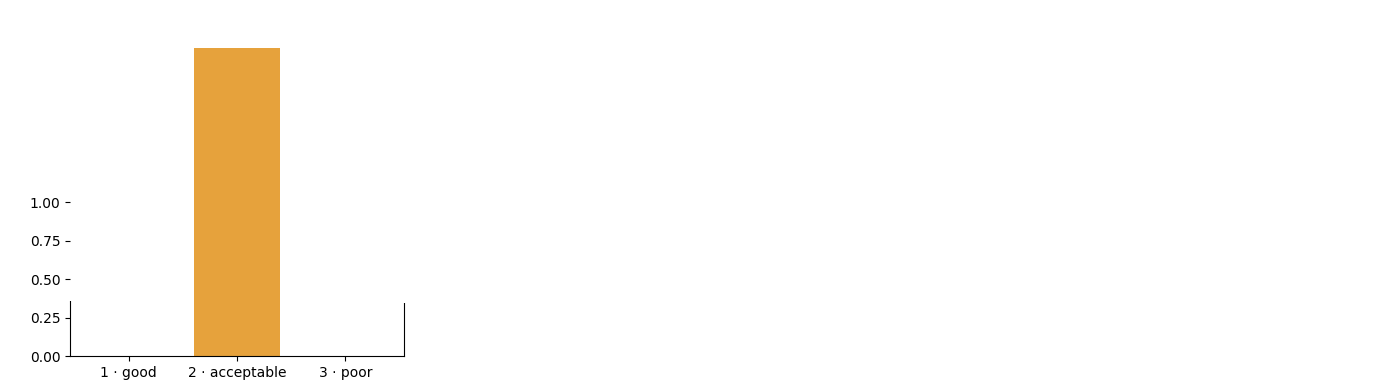


  subject  session  rating rating_label        issue_tags  marked_for_rerun  n_edits reviewer
sub-M2074 ses-2183       2   acceptable lesion_fragmented              True        0        M
sub-M2044 ses-3122       2   acceptable                               False        0        M


In [29]:
# ============================================================
# Step 6 — QC summary
# Aggregates every sidecar into qc_summary.csv and shows a small
# dashboard of rating distribution, issue tag frequency, and edit count.
# ============================================================
import sys, importlib
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
import linda_qc as q
importlib.reload(q)

import matplotlib.pyplot as plt

df = q.summarize_qc(DERIV_DIR)
csv_path = q.write_qc_summary_csv(DERIV_DIR)
print(f"QC summary written to {csv_path}")
print(f"  {len(df)} sidecar(s) found")

if not df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    # Rating distribution
    rt = df["rating"].dropna().astype(int).value_counts().reindex(
        [1, 2, 3], fill_value=0)
    axes[0].bar([f"{i} · {q.RATING_VOCAB[i]}" for i in rt.index],
                rt.values, color=["#3aaf3a", "#e6a23c", "#d9534f"])
    axes[0].set_title("Rating distribution")
    axes[0].set_ylabel("subjects")

    # Issue tag frequency
    from collections import Counter
    counter = Counter()
    for tags in df["issue_tags"].dropna():
        for t in tags.split(";"):
            t = t.strip()
            if t:
                counter[t] += 1
    if counter:
        items = counter.most_common()
        axes[1].barh([k for k, _ in items[::-1]],
                     [v for _, v in items[::-1]], color="#5078a0")
        axes[1].set_title("Issue tag frequency")
    else:
        axes[1].text(0.5, 0.5, "no issue tags",
                     ha="center", va="center"); axes[1].set_axis_off()

    # Marked for re-run
    rr = df["marked_for_rerun"].fillna(False).astype(bool).value_counts()
    axes[2].bar(["queued", "not queued"],
                [int(rr.get(True, 0)), int(rr.get(False, 0))],
                color=["#d9534f", "#a0a0a0"])
    axes[2].set_title("Re-run queue")

    plt.tight_layout(); plt.show()

    cols = ["subject", "session", "rating", "rating_label",
            "issue_tags", "marked_for_rerun", "n_edits", "reviewer"]
    print()
    print(df[cols].to_string(index=False))
# === QC WORKFLOW BLOCK END ===


#### Reset QC (clear ratings)

QC ratings persist on disk in `<lesion>.qc.json` sidecars next to each
mask, so kernel restarts don't wipe them. The cell below lets you
deliberately clear ratings — for one stage, one subject, or all
subjects. Defaults to **dry-run** so you preview what would change
before committing.


In [30]:
# === RESET QC BLOCK ===
# ============================================================
# Reset QC ratings (deliberate clear)
# ------------------------------------------------------------
# Configure the scope below. By default this is a DRY-RUN — change
# DRY_RUN = False to actually write changes.
# ============================================================
import sys, importlib
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
import linda_qc as q
importlib.reload(q)

# ---------------- CONFIG ----------------
# Scope: leave any of these as None to widen the scope.
RESET_SUBJECT = None      # e.g. "sub-M2040" — limit to one subject
RESET_SESSION = None      # e.g. "ses-842"   — limit to one session
RESET_STAGE   = None      # one of: "skull_strip", "registration", "lesion"
                          # None = clear all stages

# Behaviour
KEEP_EDITS = True         # True  = keep the per-edit history (audit trail)
                          # False = delete the .qc.json files outright
DRY_RUN    = True         # True  = preview what would change, write nothing
                          # False = actually apply the reset
# -----------------------------------------

print("Scope:")
print(f"  subject    = {RESET_SUBJECT}")
print(f"  session    = {RESET_SESSION}")
print(f"  stage      = {RESET_STAGE}  (None = all stages)")
print(f"  keep_edits = {KEEP_EDITS}")
print(f"  dry_run    = {DRY_RUN}")
print()

affected = q.reset_qc_sidecars(
    DERIV_DIR,
    subject=RESET_SUBJECT,
    session=RESET_SESSION,
    stage=RESET_STAGE,
    keep_edits=KEEP_EDITS,
    dry_run=DRY_RUN,
)

if not affected:
    print("No matching sidecars found.")
else:
    verb = "Would touch" if DRY_RUN else ("Deleted" if not KEEP_EDITS else "Reset")
    print(f"{verb} {len(affected)} sidecar(s):")
    for p in affected:
        print(f"  {p}")
    if DRY_RUN:
        print()
        print("DRY_RUN=True — no changes written. "
              "Set DRY_RUN=False and re-run to apply.")
# === END RESET QC BLOCK ===


Scope:
  subject    = None
  session    = None
  stage      = None  (None = all stages)
  keep_edits = True
  dry_run    = True

Would touch 2 sidecar(s):
  /home/jovyan/neurodesktop-storage/calmar/data/ds004884/derivatives/linda/sub-M2074/ses-2183/anat/Lesion_in_MNI.qc.json
  /home/jovyan/neurodesktop-storage/calmar/data/ds004884/derivatives/linda/sub-M2044/ses-3122/anat/Lesion_in_MNI.qc.json

DRY_RUN=True — no changes written. Set DRY_RUN=False and re-run to apply.


### Group lesion overlap map

A frequency map showing, for each MNI voxel, the proportion of subjects whose
lesion includes that voxel. This is a quick way to see where lesions cluster
across the cohort.


✓ Group lesion frequency map saved to /home/jovyan/neurodesktop-storage/calmar/reports/group_lesion_frequency.nii.gz (n=10, max overlap = 1.00)


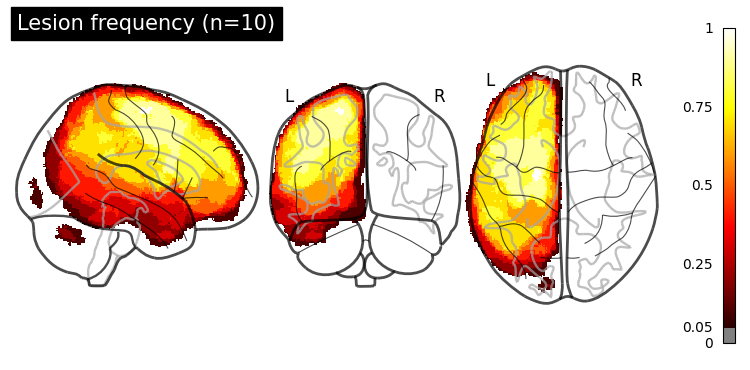

In [31]:
# ============================================================
# Build a group lesion-frequency map in MNI space.
# All subject lesions are resampled into a common reference (the
# first lesion that exists), binarized at CONFIG["LESION_THRESHOLD"],
# averaged, and saved to derivatives.
# ============================================================
have_lesion = [e for e in SUBJECTS if lesion_mni_for(e).exists()]

if not have_lesion:
    print("No lesion masks available yet — nothing to summarize.")
else:
    ref_img = nib.load(str(lesion_mni_for(have_lesion[0])))
    ref_shape = ref_img.shape
    accum = np.zeros(ref_shape, dtype=np.float32)
    n_used = 0
    for entry in have_lesion:
        try:
            img = nib.load(str(lesion_mni_for(entry)))
            if img.shape != ref_shape:
                img = image.resample_to_img(
                    img, ref_img, interpolation="nearest", force_resample=True,
                    copy_header=True,
                )
            data = (img.get_fdata() > CONFIG["LESION_THRESHOLD"]).astype(np.float32)
            accum += data
            n_used += 1
        except Exception as e:
            print(f"  ⚠ {entry['subject']}: {e}")

    if n_used == 0:
        print("No usable lesions — group map not built.")
    else:
        freq = accum / n_used                                  # 0..1
        freq_img = nib.Nifti1Image(freq, ref_img.affine, ref_img.header)
        out_path = REPORTS_DIR / "group_lesion_frequency.nii.gz"
        nib.save(freq_img, str(out_path))
        print(f"✓ Group lesion frequency map saved to {out_path} "
              f"(n={n_used}, max overlap = {freq.max():.2f})")

        # Static glass-brain plot for a quick overview.
        #
        # Threshold = 0.5/n_used so single-subject voxels (freq = 1/n)
        # are *included* — using 1.0/n_used put them right at the strict
        # threshold edge and they fell out of the display, leaving only
        # the much smaller multi-subject overlap which is invisible in
        # the MIP. vmin=0, vmax=1 pins the colormap so 1/n maps to a
        # visible mid-cmap colour rather than the dark threshold edge.
        try:
            glass_brain_disp = plotting.plot_glass_brain(
                freq_img,
                threshold=0.5 / n_used,
                colorbar=True,
                title=f"Lesion frequency (n={n_used})",
                cmap="hot",
                vmin=0, vmax=1.0,
                plot_abs=False,
            )
            plt.show()
        except Exception as e:
            print(f"  (glass-brain plot failed: {e})")

        # Interactive viewer
        try:
            from ipyniivue import NiiVue
            nv = NiiVue()
            vols = [{"path": str(out_path), "colormap": "hot", "opacity": 0.8}]
            nv.load_volumes(vols)
            from IPython.display import display as _disp
            _disp(nv)
        except Exception as e:
            print(f"  (interactive viewer failed: {e})")


### Atlas overlap

For every subject with a lesion mask, compute the overlap between the lesion and
each region of every atlas in `CONFIG["ATLASES"]`. Per-atlas results are cached
to CSV in `DERIV_DIR/lesion_atlas_overlap_<ATLAS>.csv` so the analysis only re-runs
when the source data changes.


In [32]:
!sudo apt-get update -qq
!sudo apt-get install -y -qq ca-certificates
!sudo update-ca-certificates

Updating certificates in /etc/ssl/certs...
0 added, 0 removed; done.
Running hooks in /etc/ca-certificates/update.d...
Processing triggers for ca-certificates-java (20240118) ...
done.
done.


In [33]:
# ============================================================
# Compute lesion–atlas overlap for every subject and atlas.
# Results saved as one CSV per atlas in DERIV_DIR.
# ============================================================
def _atlas_arrays(atlas):
    """Pull (img, data, labels) from any nilearn-style atlas object."""
    img = atlas.maps if hasattr(atlas.maps, "get_fdata") else nib.load(atlas.maps)
    return img, img.get_fdata(), atlas.labels


def calculate_overlap(lesion_path, atlas_img, atlas_data, atlas_labels,
                      threshold=0.5):
    """Return dict[region] -> stats, plus total lesion voxel count."""
    if not Path(lesion_path).exists():
        return {}, 0
    lesion_img = nib.load(str(lesion_path))
    lesion_resampled = image.resample_to_img(
        lesion_img, atlas_img, interpolation="nearest",
        force_resample=True, copy_header=True,
    )
    lesion_binary = (lesion_resampled.get_fdata() > threshold).astype(int)
    total = int(np.sum(lesion_binary))
    if total == 0:
        return {}, 0
    overlaps = {}
    for region_idx in np.unique(atlas_data):
        if region_idx == 0:
            continue
        region_idx = int(region_idx)
        region_mask = (atlas_data == region_idx)
        n_overlap = int(np.sum(lesion_binary & region_mask))
        if n_overlap == 0:
            continue
        n_region = int(np.sum(region_mask))
        name = (atlas_labels[region_idx]
                if region_idx < len(atlas_labels) else f"Region_{region_idx}")
        overlaps[name] = {
            "lesion_in_roi_percent": 100.0 * n_overlap / total,
            "roi_coverage_percent":  100.0 * n_overlap / n_region,
            "overlap_voxels":        n_overlap,
            "total_region_voxels":   n_region,
        }
    return overlaps, total


have_lesion = [e for e in SUBJECTS if lesion_mni_for(e).exists()]
print(f"Computing overlap for {len(have_lesion)} subject(s) across "
      f"{len(ALL_ATLASES)} atlas(es)")

OVERLAP_DFS = {}                # name -> DataFrame, kept in memory
for atlas_name, atlas in ALL_ATLASES.items():
    print(f"\n--- {atlas_name} ---")
    img, data, labels = _atlas_arrays(atlas)

    # Save the atlas image once so the QC dashboard can overlay it
    atlas_path = DERIV_DIR / f"{atlas_name}_atlas.nii.gz"
    if not atlas_path.exists():
        nib.save(img, str(atlas_path))

    rows = []
    for entry in have_lesion:
        ovl, total = calculate_overlap(
            lesion_mni_for(entry), img, data, labels,
            threshold=CONFIG["LESION_THRESHOLD"],
        )
        for region, stats in ovl.items():
            rows.append({
                "subject": entry["subject"],
                "session": entry["session"] or "",
                "atlas":   atlas_name,
                "region":  region,
                **stats,
                "total_lesion_voxels": total,
            })
    df = pd.DataFrame(rows)
    OVERLAP_DFS[atlas_name] = df
    csv = REPORTS_DIR / f"lesion_atlas_overlap_{atlas_name}.csv"
    df.to_csv(csv, index=False)
    print(f"  ✓ {len(df)} rows → {csv.name}")

print("\nDone.")


Computing overlap for 10 subject(s) across 5 atlas(es)

--- HarvardOxford ---
  ✓ 270 rows → lesion_atlas_overlap_HarvardOxford.csv

--- AAL ---
  ✓ 299 rows → lesion_atlas_overlap_AAL.csv

--- Destrieux ---
  ✓ 444 rows → lesion_atlas_overlap_Destrieux.csv

--- Schaefer400 ---
  ✓ 1168 rows → lesion_atlas_overlap_Schaefer400.csv

--- JHU ---
  ✓ 33 rows → lesion_atlas_overlap_JHU.csv

Done.


### Atlas overlap plots

Two views of the overlap data:

1. **Per-subject top regions** — a horizontal bar chart of the regions with the
   largest share of each subject's lesion (interactive).
2. **Cross-subject heatmap** — for the active atlas, the % of each subject's
   lesion that falls in each of the most frequently affected regions.
3. **Schaefer 7-network summary** — when Schaefer400 is in `CONFIG["ATLASES"]`,
   a stacked bar of lesion share per Yeo 7-network for every subject.


In [34]:
# ============================================================
# Interactive atlas-overlap plots
# - Auto-updates on every widget change (no "Plot" button)
# - Works for any atlas in OVERLAP_DFS
# - Metric toggle: "lesion in ROI %"  vs  "ROI coverage %"
# - Top-N slider lets you zoom in/out
# ============================================================
import textwrap
import ipywidgets as widgets
from IPython.display import display, clear_output


METRICS = {
    "Lesion in ROI %": "lesion_in_roi_percent",
    "ROI coverage %":  "roi_coverage_percent",
}


def _wrap(label, width=38):
    """Break long atlas labels so they fit on a y-tick."""
    if isinstance(label, bytes):
        label = label.decode("utf-8", "ignore")
    return "\n".join(textwrap.wrap(str(label), width=width)) or str(label)


def _subject_label(subj, ses):
    return f"{subj} {ses}".strip() if ses else subj


def _split_label(label):
    """Reverse of _subject_label — works for labels with/without a session."""
    if " " in label:
        subj, _, ses = label.partition(" ")
        return subj, ses
    return label, ""


def _bar_chart(df, subj, ses, metric_key, metric_label, top_n):
    sel = df[(df["subject"] == subj) & (df["session"] == ses)].copy()
    if sel.empty:
        print(f"No overlap data for {subj} {ses}.")
        return
    sel = sel.sort_values(metric_key, ascending=False).head(top_n)
    # Reverse for horizontal bar (largest at top)
    sel = sel.iloc[::-1]
    labels = [_wrap(r, 38) for r in sel["region"]]
    fig, ax = plt.subplots(figsize=(9, max(2.5, 0.42 * len(sel) + 1)))
    bars = ax.barh(labels, sel[metric_key].values, color="#3b6ea8")
    for bar, value in zip(bars, sel[metric_key].values):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                f"{value:.1f}%", va="center", fontsize=8)
    ax.set_xlabel(metric_label)
    ax.set_title(f"{subj} {ses}  —  top {len(sel)} regions")
    ax.set_xlim(0, max(sel[metric_key].max() * 1.15, 1))
    ax.grid(axis="x", linestyle=":", alpha=0.5)
    plt.tight_layout()
    plt.show()


def _heatmap(df, metric_key, metric_label, top_n):
    if df.empty:
        print("No data."); return
    # Rank regions by *maximum* contribution across subjects so small
    # regions with a single strong overlap still show up.
    region_order = (df.groupby("region")[metric_key]
                      .max().sort_values(ascending=False).head(top_n).index)
    sub = df[df["region"].isin(region_order)].copy()
    sub["subj_ses"] = sub.apply(
        lambda r: _subject_label(r["subject"], r["session"]), axis=1,
    )
    pivot = (sub.pivot_table(index="region", columns="subj_ses",
                             values=metric_key, fill_value=0)
               .loc[region_order])
    if pivot.empty:
        print("No data after filtering."); return
    fig, ax = plt.subplots(
        figsize=(max(6, 0.4 * pivot.shape[1] + 4),
                 max(3, 0.35 * pivot.shape[0] + 2))
    )
    im = ax.imshow(pivot.values, aspect="auto", cmap="magma")
    ax.set_xticks(range(pivot.shape[1]))
    ax.set_xticklabels(pivot.columns, rotation=75, ha="right", fontsize=8)
    ax.set_yticks(range(pivot.shape[0]))
    ax.set_yticklabels([_wrap(r, 30) for r in pivot.index], fontsize=8)
    ax.set_title(f"{metric_label}  —  top {pivot.shape[0]} regions "
                 f"× {pivot.shape[1]} subject(s)")
    fig.colorbar(im, ax=ax, label=metric_label)
    plt.tight_layout()
    plt.show()


def _summary_table(df, subj, ses, metric_key, top_n):
    sel = df[(df["subject"] == subj) & (df["session"] == ses)].copy()
    if sel.empty:
        return "<em>No data for this subject.</em>"
    sel = sel.sort_values(metric_key, ascending=False).head(top_n)
    total = int(sel["total_lesion_voxels"].iloc[0])
    rows = "".join(
        f"<tr><td>{r.region}</td>"
        f"<td style='text-align:right'>{r.lesion_in_roi_percent:.1f}%</td>"
        f"<td style='text-align:right'>{r.roi_coverage_percent:.1f}%</td>"
        f"<td style='text-align:right'>{int(r.overlap_voxels)}</td></tr>"
        for r in sel.itertuples()
    )
    return (
        f"<p><b>Total lesion volume:</b> {total} voxels &nbsp; "
        f"<b>Regions overlapped:</b> {len(sel)}</p>"
        f"<table style='border-collapse:collapse; font-size:12px'>"
        f"<tr style='background:#2c3e50; color:white'>"
        f"<th style='padding:4px 8px; text-align:left'>Region</th>"
        f"<th style='padding:4px 8px'>Lesion%</th>"
        f"<th style='padding:4px 8px'>ROI%</th>"
        f"<th style='padding:4px 8px'>Voxels</th></tr>"
        f"{rows}</table>"
    )


if not OVERLAP_DFS:
    print("Run the atlas-overlap cell first — no data to plot.")
else:
    # ---- Widgets ----------------------------------------------
    atlas_dd = widgets.Dropdown(
        options=list(OVERLAP_DFS.keys()),
        value=(CONFIG["DEFAULT_ATLAS"] if CONFIG["DEFAULT_ATLAS"] in OVERLAP_DFS
               else list(OVERLAP_DFS.keys())[0]),
        description="Atlas:",
        layout=widgets.Layout(width="240px"),
        style={"description_width": "initial"},
    )
    subj_dd = widgets.Dropdown(
        options=[], description="Subject:",
        layout=widgets.Layout(width="300px"),
        style={"description_width": "initial"},
    )
    metric_tb = widgets.ToggleButtons(
        options=list(METRICS.keys()), description="Metric:",
        style={"description_width": "initial"},
    )
    top_n_sl = widgets.IntSlider(
        value=20, min=5, max=50, step=1, description="Top N:",
        continuous_update=False,
        layout=widgets.Layout(width="320px"),
        style={"description_width": "initial"},
    )

    def _refresh_subjects(*_):
        df = OVERLAP_DFS[atlas_dd.value]
        pairs = sorted(set(zip(df["subject"], df["session"].fillna(""))))
        labels = [_subject_label(s, ses) for s, ses in pairs]
        subj_dd.options = labels
        if labels:
            subj_dd.value = labels[0]

    atlas_dd.observe(_refresh_subjects, names="value")
    _refresh_subjects()

    bar_out   = widgets.Output()
    table_out = widgets.Output()
    heat_out  = widgets.Output()

    def _redraw(*_):
        from IPython.display import HTML
        if not OVERLAP_DFS:
            return
        df = OVERLAP_DFS[atlas_dd.value]
        metric_label = metric_tb.value
        metric_key   = METRICS[metric_label]
        subj, ses    = _split_label(subj_dd.value) if subj_dd.value else ("", "")
        top_n        = top_n_sl.value

        with bar_out:
            clear_output(wait=True)
            _bar_chart(df, subj, ses, metric_key, metric_label, top_n)
        with table_out:
            clear_output(wait=True)
            display(HTML(_summary_table(df, subj, ses, metric_key, top_n)))
        with heat_out:
            clear_output(wait=True)
            _heatmap(df, metric_key, metric_label, top_n)

    for w in (atlas_dd, subj_dd, metric_tb, top_n_sl):
        w.observe(_redraw, names="value")

    controls = widgets.VBox([
        widgets.HBox([atlas_dd, subj_dd]),
        widgets.HBox([metric_tb, top_n_sl]),
    ])

    tabs = widgets.Tab(children=[
        widgets.VBox([bar_out, table_out]),
        heat_out,
    ])
    tabs.set_title(0, "Per-subject")
    tabs.set_title(1, "Cross-subject heatmap")

    display(controls, tabs)
    _redraw()


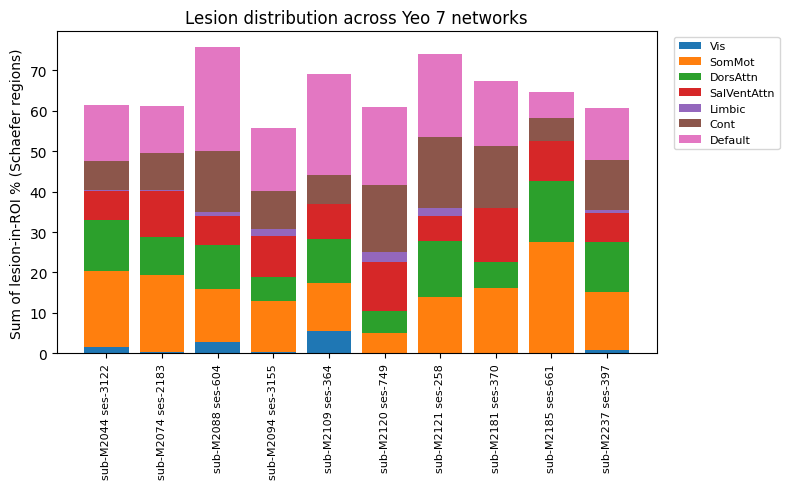

In [35]:
# ============================================================
# Schaefer 7-network summary (only runs if Schaefer400 was processed)
# ============================================================
NET_NAMES = ["Vis", "SomMot", "DorsAttn", "SalVentAttn", "Limbic", "Cont", "Default"]


def _net_for(label):
    """Map a Schaefer region label to one of the 7 Yeo networks."""
    if isinstance(label, bytes):
        label = label.decode("utf-8", "ignore")
    for n in NET_NAMES:
        if n in label:
            return n
    return "Other"


if "Schaefer400" not in OVERLAP_DFS or OVERLAP_DFS["Schaefer400"].empty:
    print("Schaefer400 overlap not available — skipping network summary.")
else:
    df = OVERLAP_DFS["Schaefer400"].copy()
    df["network"] = df["region"].astype(str).map(_net_for)
    summary = (df.groupby(["subject", "session", "network"])
                 ["lesion_in_roi_percent"].sum().unstack(fill_value=0))
    cols = [n for n in NET_NAMES if n in summary.columns]
    if "Other" in summary.columns:
        cols.append("Other")
    summary = summary[cols]
    fig, ax = plt.subplots(figsize=(max(6, 0.5 * len(summary) + 3), 5))
    bottom = np.zeros(len(summary))
    x = np.arange(len(summary))
    for col in summary.columns:
        ax.bar(x, summary[col].values, bottom=bottom, label=col)
        bottom += summary[col].values
    ax.set_xticks(x)
    ax.set_xticklabels([f"{s} {ses}".strip() for s, ses in summary.index],
                       rotation=90, fontsize=8)
    ax.set_ylabel("Sum of lesion-in-ROI % (Schaefer regions)")
    ax.set_title("Lesion distribution across Yeo 7 networks")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()


### Per-subject report (interactive + PDF)

Pick a subject and an atlas to see the full regional breakdown alongside the
lesion volume in MNI space. The same data can be exported as PDF reports — set
`GENERATE_ALL = True` to write one PDF per subject for the active atlas.


In [ ]:
# ============================================================
# Interactive per-subject report (table + viewer)
# ============================================================
from ipyniivue import NiiVue
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output


def _report_html(df, subj, ses, atlas_name):
    sel = df[(df["subject"] == subj) & (df["session"] == (ses or ""))].copy()
    if sel.empty:
        return f"<p>No data for {subj} {ses}.</p>"
    sel = sel.sort_values("lesion_in_roi_percent", ascending=False)
    total = int(sel["total_lesion_voxels"].iloc[0])
    rows = "".join(
        f"<tr><td>{r.region}</td>"
        f"<td style='text-align:right'>{r.lesion_in_roi_percent:.1f}%</td>"
        f"<td style='text-align:right'>{r.roi_coverage_percent:.1f}%</td>"
        f"<td style='text-align:right'>{int(r.overlap_voxels)}</td></tr>"
        for r in sel.itertuples()
    )
    return f"""
    <h3>{subj} {ses or ''} — {atlas_name}</h3>
    <p><b>Total lesion volume:</b> {total} voxels &nbsp;
       <b>Regions affected:</b> {len(sel)}</p>
    <table style='border-collapse:collapse; font-size:12px'>
      <tr style='background:#2c3e50; color:white'>
        <th style='padding:6px 10px; text-align:left'>Region</th>
        <th style='padding:6px 10px'>Lesion in ROI</th>
        <th style='padding:6px 10px'>ROI coverage</th>
        <th style='padding:6px 10px'>Voxels</th>
      </tr>{rows}
    </table>"""


if not OVERLAP_DFS:
    print("Run the atlas-overlap cell first.")
else:
    atlas_dd = widgets.Dropdown(
        options=list(OVERLAP_DFS.keys()), description="Atlas:",
        value=(CONFIG["DEFAULT_ATLAS"] if CONFIG["DEFAULT_ATLAS"] in OVERLAP_DFS
               else list(OVERLAP_DFS.keys())[0]),
    )
    subj_dd = widgets.Dropdown(description="Subject:", options=[])

    def _refresh_subjects(*_):
        df = OVERLAP_DFS[atlas_dd.value]
        pairs = sorted(set(zip(df["subject"], df["session"])))
        subj_dd.options = [f"{s} {ses}".strip() for s, ses in pairs]
        if subj_dd.options:
            subj_dd.value = subj_dd.options[0]

    _refresh_subjects()
    atlas_dd.observe(_refresh_subjects, names="value")

    report_out = widgets.Output()
    viz_out    = widgets.Output()

    def _show_report(*_):
        with report_out:
            clear_output()
            df = OVERLAP_DFS[atlas_dd.value]
            label = subj_dd.value
            subj, _, ses = label.partition(" ")
            display(HTML(_report_html(df, subj, ses, atlas_dd.value)))
        with viz_out:
            clear_output()
            label = subj_dd.value
            subj, _, ses = label.partition(" ")
            entry = next((e for e in SUBJECTS
                          if e["subject"] == subj
                          and (e["session"] or "") == ses), None)
            if entry is None:
                return
            d = deriv_path_for(entry)
            atlas_path = DERIV_DIR / f"{atlas_dd.value}_atlas.nii.gz"
            vols = []
            if (d / "Subject_in_MNI.nii.gz").exists():
                vols.append({"path": str(d / "Subject_in_MNI.nii.gz")})
            if atlas_path.exists():
                vols.append({"path": str(atlas_path),
                             "colormap": "viridis", "opacity": 0.4})
            if (d / "Lesion_in_MNI.nii.gz").exists():
                vols.append({"path": str(d / "Lesion_in_MNI.nii.gz"),
                             "colormap": "red", "opacity": 0.6})
            nv = NiiVue()
            nv.load_volumes(vols)
            display(nv)

    atlas_dd.observe(_show_report, names="value")
    subj_dd.observe(_show_report, names="value")

    display(HTML("<h4>Interactive lesion report</h3>"))
    display(widgets.HBox([atlas_dd, subj_dd]))
    display(viz_out)
    display(report_out)
    _show_report()


Output()

Output()

In [ ]:
# ============================================================
# PDF report generator — uses the in-memory OVERLAP_DFS
# ============================================================
from matplotlib.backends.backend_pdf import PdfPages

GENERATE_ALL = False                                  # set True for batch
PDF_ATLAS    = CONFIG["DEFAULT_ATLAS"]
PDF_SUBJECT  = None                                   # None = first available
PDF_SESSION  = None                                   # None = first available

_pdf_dir = REPORTS_DIR / "pdfs"
_pdf_dir.mkdir(parents=True, exist_ok=True)


def write_pdf(subj, ses, df, atlas_name):
    sel = df[(df["subject"] == subj) & (df["session"] == (ses or ""))].copy()
    if sel.empty:
        print(f"  no data for {subj} {ses} ({atlas_name})"); return None
    sel = sel.sort_values("lesion_in_roi_percent", ascending=False)
    total = int(sel["total_lesion_voxels"].iloc[0])
    fname = _pdf_dir / f"{subj}_{ses or 'no-ses'}_{atlas_name}.pdf"

    with PdfPages(str(fname)) as pdf:
        # Page 1 — summary + bar chart
        fig = plt.figure(figsize=(8.5, 11))
        plt.suptitle(f"Lesion report  —  {subj} {ses or ''}  ({atlas_name})",
                     fontsize=14, fontweight="bold")
        ax_meta = fig.add_axes([0.08, 0.78, 0.84, 0.12]); ax_meta.axis("off")
        ax_meta.text(0, 0.6,
            f"Date: {datetime.now():%Y-%m-%d %H:%M}\n"
            f"Total lesion volume: {total} voxels\n"
            f"Regions affected: {len(sel)}",
            family="monospace", fontsize=10)
        ax_bar = fig.add_axes([0.08, 0.08, 0.84, 0.62])
        top = sel.head(20)
        ax_bar.barh(top["region"][::-1], top["lesion_in_roi_percent"][::-1])
        ax_bar.set_xlabel("% of lesion in ROI")
        ax_bar.set_title(f"Top {len(top)} affected regions")
        pdf.savefig(fig); plt.close(fig)

        # Subsequent pages — full table
        rows_per_page = 35
        for start in range(0, len(sel), rows_per_page):
            chunk = sel.iloc[start:start + rows_per_page]
            fig = plt.figure(figsize=(8.5, 11))
            plt.suptitle(f"All regions  —  rows {start + 1}-{start + len(chunk)} "
                         f"of {len(sel)}", fontsize=11)
            ax = fig.add_axes([0.05, 0.05, 0.9, 0.85]); ax.axis("off")
            text = (f"{'Rank':<5s}{'Region':<42s}"
                    f"{'Lesion%':>10s}{'ROI%':>8s}{'vox':>8s}\n"
                    + "-" * 75 + "\n")
            for i, row in enumerate(chunk.itertuples(), start + 1):
                text += (f"{i:<5d}{row.region[:40]:<42s}"
                         f"{row.lesion_in_roi_percent:>9.1f}%"
                         f"{row.roi_coverage_percent:>7.1f}%"
                         f"{int(row.overlap_voxels):>8d}\n")
            ax.text(0, 1, text, family="monospace", fontsize=8,
                    verticalalignment="top")
            pdf.savefig(fig); plt.close(fig)
    print(f"  ✓ {fname}")
    return fname


df = OVERLAP_DFS.get(PDF_ATLAS)
if df is None or df.empty:
    print(f"No data for atlas '{PDF_ATLAS}'.")
else:
    targets = (sorted(set(zip(df["subject"], df["session"])))
               if GENERATE_ALL
               else [(PDF_SUBJECT or df["subject"].iloc[0],
                      PDF_SESSION or df["session"].iloc[0])])
    print(f"Writing {len(targets)} PDF(s) to {_pdf_dir}")
    for s, sess in targets:
        write_pdf(s, sess, df, PDF_ATLAS)


### KB-driven clinical interpretation

For the selected subject, queries the aphasia knowledge base with the
patient's lesion location (against AAL — finer parcellation, broader KB
coverage) and any behavioural data found in `participants.tsv`. The
report shows damaged regions in HarvardOxford terminology (clinician-
friendly), then KB-derived predictions for likely impairments,
therapy responses, and prognostic markers — every claim citation-anchored.


In [ ]:
# ============================================================
# Per-subject KB interpretation report (HTML)
# ------------------------------------------------------------
# Combines imaging pipeline outputs with the aphasia KB to
# produce a clinician-facing interpretation for one subject.
# ============================================================
INTERP_SUBJECT_IDX     = 0       # None = follow CMP/DIAG/TEST chain
INTERP_KB_ATLASES      = ["AAL", "HarvardOxford", "Destrieux", "Schaefer400", "JHU"]
INTERP_DISPLAY_ATLAS   = "HarvardOxford"
INTERP_HIGH_CONF_ONLY  = False
INTERP_INCLUDE_DRAFTS  = True
INTERP_MIN_OVERLAP_PCT = 5.0
INTERP_TOP_N           = 5
INTERP_MAX_ROIS        = 15  # max damaged ROIs shown

import sys, importlib
from pathlib import Path
import pandas as pd

_APHASIA_COMPONENTS = {
    "brocas_aphasia":           ("-", "+", "-"),
    "wernickes_aphasia":        ("+", "-", "-"),
    "conduction_aphasia":       ("+", "+", "-"),
    "anomic_aphasia":           ("+", "+", "+"),
    "global_aphasia":           ("-", "-", "-"),
    "transcortical_motor_aphasia":   ("-", "+", "+"),
    "transcortical_sensory_aphasia": ("+", "-", "+"),
    "mixed_transcortical_aphasia":   ("-", "-", "+"),
}
_APHASIA_ALIASES = {
    "broca": "brocas_aphasia", "broca's": "brocas_aphasia",
    "brocas": "brocas_aphasia", "broca aphasia": "brocas_aphasia",
    "wernicke": "wernickes_aphasia", "wernicke's": "wernickes_aphasia",
    "wernickes": "wernickes_aphasia", "wernicke aphasia": "wernickes_aphasia",
    "conduction": "conduction_aphasia",
    "anomic": "anomic_aphasia", "anomia": "anomic_aphasia",
    "global": "global_aphasia",
    "transcortical motor": "transcortical_motor_aphasia",
    "tcm": "transcortical_motor_aphasia",
    "transcortical sensory": "transcortical_sensory_aphasia",
    "tcs": "transcortical_sensory_aphasia",
    "mixed transcortical": "mixed_transcortical_aphasia",
}

def _decompose_aphasia(name, color='#666'):
    if not name: return ''
    key = name.lower().strip()
    canonical = _APHASIA_ALIASES.get(key, key)
    pattern = _APHASIA_COMPONENTS.get(canonical)
    if not pattern: return ''
    f, c, r = pattern
    def _sym(v):
        if v == '+': return "<span style='color:#2e7d32'>+</span>"
        if v == '-': return "<span style='color:#c62828'>&#8722;</span>"
        return "<span style='color:#888'>~</span>"
    return (f" <small style='color:{color};font-family:monospace'>"
            f"[flu {_sym(f)} &middot; comp {_sym(c)} &middot; rep {_sym(r)}]</small>")

# ---- Load the KB ---------------------------------------------------
sys.path.insert(0, str((PROJECT_DIR / 'aphasia-kb').resolve()))
import aphasia_kb
importlib.reload(aphasia_kb)
from aphasia_kb import KnowledgeBase

_include = (('approved', 'in_review', 'draft') if INTERP_INCLUDE_DRAFTS
            else ('approved',))
kb = KnowledgeBase(PROJECT_DIR / 'aphasia-kb', include=_include)
print(kb.summary())

# ---- Resolve subject ----------------------------------------------
_idx = INTERP_SUBJECT_IDX
if _idx is None:
    _idx = (globals().get('CMP_SUBJECT_IDX')
            or globals().get('DIAG_SUBJECT_IDX')
            or globals().get('TEST_SUBJECT_IDX') or 0)
if not 0 <= _idx < len(SUBJECTS):
    print(f'index {_idx} out of range (0..{len(SUBJECTS)-1})')
else:
    e = SUBJECTS[_idx]
    print(f'\nInterpreting: [{_idx}] {e["subject"]} {e["session"] or ""}')

    # ---- 1. Imaging interpretation — query EACH available atlas ---
    imaging_per_atlas = []
    imaging_chunks = []
    for _atl in INTERP_KB_ATLASES:
        _csv = REPORTS_DIR / f'lesion_atlas_overlap_{_atl}.csv'
        if not _csv.exists():
            continue
        _ov = pd.read_csv(_csv)
        _sub_ov = _ov[_ov['subject'] == e['subject']]
        if _sub_ov.empty:
            continue
        _interp = kb.interpret_overlap(
            _sub_ov, atlas=_atl,
            region_col='region', weight_col='lesion_in_roi_percent',
            min_overlap=INTERP_MIN_OVERLAP_PCT,
            min_confidence=('high' if INTERP_HIGH_CONF_ONLY else None),
        )
        if _interp is None or _interp.empty:
            imaging_per_atlas.append((_atl, 0))
            continue
        _interp = _interp.copy()
        _interp['_atlas'] = _atl
        imaging_chunks.append(_interp)
        imaging_per_atlas.append((_atl, len(_interp)))

    if imaging_chunks:
        all_imaging = pd.concat(imaging_chunks, ignore_index=True)
        imaging_interp = (
            all_imaging.groupby(['target', 'target_kind'], as_index=False)
            .agg(score=('score', 'sum'),
                 n_findings=('n_findings', 'sum'),
                 citations=('citations',
                            lambda s: sorted({c for lst in s for c in lst})),
                 source_atlases=('_atlas', lambda s: sorted(set(s))))
        )
        imaging_interp['direction'] = imaging_interp['score'].apply(
            lambda v: 'likely' if v > 0 else ('unlikely' if v < 0 else 'ambiguous'))
        imaging_interp = imaging_interp.sort_values(
            'score', key=lambda s: s.abs(), ascending=False).reset_index(drop=True)
    else:
        imaging_interp = pd.DataFrame()

    # Damaged regions for the clinician-facing display (HarvardOxford)
    ho_csv = REPORTS_DIR / f'lesion_atlas_overlap_{INTERP_DISPLAY_ATLAS}.csv'
    if ho_csv.exists():
        ov_disp = pd.read_csv(ho_csv)
        sub_ov_disp = ov_disp[ov_disp['subject'] == e['subject']]
        damaged_disp = (sub_ov_disp[sub_ov_disp['lesion_in_roi_percent']
                                    >= INTERP_MIN_OVERLAP_PCT]
                        .sort_values('lesion_in_roi_percent',
                                     ascending=False).head(INTERP_MAX_ROIS))
    else:
        damaged_disp = pd.DataFrame()

    print('  KB findings by atlas:')
    for _atl, _n in imaging_per_atlas:
        print(f'    . {_atl:14s} {_n:3d} (target,target_kind) rows')

    # ---- 2. Behavioural data (participants.tsv) ------------------
    def _load_participant_row(sub_id):
        ptsv = RAW_DATASET_DIR / 'participants.tsv'
        if not ptsv.exists():
            return {}
        df = pd.read_csv(ptsv, sep='\t', dtype=str)
        rows = df[df['participant_id'] == sub_id]
        if rows.empty: return {}
        return {k: (None if pd.isna(v) or v == 'n/a' else v)
                for k, v in rows.iloc[0].items()}

    def _row_to_predictors(row):
        d = {}
        if not row: return d
        if row.get('wab_aq') not in (None, ''):
            try: d['severity_metric'] = {'instrument': 'WAB-AQ',
                                          'value': float(row['wab_aq'])}
            except ValueError: pass
        if row.get('age_at_stroke') not in (None, ''):
            try: d['age'] = float(row['age_at_stroke'])
            except ValueError: pass
        if row.get('wab_days') not in (None, ''):
            try: d['time_post_onset'] = float(row['wab_days'])
            except ValueError: pass
        if row.get('sex'): d['sex'] = row['sex']
        return d

    raw_row = _load_participant_row(e['subject'])
    pred_dict = _row_to_predictors(raw_row)

    # ── Post-onset stage classification ──────────────────────────────────────
    # Acute: <14 days  |  Subacute: 14–180 days  |  Chronic: >180 days
    # Based on WAB days (time between stroke and WAB assessment).
    _wab_days_raw = (raw_row or {}).get("wab_days")
    _days_post_onset = None
    try:
        _days_post_onset = float(_wab_days_raw) if _wab_days_raw else None
    except (ValueError, TypeError):
        pass

    def _classify_stage(days):
        if days is None:
            return None, "unknown"
        if days < 14:
            return "acute",    "Acute (<2 wk)"
        if days < 180:
            return "subacute", "Subacute (2 wk–6 mo)"
        return "chronic",      "Chronic (>6 mo)"

    _stage_id, _stage_label = _classify_stage(_days_post_onset)

    _STAGE_COLORS = {
        "acute":    ("#d32f2f", "#ffebee"),   # red
        "subacute": ("#e65100", "#fff3e0"),   # orange
        "chronic":  ("#1565c0", "#e3f2fd"),   # blue
        None:       ("#555555", "#f5f5f5"),   # grey
    }
    _stage_fg, _stage_bg = _STAGE_COLORS.get(_stage_id, _STAGE_COLORS[None])

    def _stage_badge(stage_id, label):
        fg, bg = _STAGE_COLORS.get(stage_id, _STAGE_COLORS[None])
        return (f"<span style='background:{bg};color:{fg};border:1px solid {fg};"
                f"padding:1px 8px;border-radius:3px;font-size:11px;font-weight:bold'>"
                f"{label}</span>")

    # ── Parse therapy evidence stages from KB YAML/MD files ──────────────────
    # Scan findings in therapy files for sample.population stage keywords.
    # Returns a dict: therapy_id -> list of evidence stage IDs found.
    import re as _re
    _STAGE_PATTERNS = [
        ("acute",    _re.compile(r'acute', _re.I)),
        ("subacute", _re.compile(r'subacute', _re.I)),
        ("chronic",  _re.compile(r'chronic|>[=]?\s*6\s*months?|>=\s*180', _re.I)),
    ]

    def _therapy_evidence_stages(kb_root):
        """Return {therapy_id: set_of_stage_ids} from YAML/MD therapy files."""
        import yaml as _yaml
        result = {}
        therapy_dir = Path(str(kb_root)) / "therapies"
        for f in therapy_dir.glob("*.md"):
            try:
                text = f.read_text(encoding="utf-8")
                # Extract YAML front matter
                m = _re.match(r"^---
(.*?)
---", text, _re.DOTALL)
                if not m:
                    continue
                obj = _yaml.safe_load(m.group(1))
                tid = obj.get("id") or f.stem
                stages = set()
                for finding in (obj.get("findings") or []):
                    pop = str((finding.get("sample") or {}).get("population") or "")
                    for stage_id, pat in _STAGE_PATTERNS:
                        if pat.search(pop):
                            stages.add(stage_id)
                if stages:
                    result[tid] = stages
            except Exception:
                pass
        return result

    _therapy_stages = {}
    try:
        _therapy_stages = _therapy_evidence_stages(_APHASIA_KB_ROOT
                          if '_APHASIA_KB_ROOT' in dir() else
                          Path(globals().get('_APHASIA_KB_ROOT',
                              str(Path.cwd().parent / 'aphasia-kb'))))
    except Exception as _tse:
        pass  # non-critical — badges just won't appear

    # Imaging-derived predictor: total lesion volume in mL.
    _lesion_vol_ml = None
    try:
        import nibabel as _nib
        _les = lesion_mni_for(e)
        if _les.exists():
            _img = _nib.load(str(_les))
            _vox_mm3 = abs(_img.affine[0,0] * _img.affine[1,1] * _img.affine[2,2])
            _lesion_vol_ml = float((_img.get_fdata() > 0).sum() * _vox_mm3 / 1000.0)
            pred_dict['lesion_volume'] = _lesion_vol_ml
    except Exception as _exc:
        print(f'  lesion_volume not computed: {_exc}')

    if pred_dict:
        pred_interp = kb.interpret_predictors(
            pred_dict,
            min_confidence=('high' if INTERP_HIGH_CONF_ONLY else None),
        )
    else:
        pred_interp = pd.DataFrame()

    # ---- 3. Therapy recommendations (impairment-based) -----------
    _predicted_impairments = []
    if not imaging_interp.empty:
        _predicted_impairments += list(
            imaging_interp[imaging_interp['target_kind'] == 'impairment']['target']
            .head(INTERP_TOP_N * 2)
        )
    if not pred_interp.empty:
        _predicted_impairments += list(
            pred_interp[pred_interp['target_kind'] == 'impairment']['target']
            .head(INTERP_TOP_N)
        )
    # dedup, order-preserving
    _predicted_impairments = list(dict.fromkeys(_predicted_impairments))

    # Derive behavioral impairments from WAB type (primary signal)
    _wab_type_str = (raw_row or {}).get('wab_type') or ''
    _behavioral_impairments = kb.wab_to_impairments(_wab_type_str)
    print(f'  WAB type: {_wab_type_str!r} -> behavioral impairments: {_behavioral_impairments}')

    therapy_recs = kb.interpret_therapies(
        _predicted_impairments,
        behavioral_impairment_ids=_behavioral_impairments,
        max_results=INTERP_TOP_N,
    )

    # ---- 4. Render HTML report -----------------------------------
    from IPython.display import display, HTML

    def _badge(direction):
        if direction == 'likely':
            return ('<span style="background:#28a745;color:white;'
                    'padding:1px 6px;border-radius:3px;font-size:11px">LIKELY</span>')
        if direction == 'unlikely':
            return ('<span style="background:#dc3545;color:white;'
                    'padding:1px 6px;border-radius:3px;font-size:11px">UNLIKELY</span>')
        return ('<span style="background:#6c757d;color:white;'
                'padding:1px 6px;border-radius:3px;font-size:11px">AMBIGUOUS</span>')

    def _strength_stars(score):
        s = abs(score)
        if s < 0.01:  return '&#8212;', 'no net evidence'
        if s < 1.5:   return '&#9733;', 'weak / preliminary'
        if s < 3.0:   return '&#9733;&#9733;', 'moderate'
        if s < 6.0:   return '&#9733;&#9733;&#9733;', 'strong'
        return '&#9733;&#9733;&#9733;&#9733;', 'very strong / replicated'

    def _interp_table(df, kind, top_n):
        if df is None or df.empty:
            return f"<p style='color:#666'><em>No {kind} predictions.</em></p>"
        sub = df[df['target_kind'] == kind].head(top_n)
        if sub.empty:
            return f"<p style='color:#666'><em>No {kind} predictions.</em></p>"
        rows = []
        for _, r in sub.iterrows():
            cits = ', '.join(r.get('citations') or [])
            stars, lbl = _strength_stars(r['score'])
            star_html = (f"<span title='raw score = {r['score']:+.2f}'"
                         f" style='color:#f0a500;font-size:14px;letter-spacing:1px'>"
                         f"{stars}</span> "
                         f"<small style='color:#666'>{lbl}</small>")
            human_name = kb.label_for(r['target'])
            decomp = _decompose_aphasia(r['target']) if kind == 'impairment' else ''
            id_note = (f" <small style='color:#aaa;font-size:10px'>({r['target']})</small>"
                       if human_name != r['target'] else '')
            rows.append(f"<tr><td style='padding:4px 2px'>{_badge(r['direction'])}</td>"
                        f"<td style='padding:4px 8px'><b>{human_name}</b>{id_note}{decomp}</td>"
                        f"<td style='padding:4px 8px'>{star_html}</td>"
                        f"<td style='text-align:center;padding:4px 4px'>{r['n_findings']}</td>"
                        f"<td style='font-size:11px;color:#666;padding:4px 4px'>{cits}</td></tr>")
        return ("<table style='border-collapse:collapse;font-size:13px;width:100%'>"
                "<tr style='background:#2c3e50;color:white'>"
                "<th style='padding:4px 4px'></th>"
                "<th style='text-align:left;padding:4px 8px'>Predicted finding</th>"
                "<th style='padding:4px 8px;text-align:left'>Evidence strength</th>"
                "<th style='padding:4px 4px'>N findings</th>"
                "<th style='text-align:left;padding:4px 4px'>Citations</th></tr>"
                + ''.join(rows) + '</table>')

    def _interp_table_all(df, top_n):
        if df is None or df.empty:
            return "<p style='color:#666'><em>No outcome predictions.</em></p>"
        sub = df.head(top_n)
        rows = []
        for _, r in sub.iterrows():
            cits = ', '.join(r.get('citations') or [])
            stars, lbl = _strength_stars(r['score'])
            star_html = (f"<span title='raw score = {r['score']:+.2f}'"
                         f" style='color:#f0a500;font-size:14px;letter-spacing:1px'>"
                         f"{stars}</span> "
                         f"<small style='color:#666'>{lbl}</small>")
            human_name = kb.label_for(r['target'])
            id_note = (f" <small style='color:#aaa;font-size:10px'>({r['target']})</small>"
                       if human_name != r['target'] else '')
            kind_badge = (f"<small style='color:#888;font-size:10px'>"
                          f"[{r.get('target_kind','')}]</small> ")
            rows.append(f"<tr><td style='padding:4px 2px'>{_badge(r['direction'])}</td>"
                        f"<td style='padding:4px 8px'>{kind_badge}<b>{human_name}</b>{id_note}</td>"
                        f"<td style='padding:4px 8px'>{star_html}</td>"
                        f"<td style='text-align:center;padding:4px 4px'>{r['n_findings']}</td>"
                        f"<td style='font-size:11px;color:#666;padding:4px 4px'>{cits}</td></tr>")
        return ("<table style='border-collapse:collapse;font-size:13px;width:100%'>"
                "<tr style='background:#2c3e50;color:white'>"
                "<th style='padding:4px 4px'></th>"
                "<th style='text-align:left;padding:4px 8px'>Predicted outcome</th>"
                "<th style='padding:4px 8px;text-align:left'>Evidence strength</th>"
                "<th style='padding:4px 4px'>N findings</th>"
                "<th style='text-align:left;padding:4px 4px'>Citations</th></tr>"
                + ''.join(rows) + '</table>')

    def _therapy_table(df):
        if df is None or df.empty:
            return ("<p style='color:#666'><em>No therapy recommendations matched. "
                    "Add more impairment-targeted therapy KB entries to populate this section.</em></p>")
        # colour map for RTSS ingredient categories
        _CAT_COLOR = {
            "procedure":      "#1a6b3a",
            "dose_parameter": "#7b3f00",
            "technology":     "#1a3a6b",
        }
        def _ing_badges(rtss_summary):
            if not rtss_summary:
                return "<em style='color:#aaa'>—</em>"
            badges = []
            for s in rtss_summary:
                # parse "Name (category)" back apart
                if " (" in s and s.endswith(")"):
                    label, cat = s.rsplit(" (", 1)
                    cat = cat.rstrip(")")
                else:
                    label, cat = s, ""
                color = _CAT_COLOR.get(cat, "#555")
                badges.append(
                    f"<span style='display:inline-block;margin:1px 2px;padding:1px 6px;"
                    f"border-radius:3px;font-size:10px;color:white;background:{color}'>"
                    f"{label}</span>"
                )
            return " ".join(badges)
        rows = []
        for _, r in df.iterrows():
            beh = r.get('behavioral_matched') or []
            les = r.get('lesion_matched') or []
            beh_str = ', '.join(kb.label_for(i) for i in beh)
            les_str = ', '.join(kb.label_for(i) for i in les)
            matched_parts = []
            if beh_str:
                matched_parts.append(f"<b>{beh_str}</b> <small style='color:#28a745'>(behavioural)</small>")
            if les_str:
                matched_parts.append(f"{les_str} <small style='color:#888'>(lesion)</small>")
            matched = '; '.join(matched_parts) if matched_parts else '—'
            cits = ', '.join(r.get('citations') or [])
            desc = str(r.get('short_description') or '')
            desc_short = (desc[:120] + '&#8230;') if len(desc) > 120 else desc
            ing_html = _ing_badges(r.get('rtss_summary') or [])
            # Stage mismatch warning
            _t_id = str(r.get("therapy_id") or r.get("id") or "")
            _t_stages = _therapy_stages.get(_t_id, set())
            _stage_warn = ""
            if _stage_id and _t_stages and _stage_id not in _t_stages:
                _ev_stages = " / ".join(sorted(_t_stages))
                _stage_warn = (
                    f" <span title='Evidence for this therapy comes from "
                    f"{_ev_stages} patients; current patient is {_stage_label}.'"
                    f" style='cursor:help;color:#e65100;font-size:13px'>&#9888;</span>"
                )
            rows.append(
                f"<tr>"
                f"<td style='padding:6px 8px;font-weight:bold;white-space:nowrap;vertical-align:top'>"
                f"  {r['therapy_name']}{_stage_warn}</td>"
                f"<td style='padding:6px 8px;font-size:12px;color:#444;vertical-align:top'>{matched}</td>"
                f"<td style='padding:6px 8px;font-size:11px;vertical-align:top'>{ing_html}</td>"
                f"<td style='padding:6px 8px;font-size:11px;color:#666;vertical-align:top'>{desc_short}</td>"
                f"<td style='padding:6px 4px;font-size:11px;color:#777;vertical-align:top'>{cits}</td>"
                f"</tr>"
            )
        legend = (
            "<p style='font-size:10px;color:#777;margin:4px 0 0 0'>"
            "<span style='background:#1a6b3a;color:white;padding:1px 5px;border-radius:3px'>procedure</span>&nbsp;"
            "<span style='background:#7b3f00;color:white;padding:1px 5px;border-radius:3px'>dose parameter</span>&nbsp;"
            "<span style='background:#1a3a6b;color:white;padding:1px 5px;border-radius:3px'>technology</span>"
            "</p>"
        )
        return (
            "<table style='border-collapse:collapse;font-size:13px;width:100%'>"
            "<tr style='background:#2c3e50;color:white'>"
            "<th style='text-align:left;padding:4px 8px'>Therapy</th>"
            "<th style='text-align:left;padding:4px 8px'>Addresses impairment(s)</th>"
            "<th style='text-align:left;padding:4px 8px'>Active ingredients (RTSS)</th>"
            "<th style='text-align:left;padding:4px 8px'>Brief description</th>"
            "<th style='text-align:left;padding:4px 4px'>Citations</th>"
            '</tr>'
            + ''.join(rows)
            + '</table>'
            + legend
        )

    def _damaged_regions_html(df):
        if df is None or df.empty:
            return "<p style='color:#666'><em>No damaged regions above threshold.</em></p>"
        rows = [f"<tr>"
                f"<td style='padding:3px 8px'>{r['region']}</td>"
                f"<td style='text-align:right;padding:3px 8px'>{r['lesion_in_roi_percent']:.1f}%</td>"
                f"<td style='text-align:right;font-size:11px;color:#666;padding:3px 4px'>"
                f"{int(r.get('overlap_voxels', 0)):,} vox</td></tr>"
                for _, r in df.iterrows()]
        return ("<table style='border-collapse:collapse;font-size:13px'>"
                "<tr style='background:#2c3e50;color:white'>"
                "<th style='text-align:left;padding:4px 8px'>HarvardOxford region</th>"
                "<th style='padding:4px 8px'>% in ROI</th><th></th></tr>"
                + ''.join(rows) + '</table>')

    def _behav_html(row, pred_dict, lesion_vol_ml):
        if not row and lesion_vol_ml is None:
            return "<p style='color:#888'><em>No participants.tsv entry.</em></p>"
        wab_type = (row or {}).get('wab_type')
        wab_decomp = _decompose_aphasia(wab_type or '')
        vol_str = f'{lesion_vol_ml:.1f} mL' if lesion_vol_ml is not None else '&#8212;'
        items = [
            ('WAB-AQ',         (row or {}).get('wab_aq')),
            ('WAB type',       (str(wab_type) + wab_decomp) if wab_type else None),
            ('Age at stroke',  (row or {}).get('age_at_stroke')),
            ('Sex',            (row or {}).get('sex')),
            ('Days to WAB',    (row or {}).get('wab_days')),
            ('Lesion volume',  vol_str),
        ]
        rows = ''.join(f"<tr><td style='padding:2px 8px'><b>{k}</b></td>"
                       f"<td style='padding:2px 8px'>{v or '&#8212;'}</td></tr>"
                       for k, v in items)
        used = (f"<div style='font-size:11px;color:#888;margin-top:6px'>"
                f"Mapped to KB predictors: {', '.join(pred_dict.keys()) or '&#8212;'}"
                f"</div>") if pred_dict else ''
        return ("<table style='border-collapse:collapse;font-size:13px'>"
                + rows + '</table>' + used)

    n_imaging = (int((imaging_interp['target_kind'] == 'impairment').sum())
             if not imaging_interp.empty else 0)
    n_pred    = len(pred_interp) if not pred_interp.empty else 0
    n_therapy = len(therapy_recs) if not therapy_recs.empty else 0
    conf_note = ('(high-confidence findings only)' if INTERP_HIGH_CONF_ONLY
                 else '(all confidence levels included)')
    incl_note = ', '.join(_include)

    _stage_badge_html = _stage_badge(_stage_id, _stage_label)
    _days_str = (f"{int(_days_post_onset)} days post-onset"
                 if _days_post_onset is not None else "onset date unknown")

    html = f'''
    <div style="border:1px solid #ddd;border-radius:6px;padding:16px;
                background:#fafafa;font-family:sans-serif;color:#1a1a1a">
      <h3 style="margin-top:0">Clinical interpretation &mdash;
        {e['subject']} {e['session'] or ''}
        &nbsp; {_stage_badge_html}
        <small style="font-weight:normal;color:#888;font-size:12px">
          &nbsp; {_days_str}
        </small>
      </h3>
      <div style="font-size:11px;color:#888;margin-bottom:12px">
        KB scope: {incl_note} &middot; {conf_note} &middot;
        atlas (lookup): {', '.join(INTERP_KB_ATLASES)} &middot;
        atlas (display): {INTERP_DISPLAY_ATLAS}
      </div>

      <h4 style="margin-top:0">Damaged regions ({INTERP_DISPLAY_ATLAS},
        &ge;{INTERP_MIN_OVERLAP_PCT}%)</h4>
      {_damaged_regions_html(damaged_disp)}

      <h4 style="margin-top:18px">Behavioural / clinical data</h4>
      {_behav_html(raw_row, pred_dict, _lesion_vol_ml)}

      <h4 style="margin-top:18px">Predictor-driven outcome predictions
        ({n_pred} total findings)</h4>
      <p style="font-size:12px;color:#555;margin:4px 0 8px 0">
        Based on WAB-AQ, age, lesion volume, and other clinical scalars.
        Findings are weighted by the severity of the patient&rsquo;s values.
      </p>
      {_interp_table_all(pred_interp, INTERP_TOP_N)}

      <h4 style="margin-top:18px">Predicted impairments from lesion location
        ({n_imaging} total findings)</h4>
      <p style="font-size:12px;color:#555;margin:4px 0 8px 0">
        Based on which brain regions are damaged and what language functions
        those regions support (lesion-symptom mapping studies).
      </p>
      {_interp_table(imaging_interp, 'impairment', INTERP_TOP_N)}

      <h4 style="margin-top:18px">Therapy recommendations ({n_therapy} matched)</h4>
      <p style="font-size:12px;color:#555;margin:4px 0 8px 0">
        Therapies with evidence targeting the predicted impairments above.
      </p>
      {_therapy_table(therapy_recs)}

      <hr style="margin-top:18px">
      <div style="font-size:11px;color:#666;line-height:1.6">
        <b>Legend.</b><br>
        <b>Evidence strength</b>: &#9733; weak &middot; &#9733;&#9733; moderate &middot;
        &#9733;&#9733;&#9733; strong &middot; &#9733;&#9733;&#9733;&#9733; very strong.
        Hover stars for raw score.<br>
        <b>Direction badge</b>: <span style="color:#28a745">LIKELY</span> /
        <span style="color:#dc3545">UNLIKELY</span> /
        <span style="color:#6c757d">AMBIGUOUS</span>.<br>
        <b>WAB decomposition</b>: flu = fluency, comp = comprehension, rep = repetition.
        <span style="color:#2e7d32">+</span> preserved,
        <span style="color:#c62828">&#8722;</span> impaired.<br>
        <b>Stage badge</b>:
        <span style="background:#ffebee;color:#d32f2f;border:1px solid #d32f2f;padding:0 5px;border-radius:3px;font-size:10px">Acute &lt;2 wk</span>
        <span style="background:#fff3e0;color:#e65100;border:1px solid #e65100;padding:0 5px;border-radius:3px;font-size:10px">Subacute 2 wk–6 mo</span>
        <span style="background:#e3f2fd;color:#1565c0;border:1px solid #1565c0;padding:0 5px;border-radius:3px;font-size:10px">Chronic &gt;6 mo</span> &nbsp;
        &#9888; = therapy evidence from a different recovery stage (hover for detail).
      </div>
    </div>
    '''
    display(HTML(html))


In [ ]:
# ============================================================
# Lesion viewer — MNI space  (Clinical interpretation subject)
# ============================================================
from ipyniivue import NiiVue
from pathlib import Path as _P
from IPython.display import display, HTML as _H

# Resolve the same subject as the cell above
_iv_idx = INTERP_SUBJECT_IDX if INTERP_SUBJECT_IDX is not None else 0
_iv_e   = SUBJECTS[_iv_idx]
_iv_sub = _iv_e["subject"]
_iv_ses = _iv_e.get("session") or ""

_iv_linda_dir = (
    _P(globals().get("PROJECT_DIR", _P.cwd().parent)).resolve()
    / "ds004884" / "derivatives" / "linda" / _iv_sub / _iv_ses / "anat"
)
_iv_t1_mni     = _iv_linda_dir / "Subject_in_MNI.nii.gz"
_iv_lesion_mni = _iv_linda_dir / "Lesion_in_MNI.nii.gz"

_iv_vols = []
if _iv_t1_mni.exists():
    _iv_vols.append({"path": str(_iv_t1_mni)})
if _iv_lesion_mni.exists():
    _iv_vols.append({"path": str(_iv_lesion_mni), "colormap": "red", "opacity": 0.70})

if _iv_vols:
    display(_H(
        f"<div style='font-family:sans-serif;margin:8px 0 4px'>"
        f"<b>Lesion viewer</b> &mdash; {_iv_sub} {_iv_ses} (MNI space) &nbsp;"
        f"<span style='color:#e53935'>&#9632;</span> LINDA lesion</div>"
    ))
    _nv_iv = NiiVue()
    _nv_iv.load_volumes(_iv_vols)
    display(_nv_iv)
else:
    display(_H(
        f"<em style='color:#888'>No MNI-space files found for "
        f"{_iv_sub} {_iv_ses} — run LINDA first.</em>"
    ))


### Neurosynth lesion decoding

Correlates the patient lesion mask against Neurosynth v7 meta-analytic activation maps for language/cognitive terms (coordinate-binning + Gaussian smoothing, Pearson *r*). Also reports HarvardOxford cortical atlas region overlap. On first run this downloads ~14.7 MB of Neurosynth files to `aphasia-kb/_neurosynth_cache/`; subsequent runs use the on-disk cache.

In [ ]:
# ============================================================
# LINDA vs expert lesion — MNI-space comparison viewer
# ============================================================
# Red  = LINDA automated prediction  (Lesion_in_MNI.nii.gz)
# Blue = Expert-traced manual mask   (warped to MNI via LINDA transforms)
# Background = patient T1 in MNI    (Subject_in_MNI.nii.gz)
#
# The expert mask (originally in native T2w space) is warped to MNI
# using the subject's LINDA registration transforms + a fixed world-
# space correction between LINDA's internal template and standard MNI.
# The warped file is cached as ExpertMask_in_MNI.nii.gz alongside the
# LINDA outputs; delete it to force re-computation.
# ============================================================
from ipyniivue import NiiVue
from pathlib import Path as _P
from IPython.display import display, HTML as _H

# ── Subject resolution (same chain as Neurosynth cell) ───────────────────
_cmp_subject = globals().get("DECODE_SUBJECT")
_cmp_session = globals().get("DECODE_SESSION", "")
if not _cmp_subject:
    _ss = globals().get("SUBJECTS")
    if _ss:
        _ci = globals().get("DIAG_SUBJECT_IDX")
        if _ci is None:
            _ci = globals().get("TEST_SUBJECT_IDX", 0)
        if isinstance(_ci, int) and 0 <= _ci < len(_ss):
            _cmp_subject = _ss[_ci]["subject"]
            _cmp_session = _ss[_ci].get("session") or ""
if not _cmp_subject:
    _cmp_subject, _cmp_session = "sub-M2044", "ses-3122"

# ── Path resolution ───────────────────────────────────────────────────────
_cmp_root      = _P(globals().get("PROJECT_DIR", _P.cwd().parent)).resolve() / "ds004884"
_cmp_linda_dir = _cmp_root / "derivatives" / "linda" / _cmp_subject / _cmp_session / "anat"
_cmp_exp_dir   = _cmp_root / "derivatives" / "lesion_masks" / _cmp_subject / _cmp_session / "anat"

_cmp_t1    = _cmp_linda_dir / "Subject_in_MNI.nii.gz"
_cmp_linda = _cmp_linda_dir / "Lesion_in_MNI.nii.gz"
_cmp_cache = _cmp_linda_dir / "ExpertMask_in_MNI.nii.gz"   # warped expert mask
_cmp_discon        = _cmp_linda_dir / "Disconnectome.nii.gz"         # LINDA disconnectome
_cmp_discon_expert = _cmp_linda_dir / "Disconnectome_expert.nii.gz"  # expert disconnectome

# ── Locate raw expert mask ────────────────────────────────────────────────
_cmp_exp_cands = sorted(_cmp_exp_dir.glob("*desc-lesion_mask.nii.gz"))
if not _cmp_exp_cands:
    _alt = sorted((_cmp_root / "derivatives" / "lesion_masks" / _cmp_subject)
                  .glob("ses-*/anat/*desc-lesion_mask.nii.gz"))
    if _alt:
        _cmp_exp_cands = [_alt[0]]
_cmp_expert_raw = _cmp_exp_cands[0] if _cmp_exp_cands else None

# ── Manual-in-T1 (already registered to native T1 space by earlier QC step) ─
_cmp_manual_t1 = _cmp_linda_dir / "_manual_mask_compare" / "ManualLesion_in_T1_sitk.nii.gz"

# ── Warp expert mask to MNI (cached) ─────────────────────────────────────
def _warp_expert_to_mni(linda_dir: _P, manual_t1_path: _P, cache_path: _P) -> bool:
    """
    Warp the expert mask from native T1 space to standard MNI space using
    the subject's LINDA registration transforms.

    Pipeline:
      1. Apply inverse of LINDA's ITK affine   (native → LINDA template space)
      2. Apply a fixed world-space offset that aligns LINDA's template
         coordinate frame with standard MNI152 world coordinates.
         The offset is derived empirically from the subject's own
         Prediction3_template.nii.gz and Lesion_in_MNI.nii.gz CoMs.
      3. Pull-resample into the Lesion_in_MNI.nii.gz grid.

    Returns True on success.
    """
    import tempfile, nibabel as nib, numpy as np
    try:
        import SimpleITK as sitk
        from scipy.ndimage import map_coordinates
    except ImportError as e:
        print(f"[warp] missing dependency: {e}  — run: pip install SimpleITK scipy")
        return False

    tmpl_ref_path  = linda_dir / "Reg3_registered_to_template.nii.gz"
    pred3_tmpl     = linda_dir / "Prediction3_template.nii.gz"
    affine_mat     = linda_dir / "Reg3_sub_to_template_affine.mat"
    lesion_mni_ref = linda_dir / "Lesion_in_MNI.nii.gz"

    for p, lbl in [(tmpl_ref_path, "Reg3_registered_to_template"),
                   (pred3_tmpl,    "Prediction3_template"),
                   (affine_mat,    "Reg3_sub_to_template_affine.mat"),
                   (lesion_mni_ref,"Lesion_in_MNI"),
                   (manual_t1_path,"ManualLesion_in_T1")]:
        if not p.exists():
            print(f"[warp] missing {lbl}: {p}")
            return False

    # Step 1 — native → LINDA template space (ITK affine_inv)
    print("[warp] Step 1: warping manual mask to LINDA template space …")
    affine_tx   = sitk.ReadTransform(str(affine_mat))
    manual_sitk = sitk.ReadImage(str(manual_t1_path))
    tmpl_ref_sitk = sitk.ReadImage(str(tmpl_ref_path))

    r1 = sitk.ResampleImageFilter()
    r1.SetReferenceImage(tmpl_ref_sitk)
    r1.SetInterpolator(sitk.sitkNearestNeighbor)
    r1.SetTransform(affine_tx.GetInverse())

    tmp_path = linda_dir / "_expert_in_tmpl_tmp.nii.gz"
    sitk.WriteImage(r1.Execute(manual_sitk), str(tmp_path))

    # Step 2 — compute world-space offset: LINDA template world → MNI world
    # Derived from Prediction3_template CoM vs Lesion_in_MNI CoM for this subject.
    man_tmpl = nib.load(str(tmp_path))
    pred_tmpl_nib = nib.load(str(pred3_tmpl))
    linda_mni_nib = nib.load(str(lesion_mni_ref))

    def _com_world(nib_img, thresh=0.5):
        d = nib_img.get_fdata()
        ijk = np.array(np.where(d > thresh)).T.astype(float)
        if not len(ijk): return None
        return nib_img.affine[:3,:3] @ ijk.mean(axis=0) + nib_img.affine[:3,3]

    com_tmpl = _com_world(pred_tmpl_nib)
    com_mni  = _com_world(linda_mni_nib)
    if com_tmpl is None or com_mni is None:
        print("[warp] could not compute CoMs — is the LINDA lesion empty?")
        tmp_path.unlink(missing_ok=True)
        return False
    delta = com_mni - com_tmpl    # template_world + delta = MNI_world
    print(f"[warp] template→MNI world offset: {np.round(delta,1)} mm")

    # Step 3 — pull resample into MNI grid
    print("[warp] Step 3: resampling into MNI grid …")
    man_tmpl_data    = man_tmpl.get_fdata().astype(np.float32)
    man_tmpl_aff     = man_tmpl.affine
    man_tmpl_aff_inv = np.linalg.inv(man_tmpl_aff)
    mni_aff   = linda_mni_nib.affine
    mni_shape = linda_mni_nib.shape[:3]

    i_a, j_a, k_a = np.meshgrid(np.arange(mni_shape[0]),
                                  np.arange(mni_shape[1]),
                                  np.arange(mni_shape[2]), indexing='ij')
    mni_ijk  = np.stack([i_a.ravel(), j_a.ravel(), k_a.ravel()], axis=1).astype(float)
    mni_xyz  = (mni_aff[:3,:3] @ mni_ijk.T + mni_aff[:3,3:4]).T
    tmpl_xyz = mni_xyz - delta
    tmpl_ijk = (man_tmpl_aff_inv[:3,:3] @ tmpl_xyz.T + man_tmpl_aff_inv[:3,3:4]).T

    out = map_coordinates(man_tmpl_data, tmpl_ijk.T,
                          order=0, mode='constant', cval=0).reshape(mni_shape).astype(np.uint8)

    nib.save(nib.Nifti1Image(out, mni_aff, linda_mni_nib.header), str(cache_path))
    try:
        tmp_path.unlink()
    except Exception:
        pass
    n = int(out.sum())
    print(f"[warp] done — {n:,} foreground voxels → {cache_path.name}")
    return n > 0

# ── Ensure warped file exists ─────────────────────────────────────────────
_cmp_expert_mni = None
if _cmp_linda.exists() and _cmp_manual_t1.exists():
    if not _cmp_cache.exists():
        display(_H("<em style='font-family:sans-serif;color:#888'>"
                   "Warping expert mask to MNI space (first run) …</em>"))
        ok = _warp_expert_to_mni(_cmp_linda_dir, _cmp_manual_t1, _cmp_cache)
        if ok:
            _cmp_expert_mni = _cmp_cache
        else:
            display(_H("<p style='color:#c00;font-family:sans-serif'>"
                       "&#9888; Warping failed — see output above.</p>"))
    else:
        _cmp_expert_mni = _cmp_cache

# ── Build volume list ─────────────────────────────────────────────────────
_cmp_vols = []
if _cmp_t1.exists():
    _cmp_vols.append({"path": str(_cmp_t1)})
if _cmp_linda.exists():
    _cmp_vols.append({"path": str(_cmp_linda),  "colormap": "red",  "opacity": 0.65})
if _cmp_expert_mni is not None and _cmp_expert_mni.exists():
    _cmp_vols.append({"path": str(_cmp_expert_mni), "colormap": "blue", "opacity": 0.55})
if _cmp_discon.exists():
    _cmp_vols.append({"path": str(_cmp_discon), "colormap": "warm", "opacity": 0.50})
if _cmp_discon_expert.exists():
    _cmp_vols.append({"path": str(_cmp_discon_expert), "colormap": "cool", "opacity": 0.50})

# ── Legend ────────────────────────────────────────────────────────────────
_cmp_legend = []
if _cmp_linda.exists():
    _cmp_legend.append("<span style='color:#e53935'>&#9632;</span> LINDA prediction")
if _cmp_expert_mni and _cmp_expert_mni.exists():
    _cmp_legend.append("<span style='color:#1e88e5'>&#9632;</span> Expert mask (warped to MNI)")
if _cmp_discon.exists():
    _cmp_legend.append("<span style='color:#ff7043'>&#9641;</span> Disconnectome — LINDA (warm)")
if _cmp_discon_expert.exists():
    _cmp_legend.append("<span style='color:#26c6da'>&#9641;</span> Disconnectome — expert (cool)")
elif _cmp_manual_t1.exists() and not _cmp_cache.exists():
    _cmp_legend.append("<em style='color:#888'>expert mask unavailable</em>")
_legend_html = " &nbsp;&nbsp; ".join(_cmp_legend) or "<em>no masks found</em>"

display(_H(
    f"<div style='font-family:sans-serif;margin:8px 0 4px'>"
    f"<b>LINDA vs expert lesion comparison</b> &mdash; "
    f"{_cmp_subject} {_cmp_session} (MNI space)"
    f"&nbsp;&nbsp; {_legend_html}</div>"
))

if len(_cmp_vols) < 2:
    display(_H(
        "<p style='color:#c00;font-family:sans-serif'>"
        "&#9888; One or both masks are missing — check LINDA output and expert mask paths."
        "</p>"
    ))
else:
    _nv_cmp = NiiVue()
    _nv_cmp.load_volumes(_cmp_vols)
    display(_nv_cmp)


In [ ]:
# ============================================================
# Neurosynth lesion decoding — LINDA + expert masks
# ------------------------------------------------------------
# Decodes the active subject's lesion mask(s) against Neurosynth
# v7 term maps and the HarvardOxford cortical atlas. Uses the
# lightweight coordinate-binning decoder in aphasia-kb/decode_lesion.py
# (no NiMARE Dataset object is constructed → memory-safe).
#
# By default this cell decodes BOTH:
#   * LINDA's MNI-space prediction  (derivatives/linda/.../Lesion_in_MNI.nii.gz)
#   * The OpenNeuro expert lesion mask
#     (derivatives/lesion_masks/.../desc-lesion_mask.nii.gz)
#
# If the expert mask is a git-annex pointer (215 B text stub) it
# is auto-fetched via `git annex get` before decoding. The active
# subject is resolved the same way as the diagnostic-viewer cell
# (DIAG_SUBJECT_IDX → TEST_SUBJECT_IDX → SUBJECTS), so this cell
# always reports on the same patient the rest of the notebook is
# "looking at".
# ============================================================

import os, sys, glob, subprocess, importlib
from pathlib import Path
from IPython.display import display, HTML

# ── (Re)load the knowledge base ────────────────────────────────
_APHASIA_KB_ROOT = Path(globals().get('_APHASIA_KB_ROOT',
    str(Path.cwd().parent / 'aphasia-kb')))
if str(_APHASIA_KB_ROOT) not in sys.path:
    sys.path.insert(0, str(_APHASIA_KB_ROOT))

if 'aphasia_kb' in sys.modules:
    kb_mod = importlib.reload(sys.modules['aphasia_kb'])
else:
    import aphasia_kb as kb_mod
kb = kb_mod.KnowledgeBase(str(_APHASIA_KB_ROOT))

# ── Resolve the active subject (same convention as other cells) ─
# Precedence:
#   1. DECODE_SUBJECT / DECODE_SESSION   (explicit override)
#   2. DIAG_SUBJECT_IDX / TEST_SUBJECT_IDX → SUBJECTS[idx]
#   3. Hard-coded fallback (sub-M2044 / ses-3122)
_FALLBACK_SUB, _FALLBACK_SES = "sub-M2044", "ses-3122"

_subject = globals().get("DECODE_SUBJECT")
_session = globals().get("DECODE_SESSION")

if not _subject:
    _subjects = globals().get("SUBJECTS")
    if _subjects:
        _idx = globals().get("DIAG_SUBJECT_IDX")
        if _idx is None:
            _idx = globals().get("TEST_SUBJECT_IDX", 0)
        if 0 <= _idx < len(_subjects):
            _e = _subjects[_idx]
            _subject = _e["subject"]
            _session = _e.get("session") or ""

if not _subject:
    print(f"[decode] SUBJECTS not available; falling back to "
          f"{_FALLBACK_SUB}/{_FALLBACK_SES}.  "
          f"Set DECODE_SUBJECT / DECODE_SESSION to override.")
    _subject, _session = _FALLBACK_SUB, _FALLBACK_SES

# ── Locate masks on disk ───────────────────────────────────────
# Project root: this notebook lives under PROJECT_DIR.
_PROJECT_DIR = Path(globals().get("PROJECT_DIR", Path.cwd().parent)).resolve()
_DS_ROOT     = _PROJECT_DIR / "ds004884"
_LINDA_DIR   = _DS_ROOT / "derivatives" / "linda" / _subject / _session / "anat"
_EXPERT_DIR  = _DS_ROOT / "derivatives" / "lesion_masks" / _subject / _session / "anat"

# LINDA MNI-space prediction (the canonical input for Neurosynth decoding)
_linda_mni = _LINDA_DIR / "Lesion_in_MNI.nii.gz"

# Expert mask — filename varies (acq / run differs per subject), so glob.
# For some subjects the manual expert mask exists only for a different
# session than the one LINDA was run on; if the active-session lookup is
# empty, fall back to any session of the same subject.
_expert_candidates = sorted(_EXPERT_DIR.glob("*desc-lesion_mask.nii.gz"))
_expert_session_note = None
if not _expert_candidates:
    _subject_expert_root = _DS_ROOT / "derivatives" / "lesion_masks" / _subject
    if _subject_expert_root.exists():
        _alt = sorted(_subject_expert_root.glob("ses-*/anat/*desc-lesion_mask.nii.gz"))
        if _alt:
            _expert_candidates = [_alt[0]]
            _alt_session = _alt[0].parent.parent.name  # ses-XXXX
            _expert_session_note = (
                f"no expert mask for {_session}; using <b>{_alt_session}</b> "
                f"(different session of same subject — interpret with care)"
            )
_expert_mask = _expert_candidates[0] if _expert_candidates else None


def _is_gzip(path: Path) -> bool:
    """Return True if `path` starts with the gzip magic (1f 8b)."""
    try:
        with open(path, "rb") as fh:
            return fh.read(2) == b"\x1f\x8b"
    except OSError:
        return False


def _ensure_annex_fetched(path: Path) -> tuple[Path | None, str | None]:
    """If `path` is a git-annex pointer, fetch the real content.
    Returns (resolved_path, error_message)."""
    if path is None or not path.exists():
        return None, f"file does not exist: {path}"
    if _is_gzip(path):
        return path, None  # already a real NIfTI
    # Walk up to find the git-annex repo root
    repo = path
    while repo != repo.parent:
        if (repo / ".git").exists():
            break
        repo = repo.parent
    if not (repo / ".git").exists():
        return None, (f"{path.name} isn't a gzip and no .git found above it — "
                      f"likely a corrupted file.")
    rel = path.relative_to(repo)
    print(f"[decode] {path.name} is a git-annex pointer → "
          f"running `git annex get {rel}` …")
    try:
        proc = subprocess.run(
            ["git", "annex", "get", str(rel)],
            cwd=str(repo), capture_output=True, text=True, timeout=600,
        )
    except FileNotFoundError:
        return None, ("git-annex is not installed in this environment. "
                      "Run `apt-get install git-annex` or fetch the file by hand.")
    except subprocess.TimeoutExpired:
        return None, "git annex get timed out after 10 min."
    if proc.returncode != 0:
        return None, (f"git annex get failed (rc={proc.returncode}): "
                      f"{proc.stderr.strip() or proc.stdout.strip()}")
    if not _is_gzip(path):
        return None, f"git annex reported success but {path.name} still isn't a gzip."
    print(f"[decode] fetched {path.name} ({path.stat().st_size:,} bytes)")
    return path, None


# Auto-fetch expert mask if it's a pointer
_expert_err = None
if _expert_mask is not None:
    _expert_mask, _expert_err = _ensure_annex_fetched(_expert_mask)

# ── Build the work list ─────────────────────────────────────────
_jobs: list[dict] = []
if _linda_mni.exists():
    _jobs.append({"label": "LINDA (MNI-space prediction)",
                  "path":  _linda_mni,
                  "space": "MNI152"})
else:
    print(f"[decode] no LINDA output at {_linda_mni}")

if _expert_mask is not None and _expert_mask.exists() and _is_gzip(_expert_mask):
    _expert_label = "Expert manual mask"
    if _expert_session_note:
        _expert_label += f"  ⚠ {_expert_session_note}"
    _jobs.append({"label": _expert_label,
                  "path":  _expert_mask,
                  "space": "T2w native (resampled to atlas — may need warping for accuracy)"})
elif _expert_err:
    print(f"[decode] expert mask unavailable: {_expert_err}")
elif not _expert_candidates:
    print(f"[decode] no expert mask in {_EXPERT_DIR}")

if not _jobs:
    display(HTML(f"<p style='color:#c00'>No usable lesion mask found for "
                 f"<b>{_subject} {_session}</b>. "
                 f"Run LINDA first or supply an expert mask.</p>"))

# ── Decode helpers + HTML rendering ────────────────────────────
def _badge(text, color):
    return (f'<span style="display:inline-block;padding:2px 7px;border-radius:4px;'
            f'background:{color};color:#fff;font-size:0.82em;margin:1px">{text}</span>')

_TERM_COLOR  = '#1a6b3a'
_REG_COLOR   = '#1a3a6b'
_IMP_COLOR   = '#7b3f00'
_WARN_COLOR  = '#856404'


def _render_decode(label: str, path: Path, space: str, dec: dict) -> dict:
    """Return a dict of HTML section strings for one decoded mask.

    Keys: 'header', 'atlas', 'neurosynth', 'impairments', 'therapy'
    Each value is a self-contained HTML fragment (no wrapping <div> needed).
    """
    sections = {}

    # ── header ──────────────────────────────────────────────────────────
    hdr = []
    hdr.append(f'<h3 style="margin-bottom:2px;color:#1a1a1a">{label}</h3>')
    hdr.append(f'<p style="color:#555;font-size:0.85em;margin-top:2px;background:#fff;padding:4px 6px;border-radius:4px">'               f'<code>{path}</code><br>'               f'Space: {space} &nbsp;·&nbsp; '               f'Lesion size: <b>{dec["lesion_voxels"]}</b> voxels '               f'(after resample to MNI 2 mm)</p>')
    for w in dec.get('warnings', []):
        hdr.append(f'<p style="color:{_WARN_COLOR}">⚠ {w}</p>')
    sections['header'] = '\n'.join(hdr)

    # ── atlas overlap ────────────────────────────────────────────────────
    reg = dec['region_overlap']
    atl = ['<h4 style="margin:0 0 6px 0;color:#1a1a1a">HarvardOxford cortical atlas overlap</h4>']
    if reg.empty:
        atl.append('<p style="color:#1a1a1a"><em>No atlas regions overlap the lesion (&ge;3 voxels).</em></p>')
    else:
        atl.append('<table style="border-collapse:collapse;width:100%;font-size:0.88em">')
        atl.append('<tr style="background:#f0f0f0;color:#1a1a1a">')
        for col in ['Region', 'Hemi', 'Overlap (vox)', 'Overlap (%)', 'KB region']:
            atl.append(f'<th style="padding:5px 8px;text-align:left;border-bottom:2px solid #ccc">{col}</th>')
        atl.append('</tr>')
        for _, row in reg.iterrows():
            kb_rid = row.get('kb_region_id', '')
            kb_cell = _badge(kb_rid, _REG_COLOR) if kb_rid else '<span style="color:#999">—</span>'
            hemi_col = '#c62828' if row['hemisphere'] == 'left' else '#1565c0'
            atl.append(
                f'<tr style="border-bottom:1px solid #eee;background:#ffffff;color:#1a1a1a">'                f'<td style="padding:4px 8px">{row["ho_label"]}</td>'                f'<td style="padding:4px 8px;color:{hemi_col}">{row["hemisphere"]}</td>'                f'<td style="padding:4px 8px;text-align:right">{row["overlap_voxels"]}</td>'                f'<td style="padding:4px 8px;text-align:right">{row["overlap_pct"]}%</td>'                f'<td style="padding:4px 8px">{kb_cell}</td>'                f'</tr>'
            )
        atl.append('</table>')
    sections['atlas'] = '\n'.join(atl)

    # ── Neurosynth term decoding ─────────────────────────────────────────
    nsy = ['<h4 style="margin:0 0 6px 0;color:#1a1a1a">Neurosynth term decoding (top 10, r &gt; 0.05)</h4>']
    terms = dec['term_decoding']
    if terms.empty:
        nsy.append('<p style="color:#1a1a1a"><em>Neurosynth decoding unavailable.</em></p>')
    else:
        top = terms[terms['r'] > 0.05].head(10)
        if top.empty:
            nsy.append('<p style="color:#1a1a1a"><em>No terms with r &gt; 0.05.</em></p>')
        else:
            nsy.append('<table style="border-collapse:collapse;width:100%;font-size:0.88em">')
            nsy.append('<tr style="background:#f0f0f0;color:#1a1a1a">')
            for col in ['Term', 'r', 'KB impairment', 'Bar']:
                nsy.append(f'<th style="padding:5px 8px;text-align:left;border-bottom:2px solid #ccc">{col}</th>')
            nsy.append('</tr>')
            max_r = top['r'].max() or 1
            for _, trow in top.iterrows():
                imp = trow.get('impairment', '')
                imp_cell = _badge(imp, _IMP_COLOR) if imp else '<span style="color:#999">—</span>'
                bar_w = int(trow['r'] / max_r * 120)
                bar   = f'<div style="width:{bar_w}px;height:10px;background:{_TERM_COLOR};border-radius:2px"></div>'
                r_col = '#1a6b3a' if trow['r'] > 0.2 else ('#7b3f00' if trow['r'] > 0.1 else '#555')
                nsy.append(
                    f'<tr style="border-bottom:1px solid #eee;background:#ffffff;color:#1a1a1a">'                    f'<td style="padding:4px 8px">{trow["term"]}</td>'                    f'<td style="padding:4px 8px;color:{r_col}"><b>{trow["r"]:.4f}</b></td>'                    f'<td style="padding:4px 8px">{imp_cell}</td>'                    f'<td style="padding:4px 8px">{bar}</td>'                    f'</tr>'
                )
            nsy.append('</table>')
    sections['neurosynth'] = '\n'.join(nsy)

    # ── Inferred impairments ─────────────────────────────────────────────
    imps = dec.get('impairment_hits', [])
    imp_parts = ['<h4 style="margin:0 0 6px 0;color:#1a1a1a">Inferred impairments</h4>']
    if not imps:
        imp_parts.append('<p style="color:#1a1a1a"><em>No impairments inferred.</em></p>')
    else:
        imp_parts.append('<p style="color:#1a1a1a">' + ' '.join(_badge(i, _IMP_COLOR) for i in imps) + '</p>')
    sections['impairments'] = '\n'.join(imp_parts)

    # ── Therapy recommendations ──────────────────────────────────────────
    trecs = dec.get('therapy_recs', None)
    ther = ['<h4 style="margin:0 0 6px 0;color:#1a1a1a">Therapy recommendations (lesion-informed)</h4>']
    if trecs is None or (hasattr(trecs, 'empty') and trecs.empty):
        ther.append('<p style="color:#1a1a1a"><em>No therapy recommendations generated.</em></p>')
    else:
        ther.append('<table style="border-collapse:collapse;width:100%;font-size:0.88em">')
        ther.append('<tr style="background:#f0f0f0;color:#1a1a1a">')
        for col in ['Therapy', 'Score', 'Matched impairments', 'Evidence level']:
            ther.append(f'<th style="padding:5px 8px;text-align:left;border-bottom:2px solid #ccc">{col}</th>')
        ther.append('</tr>')
        for _, tr in trecs.head(8).iterrows():
            tname   = tr.get('therapy_name', tr.get('therapy_id', '?'))
            score   = tr.get('score', '')
            ev      = tr.get('evidence_level', '')
            matched = tr.get('matched_impairments', [])
            if isinstance(matched, list):
                matched_html = ' '.join(_badge(m, _IMP_COLOR) for m in matched[:4])
            else:
                matched_html = str(matched)
            ther.append(
                f'<tr style="border-bottom:1px solid #eee;background:#ffffff;color:#1a1a1a">'                f'<td style="padding:4px 8px"><b>{tname}</b></td>'                f'<td style="padding:4px 8px;text-align:right">{score}</td>'                f'<td style="padding:4px 8px">{matched_html}</td>'                f'<td style="padding:4px 8px">{ev}</td>'                f'</tr>'
            )
        ther.append('</table>')
    sections['therapy'] = '\n'.join(ther)

    return sections



# ── Run decoding and render ─────────────────────────────────────
if _jobs:
    print(f"[decode] subject = {_subject} {_session} — "
          f"{len(_jobs)} mask(s) to decode")
    _title_html = (f'<h2 style="margin-bottom:0">'                   f'{_subject} {_session} — lesion decoding</h2>')
    _decoded = []
    for job in _jobs:
        print(f"[decode] {job['label']}: {job['path']}")
        try:
            dec = kb.decode_lesion(str(job["path"]), verbose=True)
            _decoded.append(_render_decode(
                job["label"], job["path"], job["space"], dec))
        except Exception as exc:
            _decoded.append({
                k: f'<p style="color:#c00">Decoding <b>{job["label"]}</b> failed: '                   f'<code>{type(exc).__name__}: {exc}</code></p>'
                for k in ('header', 'atlas', 'neurosynth', 'impairments', 'therapy')
            })
            print(f"[decode] ERROR on {job['label']}: {type(exc).__name__}: {exc}")

    _n = len(_decoded)
    # ── Row-based grid layout ─────────────────────────────────────────
    # Each section type occupies its own row, so columns always align
    # regardless of content height differences between masks.
    _SECTION_KEYS = ['header', 'atlas', 'neurosynth', 'impairments', 'therapy']
    _SECTION_BG   = {
        'header':      '#fcfcfc',
        'atlas':       '#f7f9fc',
        'neurosynth':  '#f5fcf7',
        'impairments': '#fdf8f3',
        'therapy':     '#f8f5fc',
    }
    _col_style = (
        "border:1px solid #d0d0d0;border-radius:6px;"
        "padding:12px 16px;min-width:0;color:#1a1a1a"
    )
    rows_html = []
    for key in _SECTION_KEYS:
        bg = _SECTION_BG[key]
        row_cells = ''.join(
            f'<div style="{_col_style};background:{bg}">'            + (d[key] if key in d else '') + '</div>'
            for d in _decoded
        )
        grid_cols = f"repeat({_n}, minmax(0, 1fr))" if _n > 1 else "1fr"
        rows_html.append(
            f'<div style="display:grid;grid-template-columns:{grid_cols};'            f'gap:16px;margin-bottom:12px">'            + row_cells
            + '</div>'
        )

    display(HTML(
        '<div style="font-family:sans-serif;max-width:1600px">'        + _title_html
        + '<div style="margin-top:16px">'        + ''.join(rows_html)
        + '</div></div>'
    ))


## Summary

A snapshot of how the run went — what was discovered, segmented, analysed, and
produced. Useful when re-running on a new dataset.


In [ ]:
# ============================================================
# Final summary
# ============================================================
n_total      = len(SUBJECTS)
n_lesion     = sum(1 for e in SUBJECTS if lesion_mni_for(e).exists())
atlas_csvs   = list(REPORTS_DIR.glob("lesion_atlas_overlap_*.csv"))
group_map    = REPORTS_DIR / "group_lesion_frequency.nii.gz"
report_files = list((DERIV_DIR / "reports").glob("*.pdf")) if (DERIV_DIR / "reports").exists() else []

print("=" * 60)
print("LINDA notebook run summary")
print("=" * 60)
print(f"Project dir         : {PROJECT_DIR}")
print(f"Dataset source      : {CONFIG['DATASET_SOURCE']}")
print(f"Subjects discovered : {n_total}")
print(f"With lesion masks   : {n_lesion}")
print(f"Atlases processed   : {len(atlas_csvs)}  "
      f"({', '.join(c.stem.replace('lesion_atlas_overlap_', '') for c in atlas_csvs)})")
print(f"Group lesion map    : {'yes' if group_map.exists() else 'no'}")
print(f"PDF reports written : {len(report_files)}")
print()
print(f"All outputs are under: {DERIV_DIR}")
